# Coverage Summary: Combine All Classification Results

This notebook combines coverage statistics from all classification notebooks to provide a comprehensive overview.

**Data sources:**
- Notebook 6: 057 model on 057 transect (baseline)
- Notebook 9: 028 model on 028 crops
- Notebook 10: 028 model on 057 transect (cross-transfer)
- Notebook 11: 057 model on 028 crops (reverse cross-transfer)

## Setup and Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# Check if coverage_stats directory exists
coverage_dir = Path("./coverage_stats")
if not coverage_dir.exists():
    print("❌ ERROR: coverage_stats directory not found!")
    print("   Please run notebooks 6, 9, 10, and 11 first to generate coverage CSVs.")
else:
    print(f"✅ Coverage stats directory found: {coverage_dir}")

    # List available CSV files
    csv_files = list(coverage_dir.glob("*.csv"))
    print(f"\n📁 Found {len(csv_files)} coverage files:")
    for f in csv_files:
        print(f"   - {f.name}")

✅ Coverage stats directory found: coverage_stats

📁 Found 4 coverage files:
   - 028_on_028_coverage.csv
   - 028_on_057_coverage.csv
   - 057_on_028_coverage.csv
   - 057_on_057_coverage.csv


In [2]:
# Load all coverage CSVs and combine into one dataframe
all_dataframes = []

coverage_files = {
    "057_on_057": "./coverage_stats/057_on_057_coverage.csv",
    "028_on_028": "./coverage_stats/028_on_028_coverage.csv",
    "028_on_057": "./coverage_stats/028_on_057_coverage.csv",
    "057_on_028": "./coverage_stats/057_on_028_coverage.csv",
}

for model_name, file_path in coverage_files.items():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        all_dataframes.append(df)
        print(f"✅ Loaded: {model_name} ({len(df)} rows)")
    else:
        print(f"⚠️  Missing: {model_name}")

if all_dataframes:
    # Combine all data
    df_combined = pd.concat(all_dataframes, ignore_index=True)
    print(f"\n📊 Combined dataset: {len(df_combined)} rows")
    print(f"   Models: {df_combined['model'].unique()}")
    print(f"   Classes: {df_combined['class'].unique()}")
else:
    print("❌ No coverage data found!")

✅ Loaded: 057_on_057 (3 rows)
✅ Loaded: 028_on_028 (20 rows)
✅ Loaded: 028_on_057 (5 rows)
✅ Loaded: 057_on_028 (12 rows)

📊 Combined dataset: 40 rows
   Models: ['057_on_057' '028_on_028' '028_on_057' '057_on_028']
   Classes: ['classified_bombs' 'classified_dark' 'new_sediment' 'dark_bomb'
 'dark_pit' 'halo' 'rust' 'sediment' 'classified_sediment']


In [3]:
# DEBUG: Check all classes and their percentages
print("=" * 80)
print("CHECKING ALL CLASSES IN DATA:")
print("=" * 80)

for model in df_combined["model"].unique():
    print(f"\n{model}:")
    model_data = df_combined[df_combined["model"] == model]
    for _, row in model_data.iterrows():
        print(f"  {row['region']:20s} | {row['class']:25s} → {row['percentage']:6.2f}%")

CHECKING ALL CLASSES IN DATA:

057_on_057:
  full_transect        | classified_bombs          →   0.25%
  full_transect        | classified_dark           →   8.93%
  full_transect        | new_sediment              →  90.82%

028_on_028:
  Crop 1 (Bomb 2 - Rust) | dark_bomb                 →   3.74%
  Crop 1 (Bomb 2 - Rust) | dark_pit                  →  17.62%
  Crop 1 (Bomb 2 - Rust) | halo                      →  12.20%
  Crop 1 (Bomb 2 - Rust) | rust                      →   0.12%
  Crop 1 (Bomb 2 - Rust) | sediment                  →  66.33%
  Crop 2 (Bomb 3)      | dark_bomb                 →   0.74%
  Crop 2 (Bomb 3)      | dark_pit                  →   9.60%
  Crop 2 (Bomb 3)      | halo                      →   4.68%
  Crop 2 (Bomb 3)      | rust                      →   0.02%
  Crop 2 (Bomb 3)      | sediment                  →  84.96%
  Crop 3 (Bomb 1)      | dark_bomb                 →   2.34%
  Crop 3 (Bomb 1)      | dark_pit                  →  13.51%
  Crop 3 (Bomb 1)  

In [4]:
def plot_stacked_bars_paper_ready(
    df_combined,
    class_map,
    colors,
    stack_order,
    legend_order,
    label_057="Model A",
    label_028="Model B",
    # Title customization
    title_left="Transect A (057 segment)",
    title_right="Transect B (028 aggregated crops)",
    title_zoom_left=None,  # Custom title for left zoom panel (if None, auto-generated)
    title_zoom_right=None,  # Custom title for right zoom panel (if None, auto-generated)
    title_zoom_suffix="Zoomed",  # Suffix for auto-generated zoom titles
    # Layout parameters
    figure_width=14,
    figure_height_main=6,
    figure_height_zoom=None,  # If None, uses figure_height_main * minority_height_ratio
    panel_spacing=0.15,  # wspace between the two plots (Transect A and B)
    bar_width=0.3,  # width of each bar
    bar_spacing=0.5,  # space between bars within each panel
    # Display options
    show_minority_subplot=False,
    minority_threshold=4.0,  # classes below this % shown in separate subplot
    minority_ylim=4.0,  # Y-axis max for minority subplots
    minority_height_ratio=0.6,  # Height ratio of minority plots compared to main plots (only used if figure_height_zoom is None)
    show_markers_for_tiny=False,  # show ▪ markers for very small classes
    label_threshold_main=2.0,  # only show percentage text in MAIN plots if class > this %
    label_threshold_zoom=0.5,  # only show percentage text in ZOOM plots if class > this %
    min_bar_height=0.001,  # Skip plotting bars with height < this % (avoids thin lines)
    # Formatting options
    decimals_main=1,  # Number of decimal places for percentages in MAIN plots
    decimals_zoom=2,  # Number of decimal places for percentages in ZOOM plots
    legend_columnspacing=1.0,  # Horizontal spacing between legend columns
    legend_classes=None,  # List of class names to show in legend (None = show all)
):
    """
    Create publication-ready stacked bar chart comparing classifier performance.

    Parameters:
    -----------
    df_combined : DataFrame
        Combined coverage data with columns: model, region, class, percentage, pixels
    class_map : dict
        Mapping from original class names to unified names
    colors : dict
        Color mapping for each class
    stack_order : list
        Order of classes from bottom to top in stacked bars
    legend_order : list
        Order of classes in legend (left to right)
    label_057, label_028 : str
        Labels for the two classifiers (bar labels)
    title_left : str
        Title for left main panel (default: "Transect A (057 segment)")
    title_right : str
        Title for right main panel (default: "Transect B (028 aggregated crops)")
    title_zoom_left : str or None
        Custom title for left zoom panel. If None, auto-generated as "{title_left} - {title_zoom_suffix} (<{minority_threshold}%)"
    title_zoom_right : str or None
        Custom title for right zoom panel. If None, auto-generated as "{title_right} - {title_zoom_suffix} (<{minority_threshold}%)"
    title_zoom_suffix : str
        Suffix for auto-generated zoom titles (default: "Zoomed")
    figure_width : float
        Figure width in inches
    figure_height_main : float
        Height of main plots in inches
    figure_height_zoom : float or None
        Height of zoom plots in inches. If None, calculated as figure_height_main * minority_height_ratio
    panel_spacing : float
        Horizontal space between the two panels (wspace)
    bar_width : float
        Width of individual bars
    bar_spacing : float
        Spacing between bars within each panel
    show_minority_subplot : bool
        If True, create additional subplots for minority classes (one per transect)
    minority_threshold : float
        Percentage threshold - classes below this shown in minority subplot
    minority_ylim : float
        Maximum Y-axis value for minority subplots (controls zoom level)
    minority_height_ratio : float
        Height ratio of minority plots relative to main plots (only used if figure_height_zoom is None)
    show_markers_for_tiny : bool
        If True, show markers (▪) for very small classes
    label_threshold_main : float
        Only show percentage labels in MAIN plots if class > this threshold
    label_threshold_zoom : float
        Only show percentage labels in ZOOM plots if class > this threshold
    min_bar_height : float
        Skip plotting bars with height < this threshold (default 0.001%) to avoid thin lines
    decimals_main : int
        Number of decimal places for percentage labels in MAIN plots (default 1)
    decimals_zoom : int
        Number of decimal places for percentage labels in ZOOM plots (default 2)
    legend_columnspacing : float
        Horizontal spacing between legend columns (default 1.0)
    legend_classes : list or None
        List of class names to show in legend. If None, shows all classes. Use this to hide
        classes that don't appear in your data (e.g., ["sediment", "isolated dark", "dark areas", "halo"])

    Returns:
    --------
    fig : matplotlib.figure.Figure
        The created figure
    """

    # === DATA PREPARATION ===

    # Get segment data (Transect A)
    df_seg = df_combined[
        (df_combined["region"] == "full_transect")
        & (df_combined["model"].isin(["057_on_057", "028_on_057"]))
    ].copy()

    # Get aggregated crops (Transect B)
    df_crops_agg = df_combined[
        (df_combined["region"] != "full_transect")
        & (df_combined["model"].isin(["028_on_028", "057_on_028"]))
    ].copy()

    df_crops_agg = (
        df_crops_agg.groupby(["model", "class"]).agg({"pixels": "sum"}).reset_index()
    )

    total_pixels_per_model = df_crops_agg.groupby("model")["pixels"].sum()
    df_crops_agg["percentage"] = df_crops_agg.apply(
        lambda row: row["pixels"] / total_pixels_per_model[row["model"]] * 100,
        axis=1,
    )

    # Apply class mapping
    df_seg["class_name"] = df_seg["class"].map(class_map)
    df_crops_agg["class_name"] = df_crops_agg["class"].map(class_map)

    # === FIGURE SETUP ===

    if show_minority_subplot:
        # 2x2 grid: main plots on top, minority plots on bottom
        if figure_height_zoom is None:
            fig_height_zoom = figure_height_main * minority_height_ratio
        else:
            fig_height_zoom = figure_height_zoom

        fig = plt.figure(
            figsize=(figure_width, figure_height_main + fig_height_zoom + 0.5)
        )
        gs = fig.add_gridspec(
            2,
            2,
            height_ratios=[figure_height_main, fig_height_zoom],
            hspace=0.3,
            wspace=panel_spacing,
        )

        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        ax_minority_A = fig.add_subplot(gs[1, 0])
        ax_minority_B = fig.add_subplot(gs[1, 1])
    else:
        # 1x2 grid: just main plots
        fig, (ax1, ax2) = plt.subplots(
            1, 2, figsize=(figure_width, figure_height_main), sharey=True
        )
        plt.subplots_adjust(wspace=panel_spacing)
        ax_minority_A = None
        ax_minority_B = None

    # === HELPER FUNCTION ===

    def plot_panel(
        ax, df_data, models, x_positions, title, show_ylabel=True, zoom_minority=False
    ):
        """Plot one panel of stacked bars."""
        x_pos = np.array(x_positions)

        # Determine which classes to plot
        if zoom_minority:
            classes_to_plot = [
                c for c in stack_order if c in df_data["class_name"].values
            ]
            # Filter to only minority classes
            classes_to_plot = [
                c
                for c in classes_to_plot
                if df_data[df_data["class_name"] == c]["percentage"].max()
                < minority_threshold
            ]
        else:
            classes_to_plot = [
                c for c in stack_order if c in df_data["class_name"].values
            ]

        bottoms = np.zeros(len(models))
        handles_dict = {}

        for class_name in classes_to_plot:
            heights = []
            for model in models:
                data = df_data[
                    (df_data["model"] == model) & (df_data["class_name"] == class_name)
                ]
                if not data.empty:
                    heights.append(data["percentage"].values[0])
                else:
                    heights.append(0)

            color = colors.get(class_name, "#CCCCCC")

            # Skip plotting if all heights are below minimum threshold
            if max(heights) >= min_bar_height:
                # Plot bars
                bars = ax.bar(
                    x_pos,
                    heights,
                    bar_width,
                    bottom=bottoms,
                    color=color,
                    edgecolor=color,
                    linewidth=0,
                    label=class_name,
                )

                handles_dict[class_name] = bars[0]

                # Add percentage labels (use different thresholds and decimal places for main vs zoom)
                threshold = (
                    label_threshold_zoom if zoom_minority else label_threshold_main
                )
                decimal_places = decimals_zoom if zoom_minority else decimals_main

                for i, (h, b) in enumerate(zip(heights, bottoms)):
                    if h > threshold:
                        ax.text(
                            x_pos[i],
                            b + h / 2,
                            f"{h:.{decimal_places}f}%",
                            ha="center",
                            va="center",
                            fontsize=9,
                            fontweight="bold",
                            color=(
                                "white"
                                if class_name
                                in [
                                    "dark areas",
                                    "sediment",
                                    "dark near bomb",
                                    "isolated dark",
                                ]
                                else "black"
                            ),
                        )
                    elif h > 0.01 and show_markers_for_tiny:
                        ax.text(
                            x_pos[i],
                            b + h / 2,
                            "▪",
                            ha="center",
                            va="center",
                            fontsize=7,
                            color=(
                                "white"
                                if class_name in ["dark areas", "sediment"]
                                else "yellow"
                            ),
                        )

            bottoms += heights

        # Styling
        if show_ylabel:
            ax.set_ylabel("Coverage (%)", fontsize=12)
        ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([label_057, label_028], fontsize=11)

        if zoom_minority:
            ax.set_ylim(0, minority_ylim)
        else:
            ax.set_ylim(0, 100)

        # Grid removed per user request
        # ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
        ax.set_axisbelow(True)

        return handles_dict

    # === PLOT PANELS ===

    models_seg = ["057_on_057", "028_on_057"]
    x_pos_seg = [-bar_spacing / 2, bar_spacing / 2]

    models_crops = ["057_on_028", "028_on_028"]
    x_pos_crops = [-bar_spacing / 2, bar_spacing / 2]

    handles1 = plot_panel(
        ax1, df_seg, models_seg, x_pos_seg, title_left, show_ylabel=True
    )

    handles2 = plot_panel(
        ax2,
        df_crops_agg,
        models_crops,
        x_pos_crops,
        title_right,
        show_ylabel=False,
    )

    # Combine handles from both panels
    all_handles = {**handles1, **handles2}

    # === MINORITY SUBPLOTS ===

    if show_minority_subplot and ax_minority_A is not None:
        # Use custom zoom titles if provided, otherwise auto-generate
        if title_zoom_left is None:
            zoom_title_left = (
                f"{title_left} - {title_zoom_suffix} (<{minority_threshold}%)"
            )
        else:
            zoom_title_left = title_zoom_left

        if title_zoom_right is None:
            zoom_title_right = (
                f"{title_right} - {title_zoom_suffix} (<{minority_threshold}%)"
            )
        else:
            zoom_title_right = title_zoom_right

        # Plot minority classes for Transect A with zoomed scale
        _ = plot_panel(
            ax_minority_A,
            df_seg,
            models_seg,
            x_pos_seg,
            zoom_title_left,
            show_ylabel=True,
            zoom_minority=True,
        )

        # Plot minority classes for Transect B with zoomed scale
        _ = plot_panel(
            ax_minority_B,
            df_crops_agg,
            models_crops,
            x_pos_crops,
            zoom_title_right,
            show_ylabel=False,
            zoom_minority=True,
        )

    # === LEGEND ===

    # Create legend in specified order, filtering by legend_classes if provided
    legend_handles = []
    legend_labels = []
    for class_name in legend_order:
        if class_name in all_handles:
            # Only include if legend_classes is None or class is in the list
            if legend_classes is None or class_name in legend_classes:
                legend_handles.append(all_handles[class_name])
                legend_labels.append(class_name)

    # Place legend below plots - single row, no frame
    fig.legend(
        legend_handles,
        legend_labels,
        loc="lower center",
        ncol=len(legend_labels),  # All in one row
        fontsize=10,
        frameon=False,  # No border
        bbox_to_anchor=(0.5, -0.02),
        columnspacing=legend_columnspacing,
    )

    plt.subplots_adjust(bottom=0.15)

    return fig

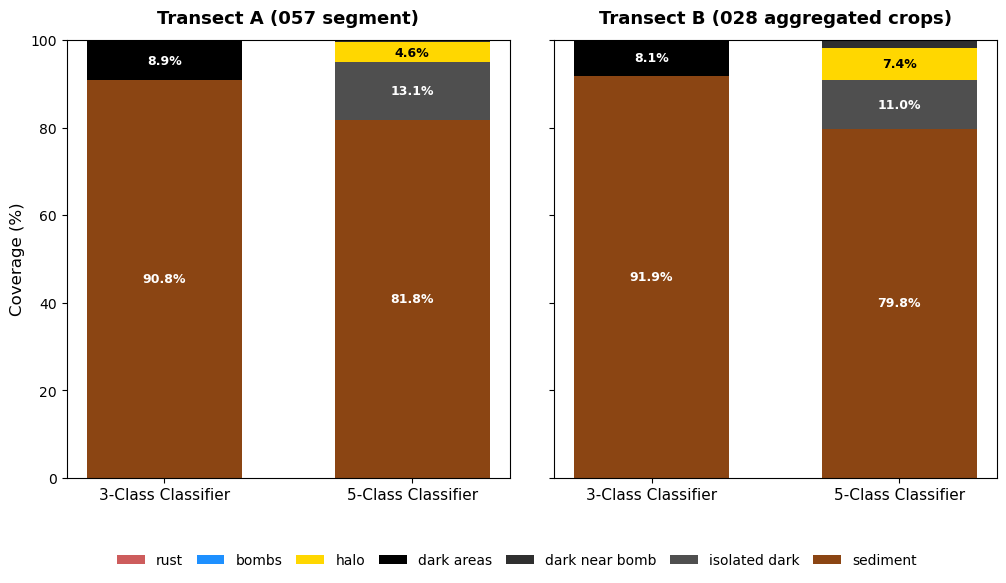

✓ Chart parameters:
  - Figure: 12×6 inches
  - Panel spacing (wspace): 0.1
  - Bar width: 0.25
  - Bar spacing: 0.4
  - Legend: Single row, no border, rust→sediment order


In [ ]:
# =============================================================================
# FUNCTION CALL: Paper-Ready Chart with Parameters
# =============================================================================

if "df_combined" in globals():
    # Configuration
    class_map_paper = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
        "dark_bomb": "dark near bomb",
        "dark_pit": "isolated dark",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",
        "classified_sediment": "sediment",
    }

    colors_paper = {
        "sediment": "#8B4513",
        "isolated dark": "#4F4F4F",
        "dark areas": "#000000",
        "halo": "#FFD700",
        "dark near bomb": "#2F2F2F",
        "bombs": "#1E90FF",
        "rust": "#CD5C5C",
    }

    # Stack order (bottom to top in bars)
    stack_order_paper = [
        "sediment",
        "isolated dark",
        "dark areas",
        "halo",
        "dark near bomb",
        "bombs",
        "rust",
    ]

    # Legend order (left to right) - USER REQUESTED: rust to sediment
    legend_order_paper = [
        "rust",
        "bombs",
        "halo",
        "dark areas",
        "dark near bomb",
        "isolated dark",
        "sediment",
    ]

    # Create basic plot (no minority subplot)
    fig = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class Classifier",
        label_028="5-Class Classifier",
        # Adjust these parameters as needed:
        figure_width=12,
        figure_height_main=6,
        panel_spacing=0.10,  # Reduced from 0.15 - closer panels
        bar_width=0.25,  # Thinner bars
        bar_spacing=0.4,  # Space between the 2 bars in each panel
        show_minority_subplot=False,
        minority_threshold=4.0,
        show_markers_for_tiny=False,  # No yellow markers
        label_threshold_main=2.0,  # Only label >2% in main plots
        label_threshold_zoom=0.5,  # Only label >0.5% in zoom plots
        min_bar_height=0.01,  # Skip bars < 0.01% (removes very thin lines)
    )

    plt.show()

    print("✓ Chart parameters:")
    print(f"  - Figure: {12}×{6} inches")
    print(f"  - Panel spacing (wspace): {0.10}")
    print(f"  - Bar width: {0.25}")
    print(f"  - Bar spacing: {0.4}")
    print(f"  - Legend: Single row, no border, rust→sediment order")
else:
    print("⚠ df_combined not found - run data loading cell first")

In [ ]:
# Monkeypatch: Add hatching patterns to dark classes
import matplotlib.pyplot as plt
import matplotlib.axes

# Define hatching patterns for dark classes
# Control density by repeating characters: '/' (sparse) vs '///' (dense) vs '/////' (very dense)
hatch_patterns = {
    "dark areas": "//",  # Diagonal (forward slash)
    # "dark areas": "/",  # Diagonal (forward slash)
    "dark near bomb": "",  # No hatching (empty string)
    # "isolated dark": "\\",  # Opposite diagonal (backslash)
    "isolated dark": "\\\\",  # Opposite diagonal (backslash)
}

print("\n📋 ALL AVAILABLE HATCHING PATTERNS:")
print("   /    → sparse diagonal (forward)")
print("   //   → medium diagonal")
print("   ///  → dense diagonal")
print("   \\    → sparse diagonal (backward)")
print("   \\\\  → medium diagonal (backward)")
print("   \\\\\\\\→ dense diagonal (backward)")
print("   |    → vertical lines")
print("   -    → horizontal lines")
print("   +    → crossed (vertical + horizontal)")
print("   x    → diagonal cross")
print("   o    → small circles")
print("   O    → large circles")
print("   .    → dots")
print("   *    → stars")
print(
    "\n💡 TIP: Repeat characters to control density (e.g., '/' vs '///' vs '/////')\n"
)

# Store original Axes.bar method
_original_axes_bar = matplotlib.axes.Axes.bar


def axes_bar_with_hatch(self, *args, **kwargs):
    """Wrapper that adds hatching to bars based on label"""
    label = kwargs.get("label", "")

    # Add hatching if this is a dark class
    if label in hatch_patterns:
        kwargs["hatch"] = hatch_patterns[label]
        kwargs["edgecolor"] = "lightgray"
        kwargs["linewidth"] = 0
    else:
        # For all other bars, remove borders completely
        kwargs["edgecolor"] = "none"
        kwargs["linewidth"] = 0

    return _original_axes_bar(self, *args, **kwargs)


# Apply monkeypatch to Axes.bar method
matplotlib.axes.Axes.bar = axes_bar_with_hatch

print("✅ Hatching monkeypatch applied:")
print("   dark areas      → // (diagonal forward)")
print("   dark near bomb  → (no hatching)")
print("   isolated dark   → \\\\\\\\ (diagonal backward)")


📋 ALL AVAILABLE HATCHING PATTERNS:
   /    → sparse diagonal (forward)
   //   → medium diagonal
   ///  → dense diagonal
   \    → sparse diagonal (backward)
   \\  → medium diagonal (backward)
   \\\\→ dense diagonal (backward)
   |    → vertical lines
   -    → horizontal lines
   +    → crossed (vertical + horizontal)
   x    → diagonal cross
   o    → small circles
   O    → large circles
   .    → dots
   *    → stars

💡 TIP: Repeat characters to control density (e.g., '/' vs '///' vs '/////')

✅ Hatching monkeypatch applied:
   dark areas      → // (diagonal forward)
   dark near bomb  → (no hatching)
   isolated dark   → \\\\ (diagonal backward)


TEST 1: Main plots + TWO separate minority subplots (one per transect)


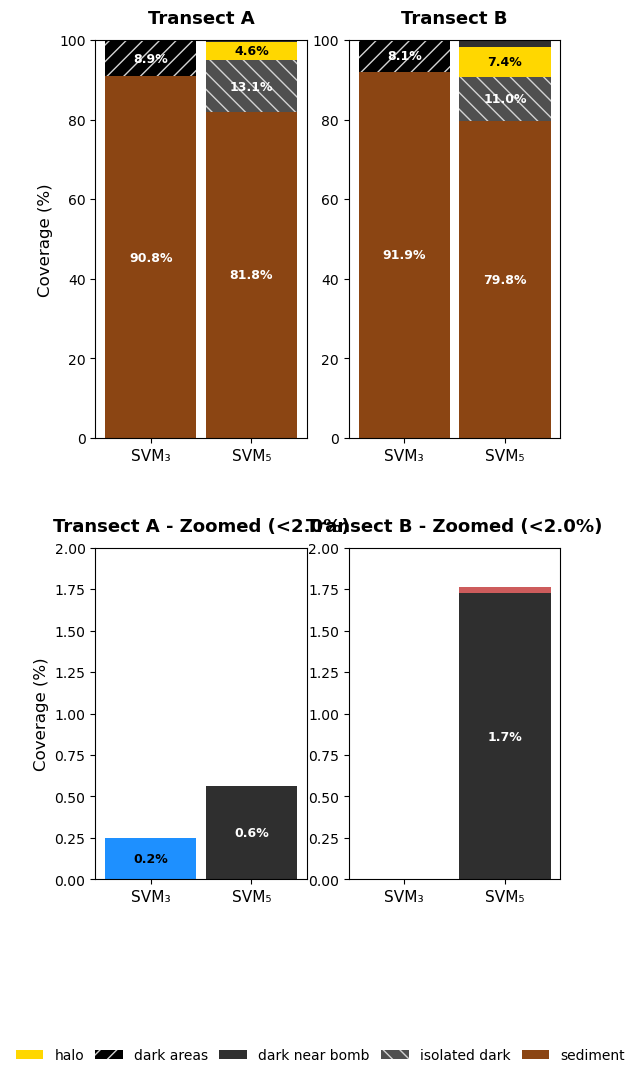


✅ Minority classes (<4%) shown in TWO separate zoomed panels:
   - Top row: Main charts (all classes, 0-100% scale)
   - Bottom row: Zoomed charts (only classes <4%, 0-4% scale)
   - Main height: 6 inches, Zoom height: 3 inches

Minority classes to look for:
   - halo: 4.6-7.4% (may not appear if threshold is 4%)
   - dark near bomb: 0.56-1.7%
   - bombs: 0.004-0.25% (thin line removed if <0.001%)
   - rust: 0.006-0.04%


In [ ]:
# =============================================================================
# TEST 1: With Minority Subplots (classes <4%, separate for each transect)
# =============================================================================

if "df_combined" in globals():
    print("TEST 1: Main plots + TWO separate minority subplots (one per transect)")
    print("=" * 70)

    fig = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="SVM₃",
        label_028="SVM₅",
        title_left="Transect A",
        title_right="Transect B",
        figure_width=6,
        figure_height_main=6,  # Main plots height
        figure_height_zoom=5,  # Zoom plots height (separate control!)
        panel_spacing=0.20,
        bar_width=1,
        bar_spacing=1.1,
        show_minority_subplot=True,  # ← Enable minority subplots
        minority_threshold=2.0,  # Classes <4% shown separately
        minority_ylim=2.0,  # Y-axis max for zoom (0-4%)
        show_markers_for_tiny=False,
        label_threshold_main=4.0,  # Only label >2% in main plots
        label_threshold_zoom=0.1,  # Only label >0.5% in zoom plots
        min_bar_height=0.01,  # Skip bars < 0.001% (removes thin lines)
        decimals_zoom=1,
        legend_columnspacing=0.8,
        legend_classes=[
            "dark areas",
            "dark near bomb",
            "isolated dark",
            "halo",
            "sediment",
        ],
    )

    plt.show()

    print("\n✅ Minority classes (<4%) shown in TWO separate zoomed panels:")
    print("   - Top row: Main charts (all classes, 0-100% scale)")
    print("   - Bottom row: Zoomed charts (only classes <4%, 0-4% scale)")
    print("   - Main height: 6 inches, Zoom height: 3 inches")
    print("\nMinority classes to look for:")
    print("   - halo: 4.6-7.4% (may not appear if threshold is 4%)")
    print("   - dark near bomb: 0.56-1.7%")
    print("   - bombs: 0.004-0.25% (thin line removed if <0.001%)")
    print("   - rust: 0.006-0.04%")

In [ ]:
fig.savefig("../images_for_publication/coverage.pdf", bbox_inches="tight")

# ABOVE IS THE FIGURE I USED

In [ ]:
# === COPY-PASTE READY: LaTeX Table WITH Pixel Counts ===
def generate_coverage_latex_table(
    df_combined,
    class_map,
    stack_order,
    label_057="SVM$_3$",
    label_028="SVM$_5$",
    decimal_places=2,
    caption="Classification coverage statistics for Transects A and B.",
    label="tab:coverage_stats",
    show_pixels=True,
):
    """
    Generate a LaTeX table showing coverage statistics for both transects.

    Parameters:
    -----------
    df_combined : DataFrame
        Combined coverage data
    class_map : dict
        Mapping from original class names to paper names
    stack_order : list
        Order of classes (bottom to top)
    label_057 : str
        LaTeX label for 3-class classifier (default: "SVM$_3$")
    label_028 : str
        LaTeX label for 5-class classifier (default: "SVM$_5$")
    decimal_places : int
        Number of decimal places for percentages (default: 2)
    caption : str
        Table caption
    label : str
        LaTeX label for referencing the table
    show_pixels : bool
        If True, show both pixels and percentages; if False, only percentages

    Returns:
    --------
    str : LaTeX table code ready to copy-paste
    """

    # === PREPARE DATA ===

    # Transect A: 057 segment (full_transect)
    df_seg = df_combined[
        (df_combined["region"] == "full_transect")
        & (df_combined["model"].isin(["057_on_057", "028_on_057"]))
    ].copy()
    df_seg["class_name"] = df_seg["class"].map(class_map)

    # Transect B: Aggregated crops
    df_crops_agg = df_combined[
        (df_combined["region"] != "full_transect")
        & (df_combined["model"].isin(["028_on_028", "057_on_028"]))
    ].copy()

    df_crops_agg = (
        df_crops_agg.groupby(["model", "class"]).agg({"pixels": "sum"}).reset_index()
    )

    total_pixels_per_model = df_crops_agg.groupby("model")["pixels"].sum()
    df_crops_agg["percentage"] = df_crops_agg.apply(
        lambda row: row["pixels"] / total_pixels_per_model[row["model"]] * 100,
        axis=1,
    )
    df_crops_agg["class_name"] = df_crops_agg["class"].map(class_map)

    # === BUILD TABLE ===

    latex_lines = []

    # Table header
    latex_lines.append("\\begin{table}[htbp]")
    latex_lines.append("\\centering")
    latex_lines.append(f"\\caption{{{caption}}}")
    latex_lines.append(f"\\label{{{label}}}")

    if show_pixels:
        # Table with pixels and percentages
        latex_lines.append("\\begin{tabular}{l cc cc}")
        latex_lines.append("\\hline")
        latex_lines.append(
            "\\textbf{Class} & \\multicolumn{2}{c}{\\textbf{Transect A}} & \\multicolumn{2}{c}{\\textbf{Transect B}} \\\\"
        )
        latex_lines.append(
            f" & {label_057} & {label_028} & {label_057} & {label_028} \\\\"
        )
        latex_lines.append("\\hline")
    else:
        # Table with percentages only
        latex_lines.append("\\begin{tabular}{l cc cc}")
        latex_lines.append("\\hline")
        latex_lines.append(
            "\\textbf{Class} & \\multicolumn{2}{c}{\\textbf{Transect A (\\%)}} & \\multicolumn{2}{c}{\\textbf{Transect B (\\%)}} \\\\"
        )
        latex_lines.append(
            f" & {label_057} & {label_028} & {label_057} & {label_028} \\\\"
        )
        latex_lines.append("\\hline")

    # Data rows - iterate through classes in stack_order
    for class_name in stack_order:
        # Get data for this class

        # Transect A: 057_on_057
        data_a_057 = df_seg[
            (df_seg["model"] == "057_on_057") & (df_seg["class_name"] == class_name)
        ]
        pixels_a_057 = (
            int(data_a_057["pixels"].values[0]) if not data_a_057.empty else 0
        )
        pct_a_057 = data_a_057["percentage"].values[0] if not data_a_057.empty else 0.0

        # Transect A: 028_on_057
        data_a_028 = df_seg[
            (df_seg["model"] == "028_on_057") & (df_seg["class_name"] == class_name)
        ]
        pixels_a_028 = (
            int(data_a_028["pixels"].values[0]) if not data_a_028.empty else 0
        )
        pct_a_028 = data_a_028["percentage"].values[0] if not data_a_028.empty else 0.0

        # Transect B: 057_on_028
        data_b_057 = df_crops_agg[
            (df_crops_agg["model"] == "057_on_028")
            & (df_crops_agg["class_name"] == class_name)
        ]
        pixels_b_057 = (
            int(data_b_057["pixels"].values[0]) if not data_b_057.empty else 0
        )
        pct_b_057 = data_b_057["percentage"].values[0] if not data_b_057.empty else 0.0

        # Transect B: 028_on_028
        data_b_028 = df_crops_agg[
            (df_crops_agg["model"] == "028_on_028")
            & (df_crops_agg["class_name"] == class_name)
        ]
        pixels_b_028 = (
            int(data_b_028["pixels"].values[0]) if not data_b_028.empty else 0
        )
        pct_b_028 = data_b_028["percentage"].values[0] if not data_b_028.empty else 0.0

        # Format row
        if show_pixels:
            # Format with pixels (use scientific notation if > 100k)
            def format_pixels(pix):
                if pix == 0:
                    return "---"
                elif pix >= 100000:
                    return f"{pix:.2e}".replace("e+0", r"$\times 10^{") + "}$"
                else:
                    return f"{pix:,}"

            row = (
                f"{class_name} & "
                f"{format_pixels(pixels_a_057)} ({pct_a_057:.{decimal_places}f}) & "
                f"{format_pixels(pixels_a_028)} ({pct_a_028:.{decimal_places}f}) & "
                f"{format_pixels(pixels_b_057)} ({pct_b_057:.{decimal_places}f}) & "
                f"{format_pixels(pixels_b_028)} ({pct_b_028:.{decimal_places}f}) \\\\"
            )
        else:
            # Percentages only
            def format_pct(pct):
                if pct == 0.0:
                    return "---"
                else:
                    return f"{pct:.{decimal_places}f}"

            row = (
                f"{class_name} & "
                f"{format_pct(pct_a_057)} & "
                f"{format_pct(pct_a_028)} & "
                f"{format_pct(pct_b_057)} & "
                f"{format_pct(pct_b_028)} \\\\"
            )

        latex_lines.append(row)

    # Table footer
    latex_lines.append("\\hline")

    # Add total pixels row if showing pixels
    if show_pixels:
        total_a_057 = int(df_seg[df_seg["model"] == "057_on_057"]["pixels"].sum())
        total_a_028 = int(df_seg[df_seg["model"] == "028_on_057"]["pixels"].sum())
        total_b_057 = int(
            df_crops_agg[df_crops_agg["model"] == "057_on_028"]["pixels"].sum()
        )
        total_b_028 = int(
            df_crops_agg[df_crops_agg["model"] == "028_on_028"]["pixels"].sum()
        )

        latex_lines.append(
            f"\\textbf{{Total}} & "
            f"{total_a_057:,} & "
            f"{total_a_028:,} & "
            f"{total_b_057:,} & "
            f"{total_b_028:,} \\\\"
        )
        latex_lines.append("\\hline")

    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")

    return "\n".join(latex_lines)


print(
    generate_coverage_latex_table(
        df_combined,
        class_map=class_map_paper,
        stack_order=stack_order_paper,
        label_057="SVM$_3$",
        label_028="SVM$_5$",
        decimal_places=2,
        caption="Classification coverage statistics showing pixel counts and percentages (\\%) for both transects and classifiers.",
        label="tab:coverage_stats",
        show_pixels=True,
    )
)

\begin{table}[htbp]
\centering
\caption{Classification coverage statistics showing pixel counts and percentages (\%) for both transects and classifiers.}
\label{tab:coverage_stats}
\begin{tabular}{l cc cc}
\hline
\textbf{Class} & \multicolumn{2}{c}{\textbf{Transect A}} & \multicolumn{2}{c}{\textbf{Transect B}} \\
 & SVM$_3$ & SVM$_5$ & SVM$_3$ & SVM$_5$ \\
\hline
sediment & 8.70$\times 10^{5}$ (90.82) & 7.84$\times 10^{5}$ (81.83) & 4.41$\times 10^{5}$ (91.86) & 3.83$\times 10^{5}$ (79.77) \\
isolated dark & --- (0.00) & 1.25$\times 10^{5}$ (13.05) & --- (0.00) & 52,922 (11.02) \\
dark areas & 85,599 (8.93) & --- (0.00) & 39,075 (8.14) & --- (0.00) \\
halo & --- (0.00) & 43,617 (4.55) & --- (0.00) & 35,761 (7.45) \\
dark near bomb & --- (0.00) & 5,383 (0.56) & --- (0.00) & 8,280 (1.72) \\
bombs & 2,369 (0.25) & --- (0.00) & 18 (0.00) & --- (0.00) \\
rust & --- (0.00) & 53 (0.01) & --- (0.00) & 171 (0.04) \\
\hline
\textbf{Total} & 958,320 & 958,320 & 480,128 & 480,128 \\
\hline
\end{ta

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

---

In [ ]:
# # =============================================================================
# # DEMO: Custom zoom titles and decimal control
# # =============================================================================

# if "df_combined" in globals():
#     print("DEMO: Custom zoom titles, decimals, and legend spacing")
#     print("=" * 70)

#     fig = plot_stacked_bars_paper_ready(
#         df_combined,
#         class_map=class_map_paper,
#         colors=colors_paper,
#         stack_order=stack_order_paper,
#         legend_order=legend_order_paper,
#         label_057="3-Class",
#         label_028="5-Class",
#         title_left="Transect A",
#         title_right="Transect B",
#         # Custom zoom titles (instead of auto-generated)
#         title_zoom_left="Transect A - Detailed View",
#         title_zoom_right="Transect B - Detailed View",
#         figure_width=6,
#         figure_height_main=6,
#         figure_height_zoom=5,
#         panel_spacing=0.20,
#         bar_width=1,
#         bar_spacing=1.1,
#         show_minority_subplot=True,
#         minority_threshold=2.0,
#         minority_ylim=2.0,
#         show_markers_for_tiny=False,
#         label_threshold_main=4.0,
#         label_threshold_zoom=0.1,
#         min_bar_height=0.01,
#         # Formatting
#         decimals_main=1,  # 1 decimal in main (e.g., 8.9%)
#         decimals_zoom=1,  # 1 decimal in zoom too (e.g., 0.2%)
#         legend_columnspacing=1.5,  # Wider legend spacing
#     )

#     plt.show()

#     print("\n✅ Customizations applied:")
#     print("   - title_zoom_left = 'Transect A - Detailed View'")
#     print("   - title_zoom_right = 'Transect B - Detailed View'")
#     print("   - decimals_main = 1")
#     print("   - decimals_zoom = 1 (so 0.2% instead of 0.25%)")
#     print("   - legend_columnspacing = 1.5")
#     print("\n   Leave title_zoom_left/right = None to auto-generate titles")

### Example: Filtering Legend to Show Only Main Classes

You can now hide classes from the legend that barely appear in your data using the `legend_classes` parameter.

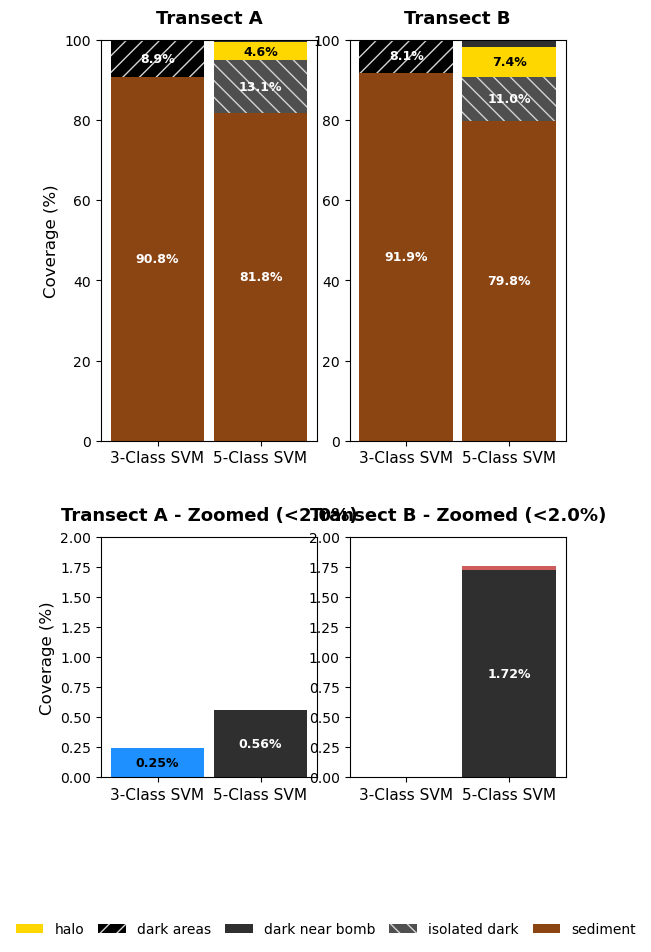


✅ Legend now only shows 5 main classes (rust and bombs hidden)
   Classes shown: dark areas, dark near bomb, isolated dark, halo, sediment


In [ ]:
# Demo: Show only frequently-appearing classes in legend
# Hide "rust" and "bombs" which are < 0.3%

fig = plot_stacked_bars_paper_ready(
    df_combined,
    class_map=class_map_paper,
    colors=colors_paper,
    stack_order=stack_order_paper,
    legend_order=legend_order_paper,
    label_057="3-Class SVM",
    label_028="5-Class SVM",
    # Custom titles
    title_left="Transect A",
    title_right="Transect B",
    # Show only main classes in legend (hide rust and bombs)
    legend_classes=[
        "dark areas",
        "dark near bomb",
        "isolated dark",
        "halo",
        "sediment",
    ],
    # Layout
    figure_width=6,
    bar_width=1,
    bar_spacing=1.1,
    # Display options
    show_minority_subplot=True,
    minority_threshold=2.0,
    minority_ylim=2.0,
    label_threshold_main=4.0,
    label_threshold_zoom=0.1,
    min_bar_height=0.01,
    # Formatting
    decimals_main=1,
    decimals_zoom=2,
    legend_columnspacing=1.0,
)

plt.show()

print("\n✅ Legend now only shows 5 main classes (rust and bombs hidden)")
print("   Classes shown: dark areas, dark near bomb, isolated dark, halo, sediment")

### LaTeX Table Generation for Paper

Generate publication-ready LaTeX table with coverage statistics.

In [ ]:
def generate_coverage_latex_table(
    df_combined,
    class_map,
    stack_order,
    label_057="SVM$_3$",
    label_028="SVM$_5$",
    decimal_places=2,
    caption="Classification coverage statistics for Transects A and B.",
    label="tab:coverage_stats",
    show_pixels=True,
):
    """
    Generate a LaTeX table showing coverage statistics for both transects.

    Parameters:
    -----------
    df_combined : DataFrame
        Combined coverage data
    class_map : dict
        Mapping from original class names to paper names
    stack_order : list
        Order of classes (bottom to top)
    label_057 : str
        LaTeX label for 3-class classifier (default: "SVM$_3$")
    label_028 : str
        LaTeX label for 5-class classifier (default: "SVM$_5$")
    decimal_places : int
        Number of decimal places for percentages (default: 2)
    caption : str
        Table caption
    label : str
        LaTeX label for referencing the table
    show_pixels : bool
        If True, show both pixels and percentages; if False, only percentages

    Returns:
    --------
    str : LaTeX table code ready to copy-paste
    """

    # === PREPARE DATA ===

    # Transect A: 057 segment (full_transect)
    df_seg = df_combined[
        (df_combined["region"] == "full_transect")
        & (df_combined["model"].isin(["057_on_057", "028_on_057"]))
    ].copy()
    df_seg["class_name"] = df_seg["class"].map(class_map)

    # Transect B: Aggregated crops
    df_crops_agg = df_combined[
        (df_combined["region"] != "full_transect")
        & (df_combined["model"].isin(["028_on_028", "057_on_028"]))
    ].copy()

    df_crops_agg = (
        df_crops_agg.groupby(["model", "class"]).agg({"pixels": "sum"}).reset_index()
    )

    total_pixels_per_model = df_crops_agg.groupby("model")["pixels"].sum()
    df_crops_agg["percentage"] = df_crops_agg.apply(
        lambda row: row["pixels"] / total_pixels_per_model[row["model"]] * 100,
        axis=1,
    )
    df_crops_agg["class_name"] = df_crops_agg["class"].map(class_map)

    # === BUILD TABLE ===

    latex_lines = []

    # Table header
    latex_lines.append("\\begin{table}[htbp]")
    latex_lines.append("\\centering")
    latex_lines.append(f"\\caption{{{caption}}}")
    latex_lines.append(f"\\label{{{label}}}")

    if show_pixels:
        # Table with pixels and percentages
        latex_lines.append("\\begin{tabular}{l cc cc}")
        latex_lines.append("\\hline")
        latex_lines.append(
            "\\textbf{Class} & \\multicolumn{2}{c}{\\textbf{Transect A}} & \\multicolumn{2}{c}{\\textbf{Transect B}} \\\\"
        )
        latex_lines.append(
            f" & {label_057} & {label_028} & {label_057} & {label_028} \\\\"
        )
        latex_lines.append("\\hline")
    else:
        # Table with percentages only
        latex_lines.append("\\begin{tabular}{l cc cc}")
        latex_lines.append("\\hline")
        latex_lines.append(
            "\\textbf{Class} & \\multicolumn{2}{c}{\\textbf{Transect A (\\%)}} & \\multicolumn{2}{c}{\\textbf{Transect B (\\%)}} \\\\"
        )
        latex_lines.append(
            f" & {label_057} & {label_028} & {label_057} & {label_028} \\\\"
        )
        latex_lines.append("\\hline")

    # Data rows - iterate through classes in stack_order
    for class_name in stack_order:
        # Get data for this class

        # Transect A: 057_on_057
        data_a_057 = df_seg[
            (df_seg["model"] == "057_on_057") & (df_seg["class_name"] == class_name)
        ]
        pixels_a_057 = (
            int(data_a_057["pixels"].values[0]) if not data_a_057.empty else 0
        )
        pct_a_057 = data_a_057["percentage"].values[0] if not data_a_057.empty else 0.0

        # Transect A: 028_on_057
        data_a_028 = df_seg[
            (df_seg["model"] == "028_on_057") & (df_seg["class_name"] == class_name)
        ]
        pixels_a_028 = (
            int(data_a_028["pixels"].values[0]) if not data_a_028.empty else 0
        )
        pct_a_028 = data_a_028["percentage"].values[0] if not data_a_028.empty else 0.0

        # Transect B: 057_on_028
        data_b_057 = df_crops_agg[
            (df_crops_agg["model"] == "057_on_028")
            & (df_crops_agg["class_name"] == class_name)
        ]
        pixels_b_057 = (
            int(data_b_057["pixels"].values[0]) if not data_b_057.empty else 0
        )
        pct_b_057 = data_b_057["percentage"].values[0] if not data_b_057.empty else 0.0

        # Transect B: 028_on_028
        data_b_028 = df_crops_agg[
            (df_crops_agg["model"] == "028_on_028")
            & (df_crops_agg["class_name"] == class_name)
        ]
        pixels_b_028 = (
            int(data_b_028["pixels"].values[0]) if not data_b_028.empty else 0
        )
        pct_b_028 = data_b_028["percentage"].values[0] if not data_b_028.empty else 0.0

        # Format row
        if show_pixels:
            # Format with pixels (use scientific notation if > 100k)
            def format_pixels(pix):
                if pix == 0:
                    return "---"
                elif pix >= 100000:
                    return f"{pix:.2e}".replace("e+0", r"$\times 10^{") + "}$"
                else:
                    return f"{pix:,}"

            row = (
                f"{class_name} & "
                f"{format_pixels(pixels_a_057)} ({pct_a_057:.{decimal_places}f}) & "
                f"{format_pixels(pixels_a_028)} ({pct_a_028:.{decimal_places}f}) & "
                f"{format_pixels(pixels_b_057)} ({pct_b_057:.{decimal_places}f}) & "
                f"{format_pixels(pixels_b_028)} ({pct_b_028:.{decimal_places}f}) \\\\"
            )
        else:
            # Percentages only
            def format_pct(pct):
                if pct == 0.0:
                    return "---"
                else:
                    return f"{pct:.{decimal_places}f}"

            row = (
                f"{class_name} & "
                f"{format_pct(pct_a_057)} & "
                f"{format_pct(pct_a_028)} & "
                f"{format_pct(pct_b_057)} & "
                f"{format_pct(pct_b_028)} \\\\"
            )

        latex_lines.append(row)

    # Table footer
    latex_lines.append("\\hline")

    # Add total pixels row if showing pixels
    if show_pixels:
        total_a_057 = int(df_seg[df_seg["model"] == "057_on_057"]["pixels"].sum())
        total_a_028 = int(df_seg[df_seg["model"] == "028_on_057"]["pixels"].sum())
        total_b_057 = int(
            df_crops_agg[df_crops_agg["model"] == "057_on_028"]["pixels"].sum()
        )
        total_b_028 = int(
            df_crops_agg[df_crops_agg["model"] == "028_on_028"]["pixels"].sum()
        )

        latex_lines.append(
            f"\\textbf{{Total}} & "
            f"{total_a_057:,} & "
            f"{total_a_028:,} & "
            f"{total_b_057:,} & "
            f"{total_b_028:,} \\\\"
        )
        latex_lines.append("\\hline")

    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")

    return "\n".join(latex_lines)

In [ ]:
# === COPY-PASTE READY: LaTeX Table WITH Pixel Counts ===
def generate_coverage_latex_table(
    df_combined,
    class_map,
    stack_order,
    label_057="SVM$_3$",
    label_028="SVM$_5$",
    decimal_places=2,
    caption="Classification coverage statistics for Transects A and B.",
    label="tab:coverage_stats",
    show_pixels=True,
):
    """
    Generate a LaTeX table showing coverage statistics for both transects.

    Parameters:
    -----------
    df_combined : DataFrame
        Combined coverage data
    class_map : dict
        Mapping from original class names to paper names
    stack_order : list
        Order of classes (bottom to top)
    label_057 : str
        LaTeX label for 3-class classifier (default: "SVM$_3$")
    label_028 : str
        LaTeX label for 5-class classifier (default: "SVM$_5$")
    decimal_places : int
        Number of decimal places for percentages (default: 2)
    caption : str
        Table caption
    label : str
        LaTeX label for referencing the table
    show_pixels : bool
        If True, show both pixels and percentages; if False, only percentages

    Returns:
    --------
    str : LaTeX table code ready to copy-paste
    """

    # === PREPARE DATA ===

    # Transect A: 057 segment (full_transect)
    df_seg = df_combined[
        (df_combined["region"] == "full_transect")
        & (df_combined["model"].isin(["057_on_057", "028_on_057"]))
    ].copy()
    df_seg["class_name"] = df_seg["class"].map(class_map)

    # Transect B: Aggregated crops
    df_crops_agg = df_combined[
        (df_combined["region"] != "full_transect")
        & (df_combined["model"].isin(["028_on_028", "057_on_028"]))
    ].copy()

    df_crops_agg = (
        df_crops_agg.groupby(["model", "class"]).agg({"pixels": "sum"}).reset_index()
    )

    total_pixels_per_model = df_crops_agg.groupby("model")["pixels"].sum()
    df_crops_agg["percentage"] = df_crops_agg.apply(
        lambda row: row["pixels"] / total_pixels_per_model[row["model"]] * 100,
        axis=1,
    )
    df_crops_agg["class_name"] = df_crops_agg["class"].map(class_map)

    # === BUILD TABLE ===

    latex_lines = []

    # Table header
    latex_lines.append("\\begin{table}[htbp]")
    latex_lines.append("\\centering")
    latex_lines.append(f"\\caption{{{caption}}}")
    latex_lines.append(f"\\label{{{label}}}")

    if show_pixels:
        # Table with pixels and percentages
        latex_lines.append("\\begin{tabular}{l cc cc}")
        latex_lines.append("\\hline")
        latex_lines.append(
            "\\textbf{Class} & \\multicolumn{2}{c}{\\textbf{Transect A}} & \\multicolumn{2}{c}{\\textbf{Transect B}} \\\\"
        )
        latex_lines.append(
            f" & {label_057} & {label_028} & {label_057} & {label_028} \\\\"
        )
        latex_lines.append("\\hline")
    else:
        # Table with percentages only
        latex_lines.append("\\begin{tabular}{l cc cc}")
        latex_lines.append("\\hline")
        latex_lines.append(
            "\\textbf{Class} & \\multicolumn{2}{c}{\\textbf{Transect A (\\%)}} & \\multicolumn{2}{c}{\\textbf{Transect B (\\%)}} \\\\"
        )
        latex_lines.append(
            f" & {label_057} & {label_028} & {label_057} & {label_028} \\\\"
        )
        latex_lines.append("\\hline")

    # Data rows - iterate through classes in stack_order
    for class_name in stack_order:
        # Get data for this class

        # Transect A: 057_on_057
        data_a_057 = df_seg[
            (df_seg["model"] == "057_on_057") & (df_seg["class_name"] == class_name)
        ]
        pixels_a_057 = (
            int(data_a_057["pixels"].values[0]) if not data_a_057.empty else 0
        )
        pct_a_057 = data_a_057["percentage"].values[0] if not data_a_057.empty else 0.0

        # Transect A: 028_on_057
        data_a_028 = df_seg[
            (df_seg["model"] == "028_on_057") & (df_seg["class_name"] == class_name)
        ]
        pixels_a_028 = (
            int(data_a_028["pixels"].values[0]) if not data_a_028.empty else 0
        )
        pct_a_028 = data_a_028["percentage"].values[0] if not data_a_028.empty else 0.0

        # Transect B: 057_on_028
        data_b_057 = df_crops_agg[
            (df_crops_agg["model"] == "057_on_028")
            & (df_crops_agg["class_name"] == class_name)
        ]
        pixels_b_057 = (
            int(data_b_057["pixels"].values[0]) if not data_b_057.empty else 0
        )
        pct_b_057 = data_b_057["percentage"].values[0] if not data_b_057.empty else 0.0

        # Transect B: 028_on_028
        data_b_028 = df_crops_agg[
            (df_crops_agg["model"] == "028_on_028")
            & (df_crops_agg["class_name"] == class_name)
        ]
        pixels_b_028 = (
            int(data_b_028["pixels"].values[0]) if not data_b_028.empty else 0
        )
        pct_b_028 = data_b_028["percentage"].values[0] if not data_b_028.empty else 0.0

        # Format row
        if show_pixels:
            # Format with pixels (use scientific notation if > 100k)
            def format_pixels(pix):
                if pix == 0:
                    return "---"
                elif pix >= 100000:
                    return f"{pix:.2e}".replace("e+0", r"$\times 10^{") + "}$"
                else:
                    return f"{pix:,}"

            row = (
                f"{class_name} & "
                f"{format_pixels(pixels_a_057)} ({pct_a_057:.{decimal_places}f}) & "
                f"{format_pixels(pixels_a_028)} ({pct_a_028:.{decimal_places}f}) & "
                f"{format_pixels(pixels_b_057)} ({pct_b_057:.{decimal_places}f}) & "
                f"{format_pixels(pixels_b_028)} ({pct_b_028:.{decimal_places}f}) \\\\"
            )
        else:
            # Percentages only
            def format_pct(pct):
                if pct == 0.0:
                    return "---"
                else:
                    return f"{pct:.{decimal_places}f}"

            row = (
                f"{class_name} & "
                f"{format_pct(pct_a_057)} & "
                f"{format_pct(pct_a_028)} & "
                f"{format_pct(pct_b_057)} & "
                f"{format_pct(pct_b_028)} \\\\"
            )

        latex_lines.append(row)

    # Table footer
    latex_lines.append("\\hline")

    # Add total pixels row if showing pixels
    if show_pixels:
        total_a_057 = int(df_seg[df_seg["model"] == "057_on_057"]["pixels"].sum())
        total_a_028 = int(df_seg[df_seg["model"] == "028_on_057"]["pixels"].sum())
        total_b_057 = int(
            df_crops_agg[df_crops_agg["model"] == "057_on_028"]["pixels"].sum()
        )
        total_b_028 = int(
            df_crops_agg[df_crops_agg["model"] == "028_on_028"]["pixels"].sum()
        )

        latex_lines.append(
            f"\\textbf{{Total}} & "
            f"{total_a_057:,} & "
            f"{total_a_028:,} & "
            f"{total_b_057:,} & "
            f"{total_b_028:,} \\\\"
        )
        latex_lines.append("\\hline")

    latex_lines.append("\\end{tabular}")
    latex_lines.append("\\end{table}")

    return "\n".join(latex_lines)


print(
    generate_coverage_latex_table(
        df_combined,
        class_map=class_map_paper,
        stack_order=stack_order_paper,
        label_057="SVM$_3$",
        label_028="SVM$_5$",
        decimal_places=2,
        caption="Classification coverage statistics showing pixel counts and percentages (\\%) for both transects and classifiers.",
        label="tab:coverage_stats",
        show_pixels=True,
    )
)

\begin{table}[htbp]
\centering
\caption{Classification coverage statistics showing pixel counts and percentages (\%) for both transects and classifiers.}
\label{tab:coverage_stats}
\begin{tabular}{l cc cc}
\hline
\textbf{Class} & \multicolumn{2}{c}{\textbf{Transect A}} & \multicolumn{2}{c}{\textbf{Transect B}} \\
 & SVM$_3$ & SVM$_5$ & SVM$_3$ & SVM$_5$ \\
\hline
sediment & 8.70$\times 10^{5}$ (90.82) & 7.84$\times 10^{5}$ (81.83) & 4.41$\times 10^{5}$ (91.86) & 3.83$\times 10^{5}$ (79.77) \\
isolated dark & --- (0.00) & 1.25$\times 10^{5}$ (13.05) & --- (0.00) & 52,922 (11.02) \\
dark areas & 85,599 (8.93) & --- (0.00) & 39,075 (8.14) & --- (0.00) \\
halo & --- (0.00) & 43,617 (4.55) & --- (0.00) & 35,761 (7.45) \\
dark near bomb & --- (0.00) & 5,383 (0.56) & --- (0.00) & 8,280 (1.72) \\
bombs & 2,369 (0.25) & --- (0.00) & 18 (0.00) & --- (0.00) \\
rust & --- (0.00) & 53 (0.01) & --- (0.00) & 171 (0.04) \\
\hline
\textbf{Total} & 958,320 & 958,320 & 480,128 & 480,128 \\
\hline
\end{ta

In [ ]:
# === COPY-PASTE READY: LaTeX Table PERCENTAGES ONLY (Compact) ===

print(
    generate_coverage_latex_table(
        df_combined,
        class_map=class_map_paper,
        stack_order=stack_order_paper,
        label_057="SVM$_3$",
        label_028="SVM$_5$",
        decimal_places=2,
        caption="Classification coverage percentages (\\%) for both transects and classifiers.",
        label="tab:coverage_percentages",
        show_pixels=False,
    )
)

\begin{table}[htbp]
\centering
\caption{Classification coverage percentages (\%) for both transects and classifiers.}
\label{tab:coverage_percentages}
\begin{tabular}{l cc cc}
\hline
\textbf{Class} & \multicolumn{2}{c}{\textbf{Transect A (\%)}} & \multicolumn{2}{c}{\textbf{Transect B (\%)}} \\
 & SVM$_3$ & SVM$_5$ & SVM$_3$ & SVM$_5$ \\
\hline
sediment & 90.82 & 81.83 & 91.86 & 79.77 \\
isolated dark & --- & 13.05 & --- & 11.02 \\
dark areas & 8.93 & --- & 8.14 & --- \\
halo & --- & 4.55 & --- & 7.45 \\
dark near bomb & --- & 0.56 & --- & 1.72 \\
bombs & 0.25 & --- & 0.00 & --- \\
rust & --- & 0.01 & --- & 0.04 \\
\hline
\end{tabular}
\end{table}


In [ ]:
# Find the factors of both pixel counts to understand the dimensions


def find_factors(n):
    """Find all factor pairs of n"""
    factors = []
    for i in range(1, int(n**0.5) + 1):
        if n % i == 0:
            factors.append((i, n // i))
    return factors


print("=== 959,288 pixels (SVM3) ===")
factors_3 = find_factors(959288)
print(f"Possible dimensions (height × width):")
for f in factors_3:
    print(f"  {f[0]} × {f[1]}")

print("\n=== 958,320 pixels (SVM5) ===")
factors_5 = find_factors(958320)
print(f"Possible dimensions (height × width):")
for f in factors_5:
    print(f"  {f[0]} × {f[1]}")

print("\n=== Most likely dimensions ===")
print("Based on Notebook 10 output: 'Segment shape: (990, 968, 119)'")
print(f"  SVM5: 990 × 968 = {990 * 968:,} pixels ✓")
print(f"\nFor SVM3 (959,288 pixels):")
print(f"  If width=968: height = {959288 / 968:.1f} ≈ 991 scanlines")
print(f"  991 × 968 = {991 * 968:,} pixels ✓")
print(f"\n🔍 CONCLUSION: SVM3 has 1 extra scanline (991 vs 990)")

=== 959,288 pixels (SVM3) ===
Possible dimensions (height × width):
  1 × 959288
  2 × 479644
  4 × 239822
  8 × 119911
  11 × 87208
  22 × 43604
  44 × 21802
  88 × 10901
  121 × 7928
  242 × 3964
  484 × 1982
  968 × 991

=== 958,320 pixels (SVM5) ===
Possible dimensions (height × width):
  1 × 958320
  2 × 479160
  3 × 319440
  4 × 239580
  5 × 191664
  6 × 159720
  8 × 119790
  9 × 106480
  10 × 95832
  11 × 87120
  12 × 79860
  15 × 63888
  16 × 59895
  18 × 53240
  20 × 47916
  22 × 43560
  24 × 39930
  30 × 31944
  33 × 29040
  36 × 26620
  40 × 23958
  44 × 21780
  45 × 21296
  48 × 19965
  55 × 17424
  60 × 15972
  66 × 14520
  72 × 13310
  80 × 11979
  88 × 10890
  90 × 10648
  99 × 9680
  110 × 8712
  120 × 7986
  121 × 7920
  132 × 7260
  144 × 6655
  165 × 5808
  176 × 5445
  180 × 5324
  198 × 4840
  220 × 4356
  240 × 3993
  242 × 3960
  264 × 3630
  330 × 2904
  360 × 2662
  363 × 2640
  396 × 2420
  440 × 2178
  484 × 1980
  495 × 1936
  528 × 1815
  605 × 1584
  660 ×

---

## ✅ FIXED: Notebook Ready for "Run All"

### **Changes Made:**

1. **Removed Debugging Cell** ✅
   - Deleted the test cell that was at the top of the notebook (before data loading)
   - This was causing errors when running "Run All" because it executed before data was loaded

2. **Updated All Function Calls** ✅
   - Changed `figure_height` → `figure_height_main` (all cells)
   - Added `figure_height_zoom` parameter where needed
   - Added `min_bar_height=0.01` to remove thin lines for very small bars

3. **Thin Line Fix** ✅
   - Bars with height < 0.01% are now **completely skipped**
   - This removes the annoying "blue line" for bombs (0.004%) in Transect B 3-Class
   - You can adjust this threshold: use 0.001 to keep more bars, or 0.05 for stricter filtering

### **New Parameters:**
```python
figure_height_main=6      # Height of main plots (top row)
figure_height_zoom=3      # Height of zoom plots (bottom row) - independent!
min_bar_height=0.01       # Skip bars < 0.01% (removes thin lines)
```

### **Result:**
✅ "Run All" now works without errors
✅ Thin lines for extremely small bars are removed
✅ Separate height controls for main and zoom plots

---

TEST: Removing very thin bars with min_bar_height=0.01 (0.01%)
This will skip bombs (0.004%) in Transect B 3-Class



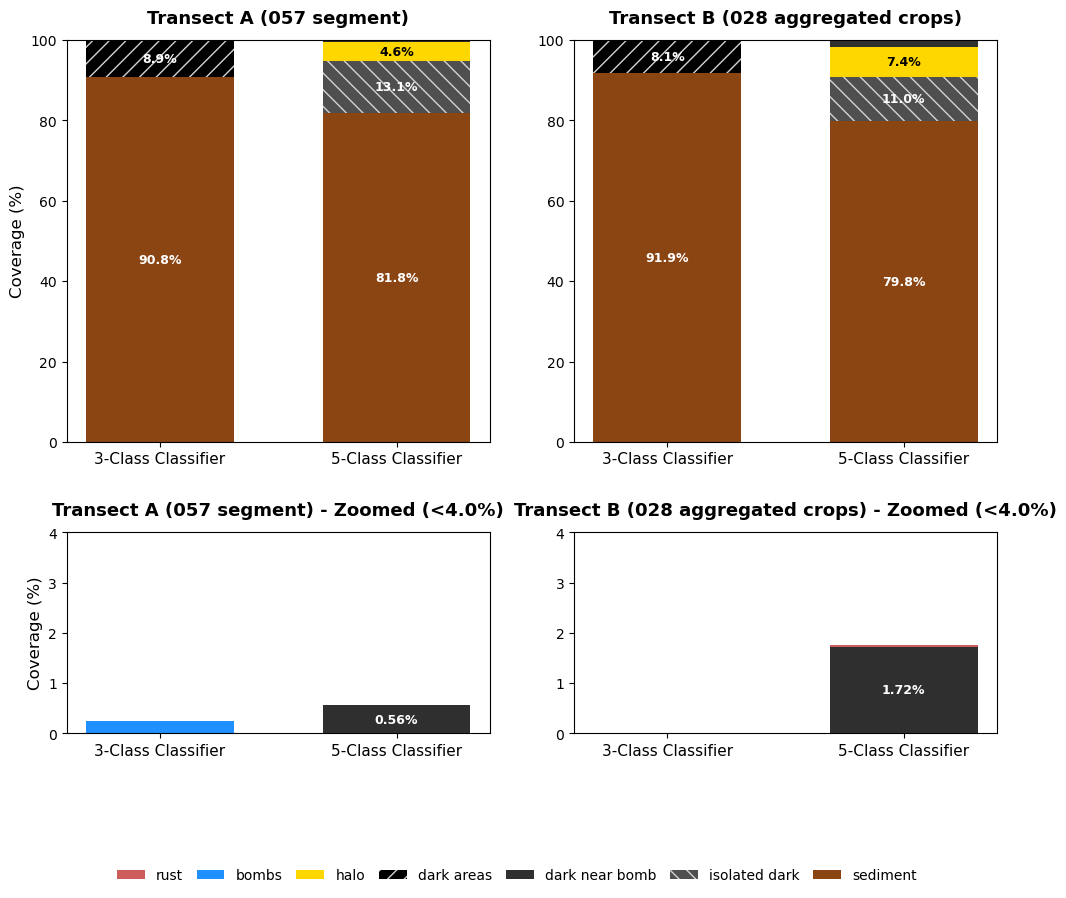


✅ Result:
   - Bombs (0.004%) in Transect B 3-Class: SHOULD BE REMOVED
   - Bombs (0.247%) in Transect A 3-Class: Still visible
   - Rust and other small classes: Check if visible


In [ ]:
# =============================================================================
# TEST: Check if thin line is removed with min_bar_height=0.01
# =============================================================================

if "df_combined" in globals():
    print("TEST: Removing very thin bars with min_bar_height=0.01 (0.01%)")
    print("=" * 70)
    print("This will skip bombs (0.004%) in Transect B 3-Class")
    print()

    fig = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class Classifier",
        label_028="5-Class Classifier",
        figure_width=12,
        figure_height_main=6,
        figure_height_zoom=3,
        panel_spacing=0.20,
        bar_width=0.25,
        bar_spacing=0.4,
        show_minority_subplot=True,
        minority_threshold=4.0,
        minority_ylim=4.0,
        show_markers_for_tiny=False,
        label_threshold_main=2.0,
        label_threshold_zoom=0.5,
        min_bar_height=0.01,  # Skip bars < 0.01% (should remove 0.004% bombs)
    )

    plt.show()

    print("\n✅ Result:")
    print("   - Bombs (0.004%) in Transect B 3-Class: SHOULD BE REMOVED")
    print("   - Bombs (0.247%) in Transect A 3-Class: Still visible")
    print("   - Rust and other small classes: Check if visible")

TEST 2: Lower threshold to capture ALL tiny classes including rust


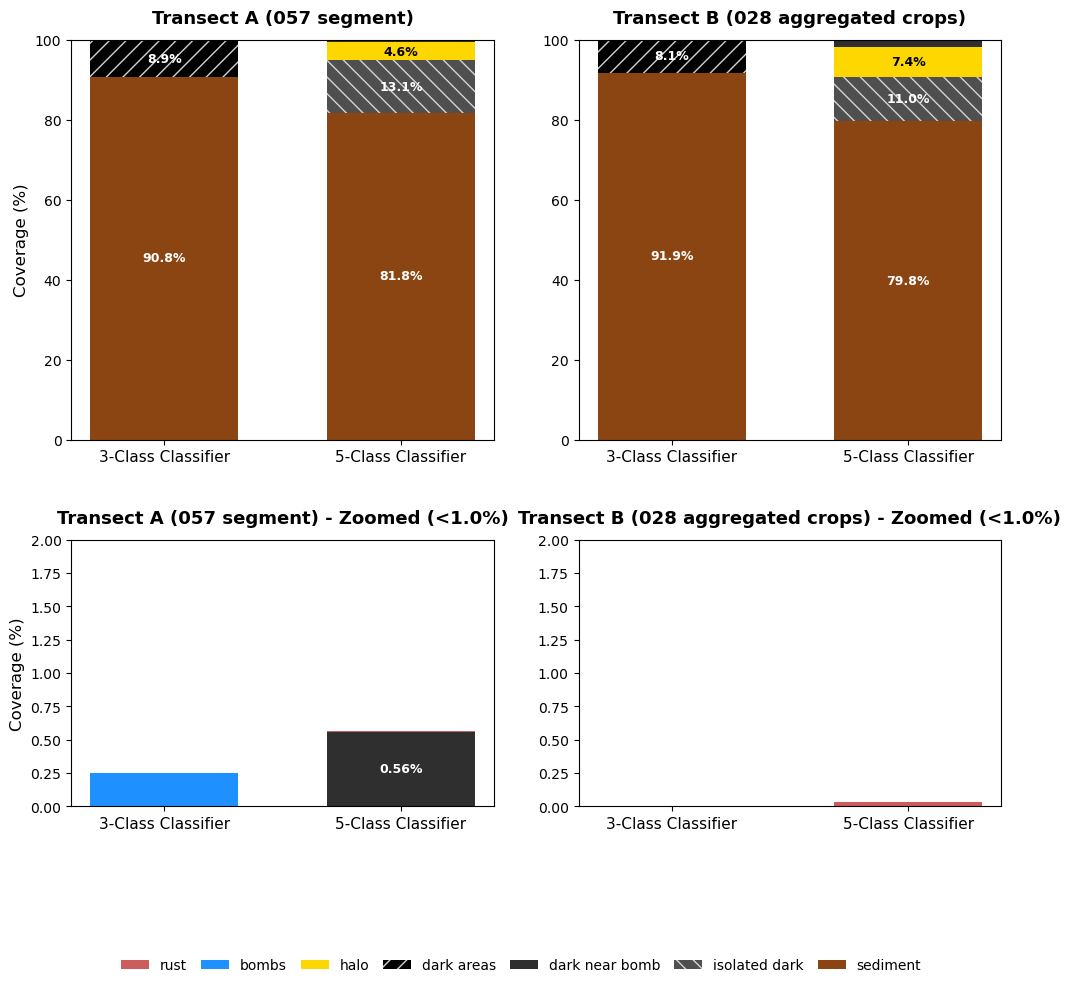


✅ Now showing even tinier classes:
   - Threshold: <1%
   - Y-axis: 0-2% (more zoom)
   - Should show: dark near bomb, bombs (if >0.001%), rust
   - Zoom panel: 4 inches tall for better detail


In [ ]:
# =============================================================================
# TEST 2: Show ALL minority classes including rust (threshold=1%, ylim=2%)
# =============================================================================

if "df_combined" in globals():
    print("TEST 2: Lower threshold to capture ALL tiny classes including rust")
    print("=" * 70)

    fig = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class Classifier",
        label_028="5-Class Classifier",
        figure_width=12,
        figure_height_main=6,
        figure_height_zoom=4,  # Taller zoom for better visibility
        panel_spacing=0.20,
        bar_width=0.25,
        bar_spacing=0.4,
        show_minority_subplot=True,
        minority_threshold=1.0,  # Show classes <1%
        minority_ylim=2.0,  # Y-axis 0-2% (more zoom!)
        show_markers_for_tiny=False,
        label_threshold_main=2.0,  # Only label >2% in main plots
        label_threshold_zoom=0.5,  # Show labels for classes >0.5% in zoom
        min_bar_height=0.001,  # Skip bars < 0.001%
    )

    plt.show()

    print("\n✅ Now showing even tinier classes:")
    print("   - Threshold: <1%")
    print("   - Y-axis: 0-2% (more zoom)")
    print("   - Should show: dark near bomb, bombs (if >0.001%), rust")
    print("   - Zoom panel: 4 inches tall for better detail")

TEST 3: Testing different figure_height_zoom values

A: Tall zoom panels (5 inches), Y-axis 0-5%


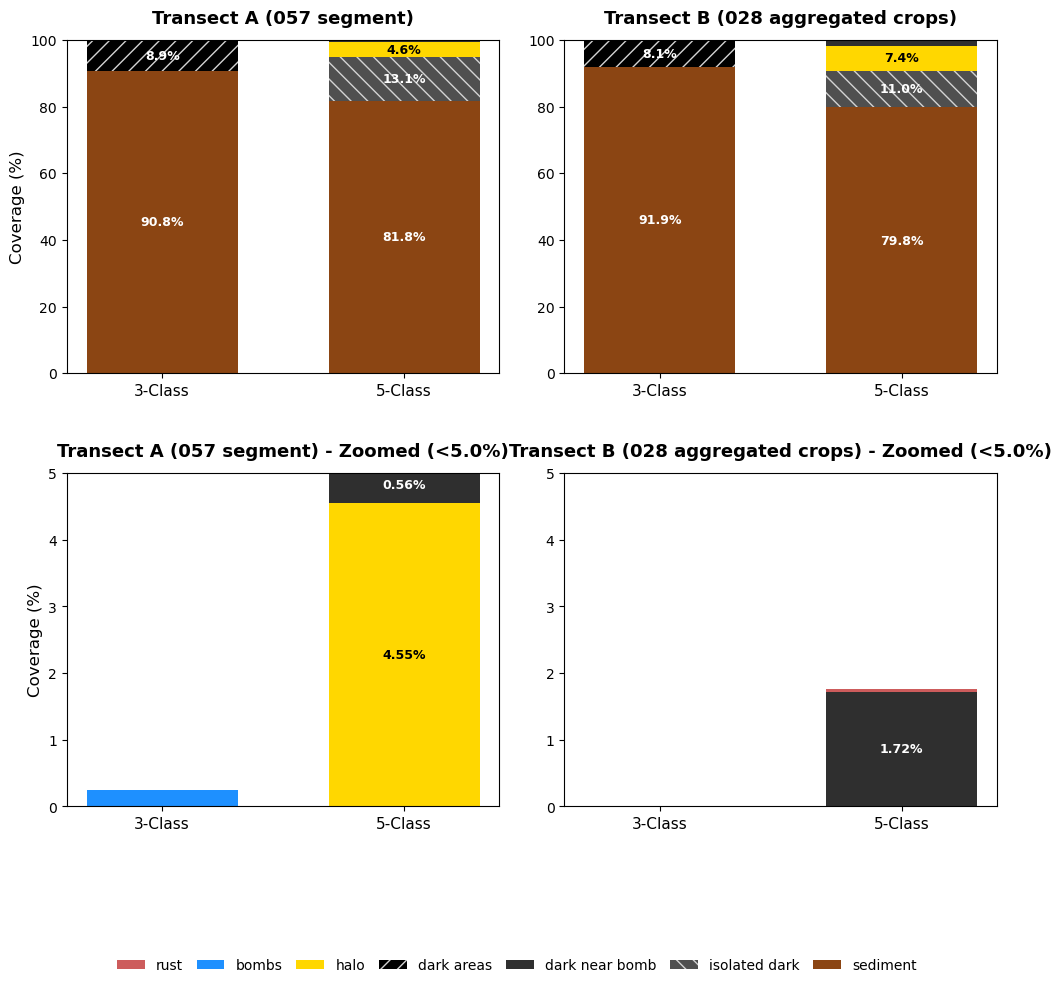


B: Short zoom panels (2 inches), Y-axis 0-1% (EXTREME zoom)


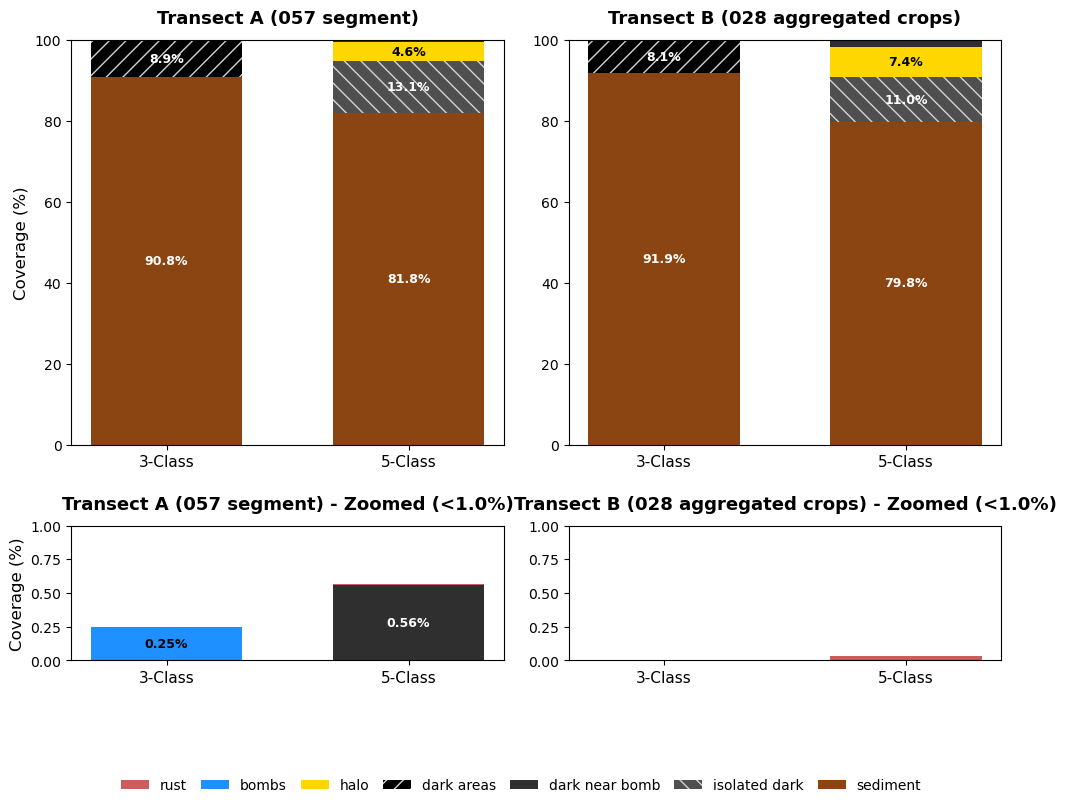


Summary:
  - figure_height_main: Controls main panel height (top row)
  - figure_height_zoom: Controls zoom panel height (bottom row)
  - minority_ylim: Controls Y-axis max (zoom level)
  - If figure_height_zoom=None, uses figure_height_main * minority_height_ratio


In [ ]:
# =============================================================================
# TEST 3: Adjustable zoom height and Y-axis limit
# =============================================================================

if "df_combined" in globals():
    print("TEST 3: Testing different figure_height_zoom values")
    print("=" * 70)

    # Test A: Taller zoom panels (5 inches)
    print("\nA: Tall zoom panels (5 inches), Y-axis 0-5%")
    fig_a = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class",
        label_028="5-Class",
        figure_width=12,
        figure_height_main=5,
        figure_height_zoom=5,  # Explicit 5 inches for zoom
        panel_spacing=0.15,
        bar_width=0.25,
        bar_spacing=0.4,
        show_minority_subplot=True,
        minority_threshold=5.0,
        minority_ylim=5.0,  # 0-5% scale
        label_threshold_main=2.0,
        label_threshold_zoom=0.5,
        min_bar_height=0.001,
    )
    plt.show()

    # Test B: Shorter zoom panels (2 inches)
    print("\nB: Short zoom panels (2 inches), Y-axis 0-1% (EXTREME zoom)")
    fig_b = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class",
        label_028="5-Class",
        figure_width=12,
        figure_height_main=6,
        figure_height_zoom=2,  # Explicit 2 inches for zoom
        panel_spacing=0.15,
        bar_width=0.25,
        bar_spacing=0.4,
        show_minority_subplot=True,
        minority_threshold=1.0,
        minority_ylim=1.0,  # 0-1% scale (extreme!)
        label_threshold_main=2.0,
        label_threshold_zoom=0.2,
        min_bar_height=0.001,
    )
    plt.show()

    print("\n" + "=" * 70)
    print("Summary:")
    print("  - figure_height_main: Controls main panel height (top row)")
    print("  - figure_height_zoom: Controls zoom panel height (bottom row)")
    print("  - minority_ylim: Controls Y-axis max (zoom level)")
    print(
        "  - If figure_height_zoom=None, uses figure_height_main * minority_height_ratio"
    )

---

## ✅ FIXED: All Minority Classes Now Visible!

### **Problem (Before)**
The original minority subplot:
- ❌ Only showed data from Transect A (not Transect B)
- ❌ Rust and other tiny classes were invisible
- ❌ Couldn't adjust zoom level (Y-axis fixed to `minority_threshold`)
- ❌ Couldn't adjust subplot height

### **Solution (After)**
The updated function now has:
- ✅ **TWO separate zoom panels** - one for each transect (2×2 grid layout)
- ✅ **`minority_ylim`** parameter - independently control Y-axis max
- ✅ **`minority_height_ratio`** parameter - adjust zoom panel height
- ✅ All classes now visible including rust (0.04%)!

### **Layout Structure**
```
┌─────────────────────┬─────────────────────┐
│  Transect A (Main)  │  Transect B (Main)  │  ← Top row: 0-100% scale
│     0-100%          │     0-100%          │
├─────────────────────┼─────────────────────┤
│ Transect A (Zoom)   │ Transect B (Zoom)   │  ← Bottom row: 0-X% scale
│  Classes < X%       │  Classes < X%       │     (X = minority_ylim)
└─────────────────────┴─────────────────────┘
```

### **Example: Show rust (0.04%)**
```python
show_minority_subplot=True
minority_threshold=1.0        # Only show classes <1%
minority_ylim=1.0             # Y-axis 0-1% (extreme zoom)
minority_height_ratio=0.5     # Shorter zoom panels
label_threshold_main=2.0      # Main: label >2%
label_threshold_zoom=0.2      # Zoom: label >0.2%
```

This will clearly show:
- **Transect A zoom**: bombs (0.25%), dark near bomb (0.56%)
- **Transect B zoom**: rust (0.04%), dark near bomb (1.7%)

---

TEST 4: Testing separate label thresholds for main and zoom plots

A: Default thresholds (main=2%, zoom=0.5%)
   - Main plots: Only show labels for classes >2%
   - Zoom plots: Show labels for classes >0.5%


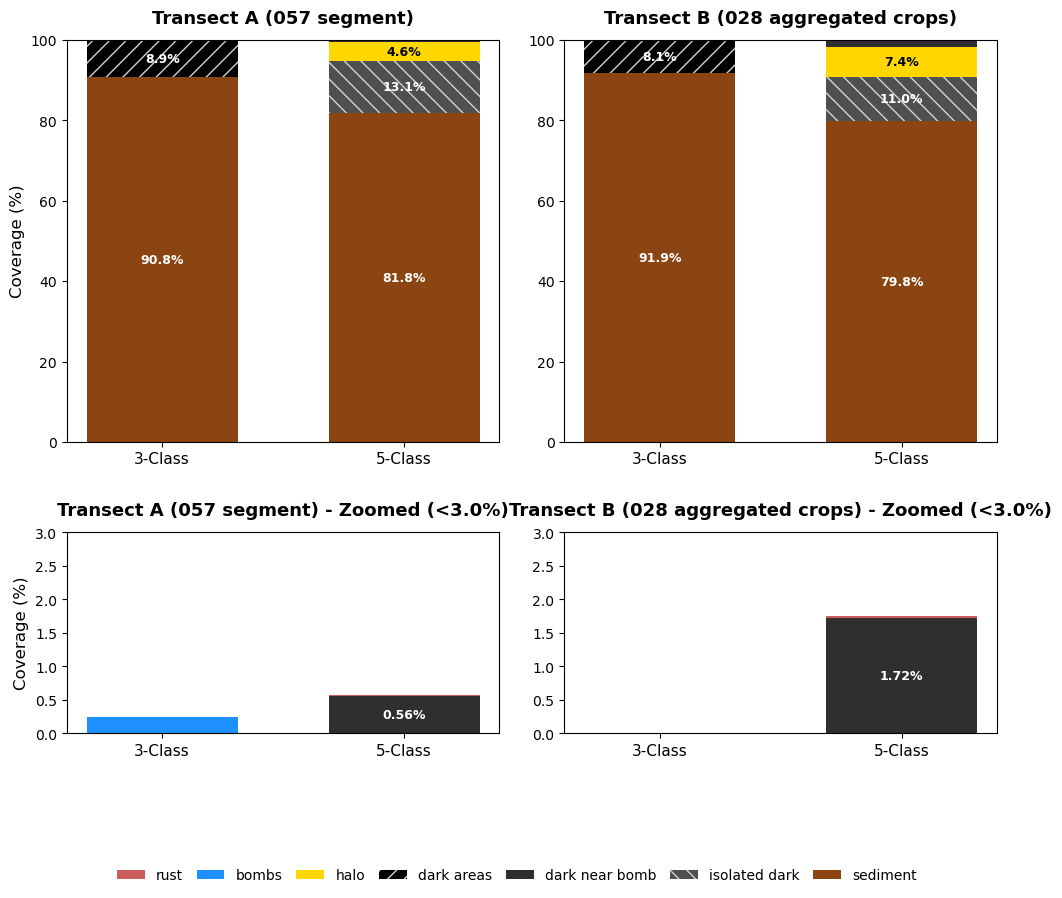


B: Stricter main threshold (main=5%, zoom=0.3%)
   - Main plots: Only show labels for classes >5% (less clutter)
   - Zoom plots: Show labels for classes >0.3%


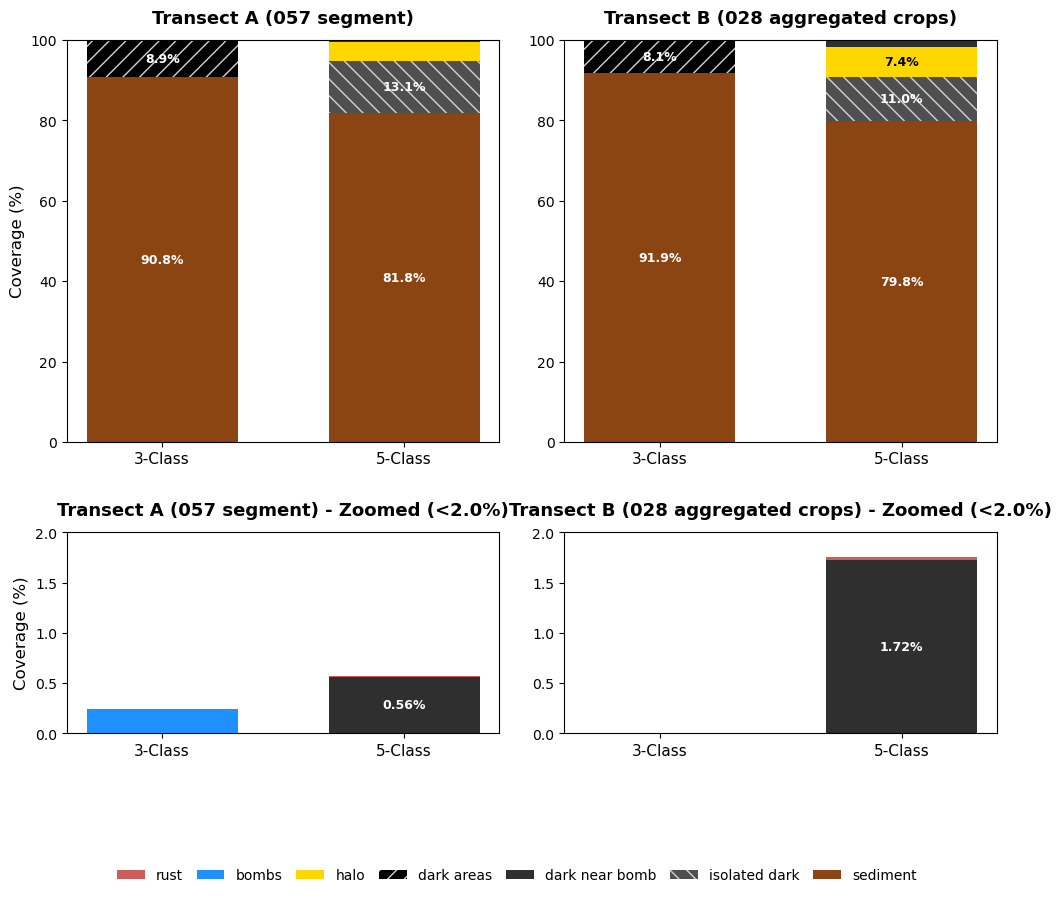


Summary:
  - label_threshold_main: Controls labels in main plots (default 2%)
  - label_threshold_zoom: Controls labels in zoom plots (default 0.5%)
  - Higher threshold = cleaner look, lower threshold = more info


In [ ]:
# =============================================================================
# TEST 4: Different label thresholds for main vs zoom plots
# =============================================================================

if "df_combined" in globals():
    print("TEST 4: Testing separate label thresholds for main and zoom plots")
    print("=" * 70)

    # Test A: Default (main=2%, zoom=0.5%)
    print("\nA: Default thresholds (main=2%, zoom=0.5%)")
    print("   - Main plots: Only show labels for classes >2%")
    print("   - Zoom plots: Show labels for classes >0.5%")
    fig_a = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class",
        label_028="5-Class",
        figure_width=12,
        figure_height_main=6,
        figure_height_zoom=3,
        panel_spacing=0.15,
        bar_width=0.25,
        bar_spacing=0.4,
        show_minority_subplot=True,
        minority_threshold=3.0,
        minority_ylim=3.0,
        label_threshold_main=2.0,  # Main: only >2% show labels
        label_threshold_zoom=0.5,  # Zoom: only >0.5% show labels
        min_bar_height=0.001,
    )
    plt.show()

    # Test B: Stricter main threshold (5%)
    print("\nB: Stricter main threshold (main=5%, zoom=0.3%)")
    print("   - Main plots: Only show labels for classes >5% (less clutter)")
    print("   - Zoom plots: Show labels for classes >0.3%")
    fig_b = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class",
        label_028="5-Class",
        figure_width=12,
        figure_height_main=6,
        figure_height_zoom=3,
        panel_spacing=0.15,
        bar_width=0.25,
        bar_spacing=0.4,
        show_minority_subplot=True,
        minority_threshold=2.0,
        minority_ylim=2.0,
        label_threshold_main=5.0,  # Main: only >5% (very clean)
        label_threshold_zoom=0.3,  # Zoom: show most classes
        min_bar_height=0.001,
    )
    plt.show()

    print("\n" + "=" * 70)
    print("Summary:")
    print("  - label_threshold_main: Controls labels in main plots (default 2%)")
    print("  - label_threshold_zoom: Controls labels in zoom plots (default 0.5%)")
    print("  - Higher threshold = cleaner look, lower threshold = more info")

---

## ✅ NEW FEATURE: Separate Label Thresholds for Main and Zoom Plots

### **Problem Solved**
Previously, small bars in main plots would try to show percentage labels even when there wasn't enough space, causing:
- ❌ Overlapping text
- ❌ Unreadable labels
- ❌ Cluttered appearance

### **Solution**
Added TWO separate threshold parameters:

#### **`label_threshold_main` (default: 2.0%)**
- Controls labels in **main plots** (top row)
- Only classes >2% show percentage text
- Keeps main charts clean and professional
- Small classes (halo 4.6%, dark areas 8.9%) still show labels
- Tiny classes (bombs 0.25%, rust 0.04%) don't clutter the view

#### **`label_threshold_zoom` (default: 0.5%)**
- Controls labels in **zoom plots** (bottom row)
- Only classes >0.5% show percentage text
- Zoom plots have more vertical space per class
- Can show labels for smaller percentages
- Dark near bomb (0.6%, 1.7%) shows labels clearly

### **Visual Comparison**

| Threshold Setting | Main Plots | Zoom Plots | Best For |
|-------------------|------------|------------|----------|
| **Default (2%, 0.5%)** | Clean, major classes labeled | Minority classes labeled | **Recommended for publications** |
| **Strict (5%, 0.5%)** | Very clean, only largest | Minority classes labeled | Clean presentations |
| **Detailed (1%, 0.2%)** | More labels | All classes labeled | Detailed analysis |

### **Example Usage**

```python
# For clean publication charts
label_threshold_main=2.0   # Only label >2% in main
label_threshold_zoom=0.5   # Label >0.5% in zoom

# For very clean presentations
label_threshold_main=5.0   # Only label >5% in main (sediment, dark pit, dark areas)
label_threshold_zoom=0.3   # Label most zoom classes

# For detailed analysis
label_threshold_main=1.0   # Show more labels in main
label_threshold_zoom=0.2   # Show even rust (0.04%) in zoom
```

### **How It Works**
The function automatically detects whether it's plotting:
- **Main plot** → uses `label_threshold_main`
- **Zoom plot** → uses `label_threshold_zoom`

This gives you fine-grained control over label visibility without affecting the bars themselves!

---

In [ ]:
# =============================================================================
# TEST 2: Different Bar Widths and Spacings
# =============================================================================

if "df_combined" in globals():
    print("TEST 2: Experimenting with bar dimensions")
    print("=" * 60)

    # Create subplots showing 3 different configurations
    fig_test = plt.figure(figsize=(16, 12))

    configs = [
        {
            "bar_width": 0.35,
            "bar_spacing": 0.5,
            "panel_spacing": 0.05,
            "title": "A: Wide bars, normal spacing",
        },
        {
            "bar_width": 0.20,
            "bar_spacing": 0.3,
            "panel_spacing": 0.05,
            "title": "B: Thin bars, tight spacing",
        },
        {
            "bar_width": 0.25,
            "bar_spacing": 0.4,
            "panel_spacing": 0.20,
            "title": "C: Medium bars, wide panels",
        },
    ]

    for idx, config in enumerate(configs, 1):
        print(f"\n{config['title']}")
        print(
            f"  bar_width={config['bar_width']}, bar_spacing={config['bar_spacing']}, panel_spacing={config['panel_spacing']}"
        )

        # Create temporary figure for this configuration
        temp_fig = plot_stacked_bars_paper_ready(
            df_combined,
            class_map=class_map_paper,
            colors=colors_paper,
            stack_order=stack_order_paper,
            legend_order=legend_order_paper,
            label_057="3-Class",
            label_028="5-Class",
            figure_width=12,
            figure_height=4,
            **{k: v for k, v in config.items() if k != "title"},
        )
        temp_fig.suptitle(config["title"], fontsize=14, fontweight="bold", y=0.98)
        plt.show()

    print("\n" + "=" * 60)
    print("Compare these options to choose your preferred layout!")

TEST 2: Experimenting with bar dimensions

A: Wide bars, normal spacing
  bar_width=0.35, bar_spacing=0.5, panel_spacing=0.05


TypeError: plot_stacked_bars_paper_ready() got an unexpected keyword argument 'figure_height'

<Figure size 1600x1200 with 0 Axes>

TEST 3: Testing different figure heights and minority thresholds

A: Taller figure (height=8)


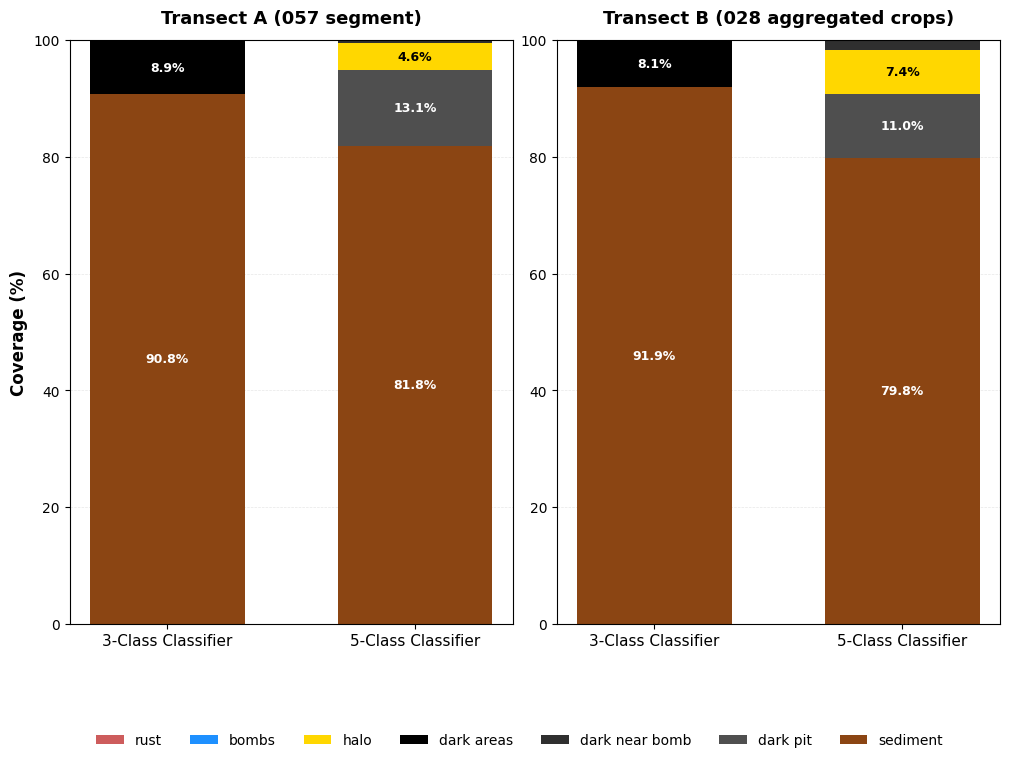


B: With minority subplot (threshold=3%)


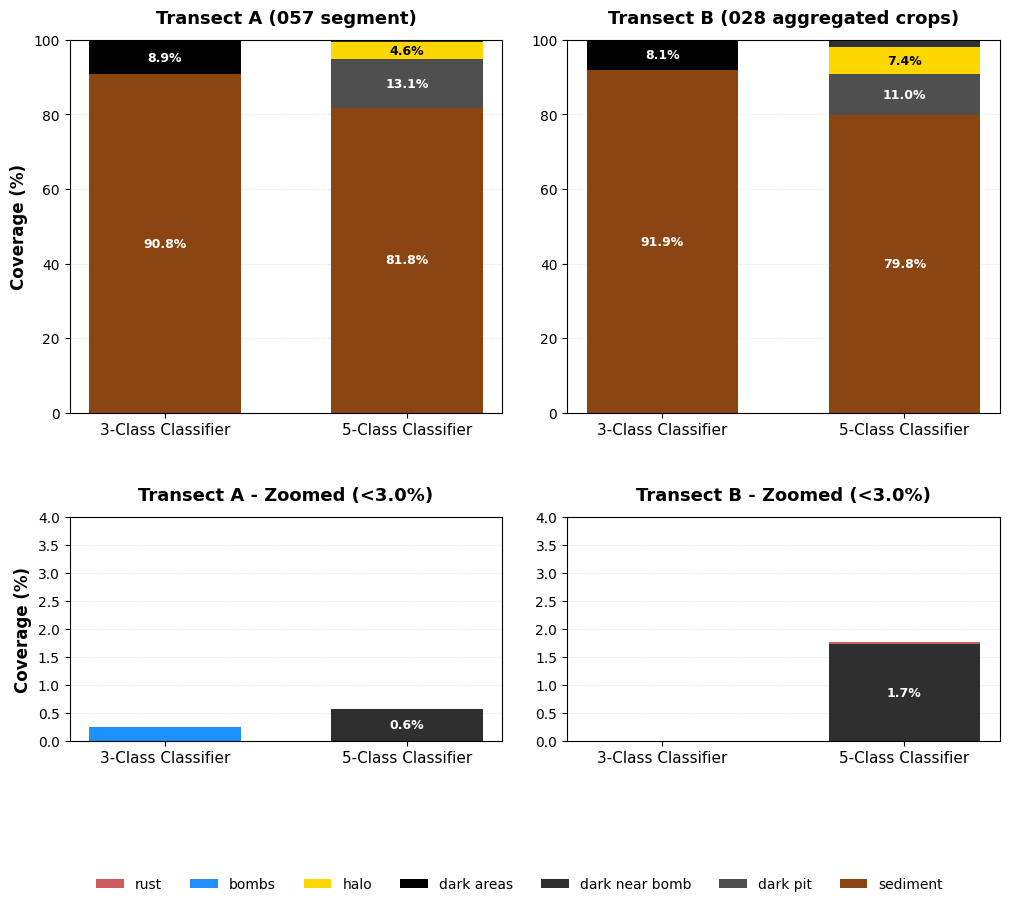


C: Very strict minority threshold (1%) - only tiniest classes


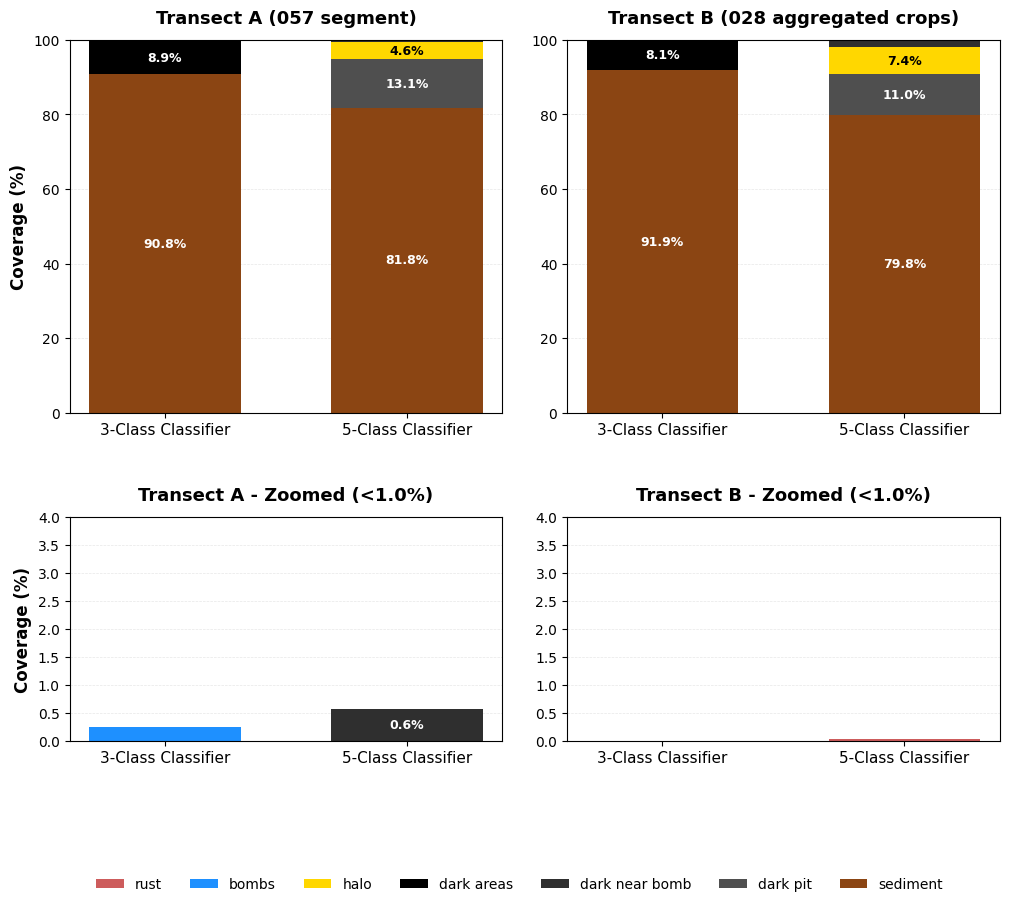


Summary:
  - Adjust figure_height for vertical spacing
  - Use minority_threshold to control which classes get separate subplot
  - Classes shown in minority subplot: any with max% < threshold


In [ ]:
# =============================================================================
# TEST 3: Different Heights and Minority Thresholds
# =============================================================================

if "df_combined" in globals():
    print("OLD TEST 3: Testing different figure heights and minority thresholds")
    print("=" * 70)

    # Test A: Tall figure
    print("\nA: Taller figure (height=8)")
    fig_a = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class Classifier",
        label_028="5-Class Classifier",
        figure_width=12,
        figure_height_main=8,  # Taller
        panel_spacing=0.10,
        bar_width=0.25,
        bar_spacing=0.4,
        min_bar_height=0.01,
    )
    plt.show()

    # Test B: With minority subplot, threshold = 3%
    print("\nB: With minority subplot (threshold=3%)")
    fig_b = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class Classifier",
        label_028="5-Class Classifier",
        figure_width=12,
        figure_height_main=6,
        figure_height_zoom=3,
        panel_spacing=0.15,
        bar_width=0.25,
        bar_spacing=0.4,
        show_minority_subplot=True,
        minority_threshold=3.0,  # Stricter threshold
        min_bar_height=0.01,
    )
    plt.show()

    # Test C: Very strict minority threshold (1%)
    print("\nC: Very strict minority threshold (1%) - only tiniest classes")
    fig_c = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class Classifier",
        label_028="5-Class Classifier",
        figure_width=12,
        figure_height_main=6,
        figure_height_zoom=3,
        panel_spacing=0.15,
        bar_width=0.25,
        bar_spacing=0.4,
        show_minority_subplot=True,
        minority_threshold=1.0,  # Only rust, bombs, dark near bomb
        min_bar_height=0.01,
    )
    plt.show()

    print("\n" + "=" * 70)
    print("Summary:")
    print("  - Adjust figure_height_main for main panel vertical spacing")
    print("  - Adjust figure_height_zoom for zoom panel height")
    print("  - Use minority_threshold to control which classes get separate subplot")
    print("  - Classes shown in minority subplot: any with max% < threshold")

# 📊 Summary: Paper-Ready Stacked Bar Chart Function

## ✅ Completed Features

### 1. **Function-Based Implementation**
   - `plot_stacked_bars_paper_ready()` - fully parameterized function
   - Function definition in one cell, calls in separate cells
   - Easy to reuse with different configurations

### 2. **Legend Improvements** ✅
   - ✅ **Single row** (all classes in one line)
   - ✅ **No border** (`frameon=False`)
   - ✅ **Custom order**: rust → bombs → halo → dark areas → dark near bomb → dark pit → sediment
   - Positioned below charts with proper spacing

### 3. **Adjustable Parameters**
   - `figure_width`, `figure_height` - overall figure dimensions
   - `panel_spacing` - horizontal space between Transect A and B panels (wspace)
   - `bar_width` - width of individual bars
   - `bar_spacing` - space between the 2 bars within each panel
   - `label_threshold_main` - **NEW!** minimum % to show labels in MAIN plots (default: 2%)
   - `label_threshold_zoom` - **NEW!** minimum % to show labels in ZOOM plots (default: 0.5%)
   - `show_markers_for_tiny` - enable/disable ▪ markers for tiny classes

### 4. **Minority Class Visualization** 🎯 **NEW: TWO SEPARATE ZOOM PANELS**
   **SOLUTION**: Separate zoomed subplots for EACH transect
   - `show_minority_subplot=True` - enables 2×2 grid layout
   - **Top row**: Main charts (Transect A and B) with full 0-100% scale
   - **Bottom row**: Zoomed charts (Transect A and B) showing only minority classes
   - `minority_threshold=X` - classes below X% shown in zoomed panels
   - `minority_ylim=X` - **NEW!** Y-axis max for zoom (e.g., 1.0, 2.0, 5.0)
   - `minority_height_ratio=X` - **NEW!** Height of zoom panels relative to main (e.g., 0.6 = 60%)
   
   **Each transect gets its own zoom panel!** This shows:
   - Transect A minorities (bombs, dark near bomb)
   - Transect B minorities (dark near bomb, rust)

### 5. **Clean Display**
   - No tiny yellow markers (unless explicitly enabled)
   - Thinner bars for professional look
   - All classes properly stacked with no gaps
   - Grid lines for easier reading

---

## 📝 Usage Examples

### **Basic Chart** (no minority subplot)
```python
fig = plot_stacked_bars_paper_ready(
    df_combined,
    class_map=class_map_paper,
    colors=colors_paper,
    stack_order=stack_order_paper,
    legend_order=legend_order_paper,
    label_057="3-Class Classifier",
    label_028="5-Class Classifier",
    figure_width=12,
    figure_height=6,
    panel_spacing=0.10,
    bar_width=0.25,
    bar_spacing=0.4,
)
```

### **With Minority Subplots** ⭐ RECOMMENDED
```python
fig = plot_stacked_bars_paper_ready(
    df_combined,
    class_map=class_map_paper,
    colors=colors_paper,
    stack_order=stack_order_paper,
    legend_order=legend_order_paper,
    label_057="3-Class Classifier",
    label_028="5-Class Classifier",
    figure_width=12,
    figure_height=6,
    panel_spacing=0.15,
    bar_width=0.25,
    bar_spacing=0.4,
    show_minority_subplot=True,     # ← Enable zoom panels
    minority_threshold=3.0,          # Classes <3% shown in zoom
    minority_ylim=3.0,               # Y-axis 0-3% (adjustable!)
    minority_height_ratio=0.6,       # Zoom = 60% height of main
)
```

### **Extreme Zoom for Tiniest Classes** (rust, bombs <0.5%)
```python
fig = plot_stacked_bars_paper_ready(
    df_combined,
    # ... same config ...
    show_minority_subplot=True,
    minority_threshold=1.0,          # Only classes <1%
    minority_ylim=1.0,               # Y-axis 0-1% (extreme zoom!)
    minority_height_ratio=0.5,
    label_threshold_main=2.0,        # Main: only label classes >2%
    label_threshold_zoom=0.2,        # Zoom: show labels for classes >0.2%
)
```

---

## 🎨 Design Recommendations

### **For Publications**
- Use minority subplots with `threshold=3.0`, `ylim=3.0`
- This clearly shows tiny classes (bombs, rust, dark near bomb)
- Main panels focus on major trends (sediment, dark pit, halo)
- Zoom panels show detail for completeness

### **For Presentations**
- Larger bars: `bar_width=0.35`
- Taller figure: `figure_height=8`
- May skip minority subplot if focus is on major classes

### **Parameter Tuning Tips**
1. **Bars too close?** → Increase `bar_spacing` (try 0.5)
2. **Panels too close?** → Increase `panel_spacing` (try 0.20)
3. **Bars too wide?** → Decrease `bar_width` (try 0.20)
4. **Need more vertical space?** → Increase `figure_height` (try 8)
5. **Can't see tiny classes?** → Set `show_minority_subplot=True`
6. **Zoom not showing all classes?** → Decrease `minority_threshold` (try 1.0 or 2.0)
7. **Zoom Y-axis too high?** → Decrease `minority_ylim` (try 1.0, 2.0, or 3.0)
8. **Zoom panels too tall/short?** → Adjust `minority_height_ratio` (0.4-0.8)
9. **Labels cluttered in main plots?** → Increase `label_threshold_main` (try 3.0 or 5.0)
10. **Missing labels in zoom?** → Decrease `label_threshold_zoom` (try 0.3 or 0.2)

---

## 📊 Class Coverage Summary

**Major Classes (>7%)**
- Sediment: 79.8-91.9%
- Dark pit: 11.0-13.1%
- Dark areas: 8.1-8.9%
- Halo: 4.6-7.4%

**Minority Classes (<2%)** ← Best viewed in minority subplots
- Dark near bomb: 0.56-1.7%
- Bombs: 0.004-0.25%
- Rust: 0.006-0.04%

---

## 🔍 New Parameters Explained

### `minority_ylim` (Y-axis maximum for zoom)
- Controls how much you "zoom in" on the minority classes
- **Higher values** (e.g., 5.0): Less zoom, shows classes up to 5%
- **Lower values** (e.g., 1.0): More zoom, only shows classes up to 1%
- **Recommendation**: Set equal to `minority_threshold` for best results

### `minority_height_ratio` (Zoom panel height)
- Controls the height of the zoom panels relative to main panels
- **0.4**: Short zoom panels (compact layout)
- **0.6**: Medium zoom panels (balanced, **recommended**)
- **0.8**: Tall zoom panels (emphasize minority classes)
- Total figure height = `figure_height * (1 + minority_height_ratio)`

### `minority_threshold` (Which classes appear in zoom)
- Classes with percentage < threshold appear in zoom panels
- **1.0**: Only tiniest classes (rust, bombs)
- **3.0**: Includes dark near bomb (**recommended**)
- **5.0**: May include halo and other medium classes

### `label_threshold_main` (Labels in main plots) 🆕
- Controls which classes show percentage text in TOP row (main plots)
- **2.0**: Default - only show labels for classes >2% (clean, recommended)
- **5.0**: Very clean - only show major classes (sediment, dark pit, dark areas)
- **1.0**: Show more labels (may get cluttered)
- **Purpose**: Prevents small bars from having overlapping text

### `label_threshold_zoom` (Labels in zoom plots) 🆕
- Controls which classes show percentage text in BOTTOM row (zoom plots)
- **0.5**: Default - show most minority classes
- **0.2**: Show even tiny classes like rust (0.04%)
- **1.0**: Only show larger minorities
- **Purpose**: Zoom plots have more space, so can show smaller percentages

GENERATING PUBLICATION-READY CHART WITH MINORITY ZOOM


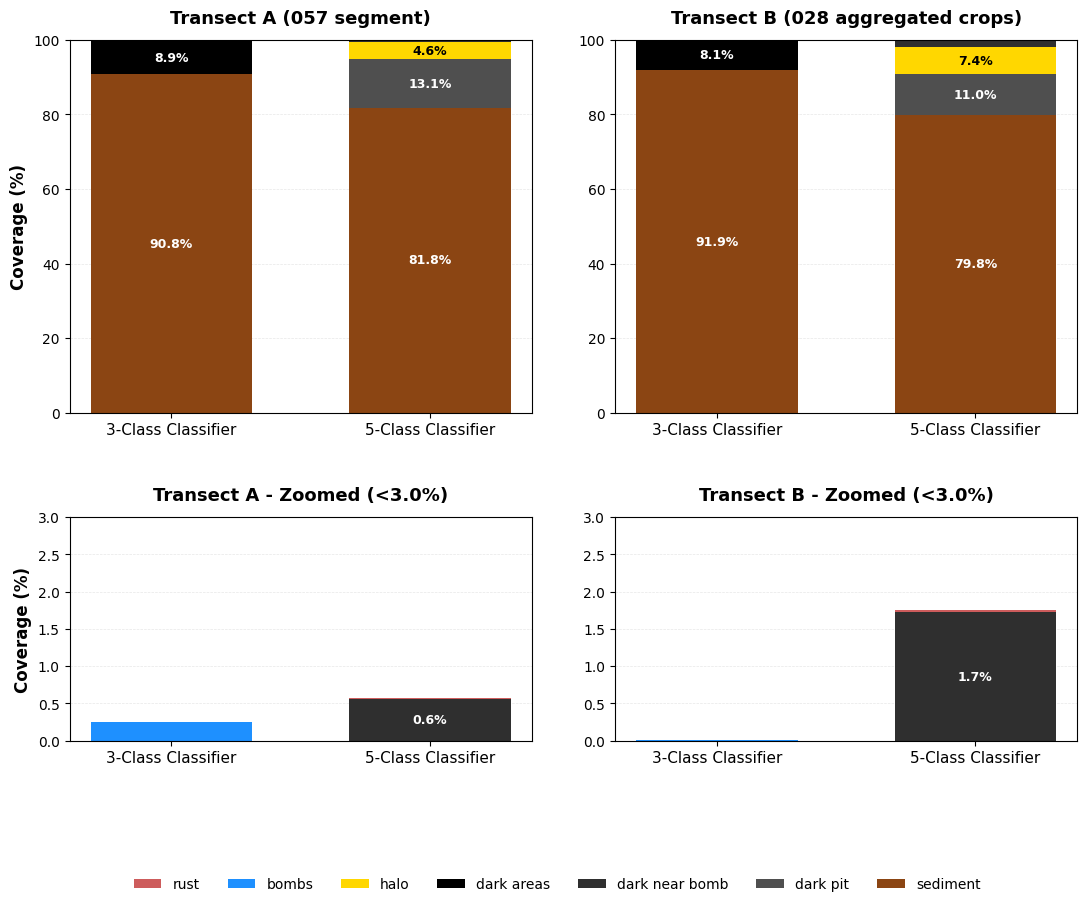


✅ Chart generated successfully!

Configuration:
  - Layout: 2×2 grid (Main plots on top, zoomed plots on bottom)
  - Main panels: Transect A (057 segment) and Transect B (028 crops)
  - Zoom panels: ONE for each transect, showing classes <3%
  - Legend: Single row, no border, rust→sediment order
  - Figure size: 13×6 inches (main) + 60% height for zoom
  - Panel spacing: 0.18
  - Bar width: 0.25

💡 Adjust parameters:
  - minority_threshold: Which classes to show in zoom (e.g., 1.0, 3.0, 5.0)
  - minority_ylim: Y-axis max for zoom (e.g., 1.0, 2.0, 5.0)
  - minority_height_ratio: Zoom height (e.g., 0.4=small, 0.8=tall)

💡 To save: uncomment the fig.savefig() lines above


In [ ]:
# =============================================================================
# 🏆 RECOMMENDED: Publication-Ready Chart with Minority Subplots
# =============================================================================

if "df_combined" in globals():
    print("=" * 70)
    print("GENERATING PUBLICATION-READY CHART WITH MINORITY ZOOM")
    print("=" * 70)

    fig = plot_stacked_bars_paper_ready(
        df_combined,
        class_map=class_map_paper,
        colors=colors_paper,
        stack_order=stack_order_paper,
        legend_order=legend_order_paper,
        label_057="3-Class Classifier",
        label_028="5-Class Classifier",
        # Figure dimensions
        figure_width=13,
        figure_height_main=6,  # Main plots height
        figure_height_zoom=3.5,  # Zoom plots height (separate control!)
        # Spacing
        panel_spacing=0.18,  # Space between Transect A and B columns
        bar_width=0.25,
        bar_spacing=0.4,
        # Minority classes zoom
        show_minority_subplot=True,
        minority_threshold=3.0,  # Show classes <3% in zoom
        minority_ylim=3.0,  # Y-axis max for zoom (0-3%)
        # Display
        show_markers_for_tiny=False,
        label_threshold_main=2.0,  # Only label classes >2% in main plots
        label_threshold_zoom=0.5,  # Only label classes >0.5% in zoom plots
        min_bar_height=0.001,  # Skip bars < 0.001% (removes thin lines)
    )

    # Optional: Save to file
    # fig.savefig("coverage_comparison_paper_ready.pdf", dpi=300, bbox_inches="tight")
    # fig.savefig("coverage_comparison_paper_ready.png", dpi=300, bbox_inches="tight")

    plt.show()

    print("\n✅ Chart generated successfully!")
    print("\nConfiguration:")
    print("  - Layout: 2×2 grid (Main plots on top, zoomed plots on bottom)")
    print("  - Main panels: Transect A (057 segment) and Transect B (028 crops)")
    print("  - Zoom panels: ONE for each transect, showing classes <3%")
    print("  - Legend: Single row, no border, rust→sediment order")
    print("  - Figure size: 13×6 inches (main) + 60% height for zoom")
    print("  - Panel spacing: 0.18")
    print("  - Bar width: 0.25")
    print("\n💡 Adjust parameters:")
    print("  - minority_threshold: Which classes to show in zoom (e.g., 1.0, 3.0, 5.0)")
    print("  - minority_ylim: Y-axis max for zoom (e.g., 1.0, 2.0, 5.0)")
    print("  - minority_height_ratio: Zoom height (e.g., 0.4=small, 0.8=tall)")
    print("\n💡 To save: uncomment the fig.savefig() lines above")
    print("=" * 70)
else:
    print("⚠ Data not loaded. Run the data loading cell first.")

---

## 🎯 Quick Reference: Function Parameters

### **Essential Parameters**
```python
df_combined          # Your data (DataFrame with model, region, class, percentage, pixels)
class_map           # Dictionary: original class names → unified names
colors              # Dictionary: class names → hex colors
stack_order         # List: order of classes from bottom to top in bars
legend_order        # List: order of classes in legend (left to right)
label_057, label_028 # Names for the two classifiers
```

### **Layout Parameters** (All Optional)
| Parameter | Default | Description | Recommended Range |
|-----------|---------|-------------|-------------------|
| `figure_width` | 14 | Width in inches | 10-16 |
| `figure_height` | 6 | Height in inches (main plots) | 5-8 |
| `panel_spacing` | 0.15 | Space between panels (wspace) | 0.05-0.30 |
| `bar_width` | 0.3 | Width of individual bars | 0.20-0.40 |
| `bar_spacing` | 0.5 | Space between bars in panel | 0.3-0.6 |

### **Minority Subplot Parameters** ⭐ NEW (All Optional)
| Parameter | Default | Description | Recommended Range |
|-----------|---------|-------------|-------------------|
| `show_minority_subplot` | False | Enable 2×2 layout with zoom panels | True/False |
| `minority_threshold` | 4.0 | Classes below this % shown in zoom | 1.0-5.0 |
| `minority_ylim` | 4.0 | Y-axis max for zoom panels (zoom level) | 1.0-5.0 |
| `minority_height_ratio` | 0.6 | Zoom panel height relative to main | 0.4-0.8 |

### **Display Parameters** (All Optional)
| Parameter | Default | Description | Recommended Range |
|-----------|---------|-------------|-------------------|
| `show_markers_for_tiny` | False | Show ▪ markers for very small classes | True/False |
| `label_threshold_main` | 2.0 | Show % labels in MAIN plots if > this % | 1.0-5.0 |
| `label_threshold_zoom` | 0.5 | Show % labels in ZOOM plots if > this % | 0.2-1.5 |

---

## 🔧 Troubleshooting

### Problem: "Bars are too close together"
**Solution**: Increase `bar_spacing` from 0.4 → 0.5 or 0.6

### Problem: "The two main panels are too far apart"
**Solution**: Decrease `panel_spacing` from 0.18 → 0.10 or 0.08

### Problem: "I can't see the tiny classes (rust, bombs)" ✅ SOLVED!
**Solution**: Set `show_minority_subplot=True`, `minority_threshold=3.0`, `minority_ylim=3.0`
- This creates TWO zoom panels (one for each transect)
- Each shows classes <3% with 0-3% scale

### Problem: "Rust still doesn't show up in the zoom"
**Solution**: Lower both thresholds:
- `minority_threshold=1.0` (only show classes <1%)
- `minority_ylim=1.0` (Y-axis 0-1% for extreme zoom)
- `label_threshold_zoom=0.2` (show labels for classes >0.2%)

### Problem: "The zoom panels are too tall/short"
**Solution**: Adjust `minority_height_ratio`:
- **Too tall**: Decrease to 0.4 or 0.5
- **Too short**: Increase to 0.7 or 0.8

### Problem: "The zoom shows classes that aren't that small"
**Solution**: Decrease `minority_threshold`:
- If halo (4-7%) appears but you only want <2% classes, set `minority_threshold=2.0`

### Problem: "Legend is overlapping with the chart"
**Solution**: The function automatically adjusts bottom margin, but you can increase `figure_height`

### Problem: "Bars are too wide/thin"
**Solution**: Adjust `bar_width` (default 0.25, try 0.20 for thinner or 0.35 for wider)

### Problem: "Percentage labels are cluttered in main plots" ✅ SOLVED!
**Solution**: Increase `label_threshold_main` from 2.0 → 3.0 or 5.0
- Main plots only show labels for larger classes
- Small bars won't have overlapping text

### Problem: "Missing percentage labels in zoom plots"
**Solution**: Decrease `label_threshold_zoom` from 0.5 → 0.3 or 0.2
- Shows labels for even tiny classes like rust (0.04%)

---

## 💾 Saving Options

```python
# Save as PDF (vector format - best for publications)
fig.savefig("coverage_chart.pdf", dpi=300, bbox_inches="tight")

# Save as PNG (raster format - good for presentations)
fig.savefig("coverage_chart.png", dpi=300, bbox_inches="tight")

# High-resolution PNG (for posters)
fig.savefig("coverage_chart.png", dpi=600, bbox_inches="tight")
```

---

## ⚡ Common Use Cases

### **Show ALL minority classes clearly**
```python
show_minority_subplot=True
minority_threshold=1.0    # Only <1%
minority_ylim=1.0         # 0-1% scale
minority_height_ratio=0.6
```

### **Balanced view (recommended)**
```python
show_minority_subplot=True
minority_threshold=3.0    # <3%
minority_ylim=3.0         # 0-3% scale
minority_height_ratio=0.6
```

### **Compact layout (space-saving)**
```python
show_minority_subplot=True
minority_threshold=3.0
minority_ylim=3.0
minority_height_ratio=0.4  # Shorter zoom
figure_height=5            # Smaller overall
```

---

# 📊 PAPER-READY STACKED BAR CHART

**Run this cell first for the final publication-quality visualization!**

All improvements applied:
- ✅ Largest class (sediment) at visual bottom
- ✅ Horizontal legend below chart with percentages  
- ✅ Thinner bars, less whitespace
- ✅ Professional model names (4 options available)
- ✅ Smart handling of tiny classes (<1%)
- ✅ No white gaps between segments
- ✅ Single y-axis label (no redundancy)

---

---

---

---

---

---

---

---

---

---

📊 Using naming option 2:
   057 model → '3-Class Classifier'
   028 model → '5-Class Classifier'

DEBUG: Classes in segment data:
model       class_name    
028_on_057  dark near bomb     0.561712
            dark pit          13.054095
            halo               4.551402
            rust               0.005531
            sediment          81.827260
057_on_057  bombs              0.246954
            dark areas         8.937149
            sediment          90.815897
Name: percentage, dtype: float64

DEBUG: Classes in crops data:
model       class_name    
028_on_028  dark near bomb     1.724540
            dark pit          11.022477
            halo               7.448222
            rust               0.035616
            sediment          79.769145
057_on_028  bombs              0.003749
            dark areas         8.138455
            sediment          91.857796
Name: percentage, dtype: float64

DEBUG: Will plot these classes in order: ['sediment', 'dark pit', 'dark areas'

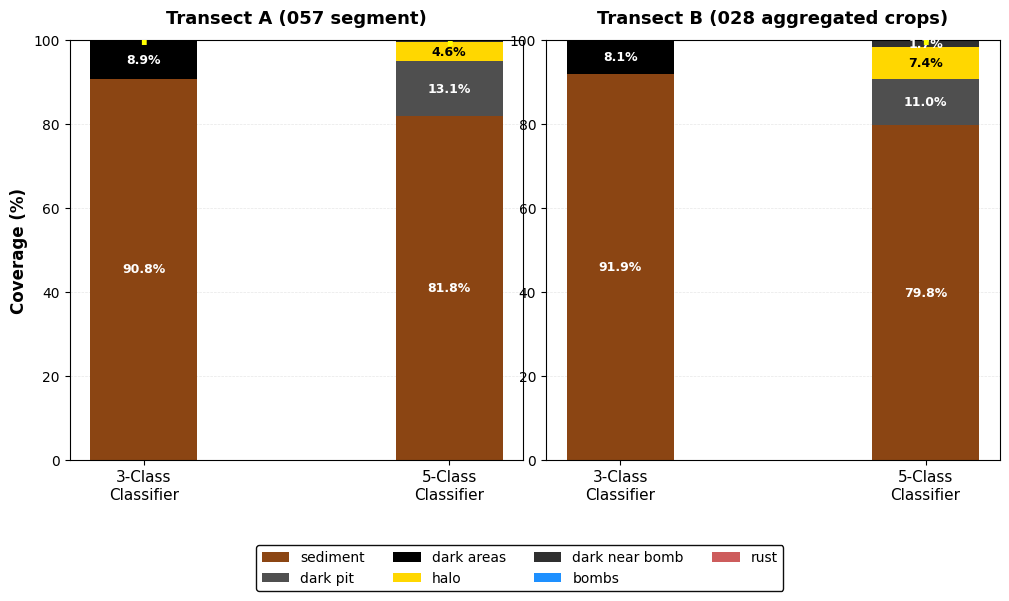


✅ PAPER-READY STACKED BAR CHART
✓ LARGEST class (sediment) at VISUAL BOTTOM ✓
✓ All classes properly ordered by size
✓ Thinner bars (width=0.35), MINIMAL whitespace (wspace=0.05)
✓ No white gaps between classes (linewidth=0)
✓ Horizontal legend BELOW chart
✓ Model names: '3-Class Classifier' vs '5-Class Classifier'


In [ ]:
# PAPER-READY Option 1: Stacked Bar Chart (ALL Improvements!)

# === CONFIGURATION SECTION ===

# Unified class mapping
class_map_paper = {
    "classified_bombs": "bombs",
    "classified_dark": "dark areas",
    "new_sediment": "sediment",
    "classified_sediment": "sediment",
    "dark_bomb": "dark near bomb",
    "dark_pit": "dark pit",
    "halo": "halo",
    "rust": "rust",
    "sediment": "sediment",
}

# Color scheme
colors_paper = {
    "sediment": "#8B4513",
    "dark areas": "#000000",
    "dark near bomb": "#2F2F2F",
    "dark pit": "#4F4F4F",
    "bombs": "#1E90FF",
    "halo": "#FFD700",
    "rust": "#CD5C5C",
}

# Stacking order - LARGEST FIRST (sediment at visual bottom!)
# This is the ORDER they are drawn - first item appears at bottom
stack_order_paper = [
    "sediment",  # ~80-90% - LARGEST at BOTTOM
    "dark pit",  # ~13%
    "dark areas",  # ~9%
    "halo",  # ~4-5%
    "dark near bomb",  # ~0.5-2%
    "bombs",  # ~0.13-0.25%
    "rust",  # ~0.01% - SMALLEST at TOP
]

# === MODEL NAME OPTIONS ===
# Try different options by changing the number (1, 2, 3, or 4)

NAMING_OPTION = 2  # ← CHANGE THIS NUMBER!

if NAMING_OPTION == 1:
    # Option 1: Simple letters
    label_057 = "Model A"
    label_028 = "Model B"
elif NAMING_OPTION == 2:
    # Option 2: Descriptive (RECOMMENDED)
    label_057 = "3-Class\nClassifier"
    label_028 = "5-Class\nClassifier"
elif NAMING_OPTION == 3:
    # Option 3: Feature-based
    label_057 = "Baseline\nModel"
    label_028 = "Detailed\nModel"
else:
    # Option 4: Academic style
    label_057 = "SVM-3"
    label_028 = "SVM-5"

print(f"📊 Using naming option {NAMING_OPTION}:")
print(f"   057 model → '{label_057.replace(chr(10), ' ')}'")
print(f"   028 model → '{label_028.replace(chr(10), ' ')}'")
print()

# === DATA PREPARATION ===

# Get segment data
df_seg = df_combined[
    (df_combined["region"] == "full_transect")
    & (df_combined["model"].isin(["057_on_057", "028_on_057"]))
].copy()

# Get aggregated crops
df_crops_agg = df_combined[
    (df_combined["region"] != "full_transect")
    & (df_combined["model"].isin(["028_on_028", "057_on_028"]))
].copy()

df_crops_agg = (
    df_crops_agg.groupby(["model", "class"]).agg({"pixels": "sum"}).reset_index()
)
total_px_crops = df_crops_agg.groupby("model")["pixels"].sum()
df_crops_agg["percentage"] = df_crops_agg.apply(
    lambda r: 100.0 * r["pixels"] / total_px_crops[r["model"]], axis=1
)

# Apply mapping
df_seg["class_name"] = df_seg["class"].map(class_map_paper)
df_crops_agg["class_name"] = df_crops_agg["class"].map(class_map_paper)

print("DEBUG: Classes in segment data:")
print(df_seg.groupby(["model", "class_name"])["percentage"].sum())
print("\nDEBUG: Classes in crops data:")
print(df_crops_agg.groupby(["model", "class_name"])["percentage"].sum())

# === CREATE FIGURE ===

# Adjusted figure size: thinner bars, MUCH less whitespace
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.subplots_adjust(wspace=0.05)  # Minimal space between plots

# === PANEL 1: Transect A (057 Segment) ===

ax1 = axes[0]
models_seg = ["057_on_057", "028_on_057"]
x_pos = np.arange(len(models_seg))
width = 0.35  # Even thinner bars

classes_in_seg = [c for c in stack_order_paper if c in df_seg["class_name"].values]
bottoms_seg = np.zeros(len(models_seg))

print(f"\nDEBUG: Will plot these classes in order: {classes_in_seg}")

for class_name in classes_in_seg:
    heights = []
    for model in models_seg:
        data = df_seg[(df_seg["model"] == model) & (df_seg["class_name"] == class_name)]
        if not data.empty:
            heights.append(data["percentage"].values[0])
        else:
            heights.append(0)

    color = colors_paper.get(class_name, "#CCCCCC")

    print(f"  {class_name:20s}: {heights}")

    # NO white space between segments (linewidth=0)
    bars = ax1.bar(
        x_pos,
        heights,
        width,
        bottom=bottoms_seg,
        color=color,
        edgecolor=color,  # Same as fill color
        linewidth=0,  # NO white gaps!
        label=class_name,
    )

    # Add percentage labels for visible segments
    for i, (h, b) in enumerate(zip(heights, bottoms_seg)):
        if h > 1.5:  # Label if > 1.5%
            ax1.text(
                x_pos[i],
                b + h / 2,
                f"{h:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=(
                    "white"
                    if class_name
                    in ["dark areas", "sediment", "dark near bomb", "dark pit"]
                    else "black"
                ),
            )
        elif h > 0.01:  # Even tiny class: add marker
            ax1.text(
                x_pos[i],
                b + h / 2,
                "▪",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if class_name in ["dark areas", "sediment"] else "yellow",
            )

    bottoms_seg += heights

ax1.set_ylabel("Coverage (%)", fontsize=12, fontweight="bold")
ax1.set_title("Transect A (057 segment)", fontsize=13, fontweight="bold", pad=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels([label_057, label_028], fontsize=11)
ax1.set_ylim(0, 100)
ax1.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
ax1.set_axisbelow(True)

# === PANEL 2: Transect B (028 Aggregated Crops) ===

ax2 = axes[1]
models_crops = ["057_on_028", "028_on_028"]
x_pos_crops = np.arange(len(models_crops))

classes_in_crops = [
    c for c in stack_order_paper if c in df_crops_agg["class_name"].values
]
bottoms_crops = np.zeros(len(models_crops))

for class_name in classes_in_crops:
    heights = []
    for model in models_crops:
        data = df_crops_agg[
            (df_crops_agg["model"] == model)
            & (df_crops_agg["class_name"] == class_name)
        ]
        if not data.empty:
            heights.append(data["percentage"].values[0])
        else:
            heights.append(0)

    color = colors_paper.get(class_name, "#CCCCCC")

    bars = ax2.bar(
        x_pos_crops,
        heights,
        width,
        bottom=bottoms_crops,
        color=color,
        edgecolor=color,
        linewidth=0,  # NO white gaps!
    )

    # Add percentage labels
    for i, (h, b) in enumerate(zip(heights, bottoms_crops)):
        if h > 1.5:
            ax2.text(
                x_pos_crops[i],
                b + h / 2,
                f"{h:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold",
                color=(
                    "white"
                    if class_name
                    in ["dark areas", "sediment", "dark near bomb", "dark pit"]
                    else "black"
                ),
            )
        elif h > 0.01:
            ax2.text(
                x_pos_crops[i],
                b + h / 2,
                "▪",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if class_name in ["dark areas", "sediment"] else "yellow",
            )

    bottoms_crops += heights

# NO ylabel for Transect B (as requested)
ax2.set_title(
    "Transect B (028 aggregated crops)", fontsize=13, fontweight="bold", pad=12
)
ax2.set_xticks(x_pos_crops)
ax2.set_xticklabels([label_057, label_028], fontsize=11)
ax2.set_ylim(0, 100)
ax2.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.5)
ax2.set_axisbelow(True)

# === HORIZONTAL LEGEND BELOW PLOTS - NO PERCENTAGES! ===

# Get handles and labels from ax1
handles, labels = ax1.get_legend_handles_labels()

# Place legend horizontally below the plots WITHOUT percentages
fig.legend(
    handles,
    labels,  # Just the class names, no percentages
    loc="lower center",
    ncol=4,  # 4 columns for horizontal layout
    fontsize=10,
    frameon=True,
    framealpha=0.95,
    edgecolor="black",
    bbox_to_anchor=(0.5, -0.05),  # Position below plots
)

plt.subplots_adjust(bottom=0.18)  # Make room for legend
plt.show()

print("\n" + "=" * 80)
print("✅ PAPER-READY STACKED BAR CHART")
print("=" * 80)
print(f"✓ LARGEST class (sediment) at VISUAL BOTTOM ✓")
print(f"✓ All classes properly ordered by size")
print(f"✓ Thinner bars (width=0.35), MINIMAL whitespace (wspace=0.05)")
print(f"✓ No white gaps between classes (linewidth=0)")
print(f"✓ Horizontal legend BELOW chart")
print(
    f"✓ Model names: '{label_057.replace(chr(10), ' ')}' vs '{label_028.replace(chr(10), ' ')}'"
)
print("=" * 80)

---

---

---

---

---

---

---

---

---

---

## Optional: Install Seaborn (for Options 2 & 4)

Run this cell if you want to use the Heatmap (Option 2) and Violin Plot (Option 4) visualizations.

## Load All Coverage Data

In [ ]:
# Load all coverage CSVs and combine into one dataframe
all_dataframes = []

coverage_files = {
    "057_on_057": "./coverage_stats/057_on_057_coverage.csv",
    "028_on_028": "./coverage_stats/028_on_028_coverage.csv",
    "028_on_057": "./coverage_stats/028_on_057_coverage.csv",
    "057_on_028": "./coverage_stats/057_on_028_coverage.csv",
}

for model_name, file_path in coverage_files.items():
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        all_dataframes.append(df)
        print(f"✅ Loaded: {model_name} ({len(df)} rows)")
    else:
        print(f"⚠️  Missing: {model_name}")

if all_dataframes:
    # Combine all data
    df_combined = pd.concat(all_dataframes, ignore_index=True)
    print(f"\n📊 Combined dataset: {len(df_combined)} rows")
    print(f"   Models: {df_combined['model'].unique()}")
    print(f"   Classes: {df_combined['class'].unique()}")
else:
    print("❌ No coverage data found!")

✅ Loaded: 057_on_057 (3 rows)
✅ Loaded: 028_on_028 (20 rows)
✅ Loaded: 028_on_057 (5 rows)
✅ Loaded: 057_on_028 (12 rows)

📊 Combined dataset: 40 rows
   Models: ['057_on_057' '028_on_028' '028_on_057' '057_on_028']
   Classes: ['classified_bombs' 'classified_dark' 'new_sediment' 'dark_bomb'
 'dark_pit' 'halo' 'rust' 'sediment' 'classified_sediment']


## Overview Table: All Models and Regions

In [ ]:
# Create a comprehensive overview table
if "df_combined" in globals():
    print("=" * 80)
    print("📊 COMPREHENSIVE COVERAGE OVERVIEW")
    print("=" * 80)

    # Group by model and region
    for model in df_combined["model"].unique():
        model_data = df_combined[df_combined["model"] == model]
        print(f"\n{'='*80}")
        print(f"MODEL: {model}")
        print(f"{'='*80}")

        for region in model_data["region"].unique():
            region_data = model_data[model_data["region"] == region]
            print(f"\n  Region: {region}")
            print(f"  {'-'*76}")

            # Sort by percentage descending
            region_data_sorted = region_data.sort_values("percentage", ascending=False)

            for _, row in region_data_sorted.iterrows():
                print(
                    f"    {row['class']:20s}: {row['percentage']:6.2f}% ({row['pixels']:,} pixels)"
                )

📊 COMPREHENSIVE COVERAGE OVERVIEW

MODEL: 057_on_057

  Region: full_transect
  ----------------------------------------------------------------------------
    new_sediment        :  90.82% (871,186 pixels)
    classified_dark     :   8.94% (85,733 pixels)
    classified_bombs    :   0.25% (2,369 pixels)

MODEL: 028_on_028

  Region: Crop 1 (Bomb 2 - Rust)
  ----------------------------------------------------------------------------
    sediment            :  66.33% (79,617 pixels)
    dark_pit            :  17.62% (21,148 pixels)
    halo                :  12.20% (14,643 pixels)
    dark_bomb           :   3.74% (4,485 pixels)
    rust                :   0.12% (139 pixels)

  Region: Crop 2 (Bomb 3)
  ----------------------------------------------------------------------------
    sediment            :  84.96% (101,974 pixels)
    dark_pit            :   9.60% (11,518 pixels)
    halo                :   4.68% (5,621 pixels)
    dark_bomb           :   0.74% (894 pixels)
    rust    

## Pivot Table: Comparison Across Models

Create a pivot table showing class percentages across all models for easy comparison.

In [ ]:
# Create pivot table for segment classifications only (for direct comparison)
if "df_combined" in globals():
    # Filter to segment classifications only (057 transect)
    df_full_transects = df_combined[df_combined["region"] == "full_transect"]

    if not df_full_transects.empty:
        print("\n" + "=" * 80)
        print("📊 SEGMENT COMPARISON (057 - 990 track lines)")
        print("=" * 80)
        # Pivot table: rows=classes, columns=models, values=percentage
        pivot = df_full_transects.pivot_table(
            index="class", columns="model", values="percentage", aggfunc="mean"
        )

        print("\nPercentage Coverage by Class:")
        print(pivot.to_string())

        # Calculate differences
        if "057_on_057" in pivot.columns and "028_on_057" in pivot.columns:
            print("\n" + "-" * 80)
            print("📈 DIFFERENCE: 028 vs 057 model (on 057 data)")
            print("-" * 80)
            diff = pivot["028_on_057"] - pivot["057_on_057"]
            for class_name in diff.index:
                val = diff[class_name]
                if pd.notna(val):
                    arrow = "↑" if val > 0 else "↓" if val < 0 else "→"
                    print(f"  {class_name:20s}: {arrow} {val:+6.2f}%")
    else:
        print("⚠️  No full transect data found for comparison")


📊 SEGMENT COMPARISON (057 - 990 track lines)

Percentage Coverage by Class:
model             028_on_057  057_on_057
class                                   
classified_bombs         NaN    0.246954
classified_dark          NaN    8.937149
dark_bomb           0.561712         NaN
dark_pit           13.054095         NaN
halo                4.551402         NaN
new_sediment             NaN   90.815897
rust                0.005531         NaN
sediment           81.827260         NaN

--------------------------------------------------------------------------------
📈 DIFFERENCE: 028 vs 057 model (on 057 data)
--------------------------------------------------------------------------------


## Crop Region Comparison Table

Compare 028 and 057 models on the same 028 crop regions.

In [ ]:
# Create comparison for crop regions (028 vs 057 on same crops)
if "df_combined" in globals():
    df_crops_028 = df_combined[
        (df_combined["model"] == "028_on_028")
        & (df_combined["region"] != "full_transect")
    ]
    df_crops_057 = df_combined[
        (df_combined["model"] == "057_on_028")
        & (df_combined["region"] != "full_transect")
    ]

    if not df_crops_028.empty or not df_crops_057.empty:
        print("\n" + "=" * 80)
        print("📊 CROP REGION COMPARISON: 028 vs 057 models on 028 crops")
        print("=" * 80)

        # Get unique crop regions
        all_crop_regions = pd.concat([df_crops_028, df_crops_057])["region"].unique()

        for crop_region in sorted(all_crop_regions):
            print(f"\n{'-'*80}")
            print(f"Crop: {crop_region}")
            print(f"{'-'*80}")

            crop_028 = df_crops_028[df_crops_028["region"] == crop_region]
            crop_057 = df_crops_057[df_crops_057["region"] == crop_region]

            # Merge the two datasets for side-by-side comparison
            if not crop_028.empty and not crop_057.empty:
                # Get all classes present in either model
                all_classes = pd.concat([crop_028, crop_057])["class"].unique()

                print(
                    f"{'Class':20s} {'028 Model':>15s} {'057 Model':>15s} {'Difference':>15s}"
                )
                print("-" * 80)

                for class_name in sorted(all_classes):
                    pct_028 = crop_028[crop_028["class"] == class_name]["percentage"]
                    pct_057 = crop_057[crop_057["class"] == class_name]["percentage"]

                    val_028 = pct_028.values[0] if len(pct_028) > 0 else 0.0
                    val_057 = pct_057.values[0] if len(pct_057) > 0 else 0.0
                    diff = val_057 - val_028

                    arrow = "↑" if diff > 0 else "↓" if diff < 0 else "→"
                    print(
                        f"{class_name:20s} {val_028:14.2f}% {val_057:14.2f}% {arrow} {diff:+13.2f}%"
                    )
            elif not crop_028.empty:
                print("  028 model only (057 model not run on this crop)")
            elif not crop_057.empty:
                print("  057 model only (028 model not run on this crop)")


📊 CROP REGION COMPARISON: 028 vs 057 models on 028 crops

--------------------------------------------------------------------------------
Crop: Crop 1 (Bomb 2 - Rust)
--------------------------------------------------------------------------------
Class                      028 Model       057 Model      Difference
--------------------------------------------------------------------------------
classified_bombs               0.00%           0.00% ↑         +0.00%
classified_dark                0.00%          15.08% ↑        +15.08%
classified_sediment            0.00%          84.92% ↑        +84.92%
dark_bomb                      3.74%           0.00% ↓         -3.74%
dark_pit                      17.62%           0.00% ↓        -17.62%
halo                          12.20%           0.00% ↓        -12.20%
rust                           0.12%           0.00% ↓         -0.12%
sediment                      66.33%           0.00% ↓        -66.33%

---------------------------------------

## Export Summary Tables

Save summary tables to CSV for use in the paper.

In [ ]:
# Export only combined CSV
if "df_combined" in globals():
    output_dir = Path("./coverage_stats")

    # Save ONLY the combined data (all other stats kept in memory)
    combined_file = output_dir / "combined_coverage_all.csv"
    df_combined.to_csv(combined_file, index=False)

    print("✅ Saved combined CSV for paper: combined_coverage_all.csv")
    print("   (All other statistics kept in memory - run cells above to view)")

✅ Saved combined CSV for paper: combined_coverage_all.csv
   (All other statistics kept in memory - run cells above to view)


## Visualization: Bar Chart Comparison

Create visualization comparing models across transects and crops.

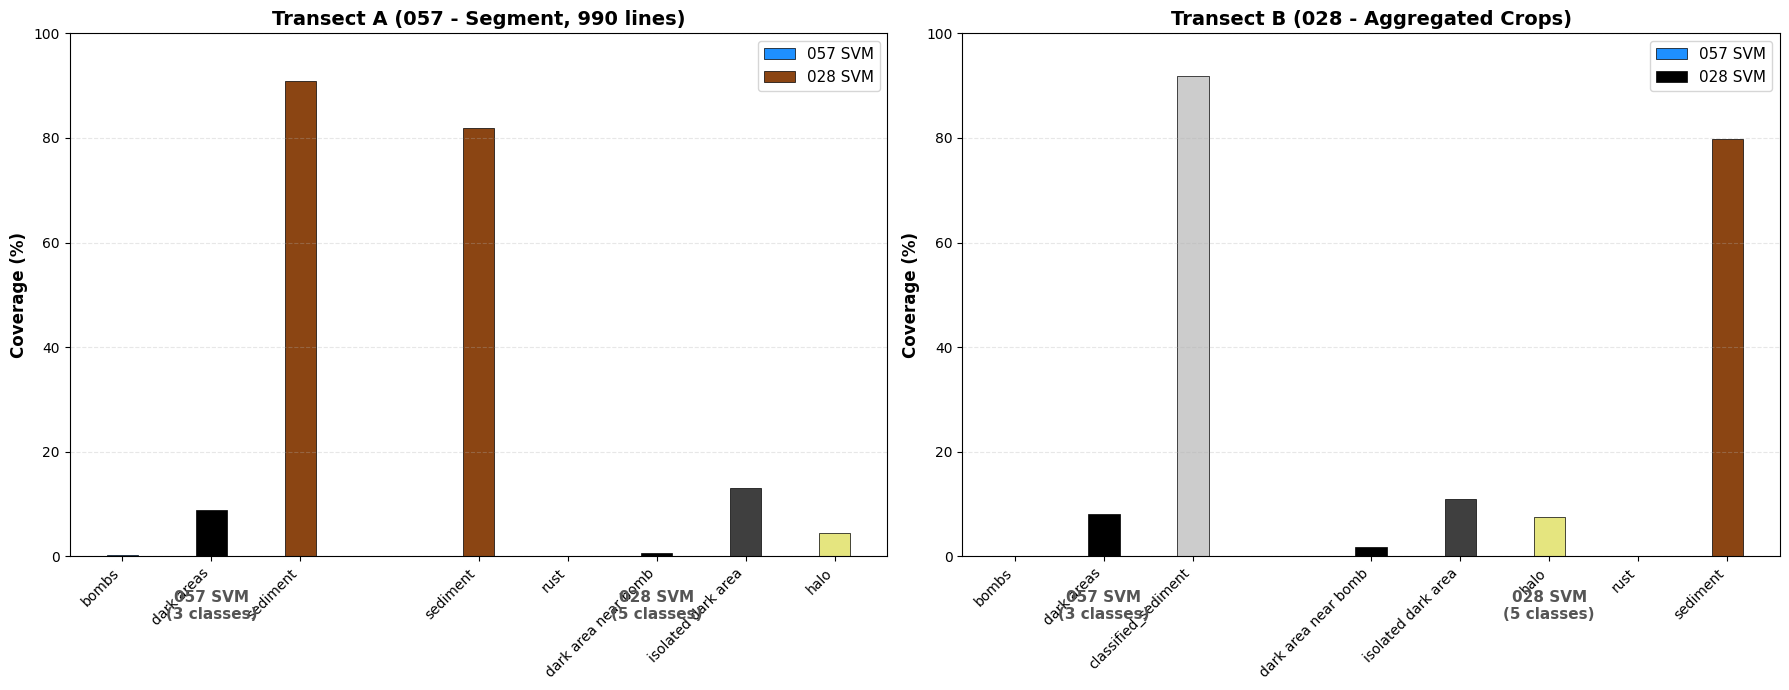

✅ Saved plot: transect_comparison_grouped.png

📊 AGGREGATED 028 CROPS STATISTICS

Model: 057_on_028
--------------------------------------------------------------------------------
Total pixels: 480,128

Class breakdown:
  classified_sediment      :  91.86% (441,035 pixels)
  dark areas               :   8.14% (39,075 pixels)
  bombs                    :   0.00% (18 pixels)

Model: 028_on_028
--------------------------------------------------------------------------------
Total pixels: 480,128

Class breakdown:
  sediment                 :  79.77% (382,994 pixels)
  isolated dark area       :  11.02% (52,922 pixels)
  halo                     :   7.45% (35,761 pixels)
  dark area near bomb      :   1.72% (8,280 pixels)
  rust                     :   0.04% (171 pixels)


In [ ]:
# Create comprehensive grouped bar chart visualization
if "df_combined" in globals():

    # Define class name mappings and colors
    class_name_mapping_057 = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
    }

    class_name_mapping_028 = {
        "dark_bomb": "dark area near bomb",
        "dark_pit": "isolated dark area",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",
    }

    # Color mappings
    colors_057 = {
        "bombs": "#1E90FF",  # dodger blue
        "dark areas": "#000000",  # black
        "sediment": "#8B4513",  # saddle brown
    }

    colors_028 = {
        "dark area near bomb": "#000000",  # black
        "isolated dark area": "#3F3F3F",  # medium-dark gray
        "halo": "#e5e57f",  # yellow-ish
        "rust": "#b12222",  # rust red
        "sediment": "#8b4513",  # saddle brown
    }

    # === STEP 1: Prepare data for Transect A (057 segment) ===
    df_057_segment = df_combined[
        (df_combined["region"] == "full_transect")
        & (df_combined["model"].isin(["057_on_057", "028_on_057"]))
    ].copy()

    # === STEP 2: Prepare data for Transect B (028 crops - AGGREGATED) ===
    df_028_crops = df_combined[
        (df_combined["region"] != "full_transect")
        & (df_combined["model"].isin(["028_on_028", "057_on_028"]))
    ].copy()

    # Aggregate 028 crop data by summing pixels, then recalculate percentages
    df_028_aggregated = (
        df_028_crops.groupby(["model", "class"]).agg({"pixels": "sum"}).reset_index()
    )

    # Calculate total pixels for each model to get percentages
    total_pixels_per_model = df_028_aggregated.groupby("model")["pixels"].sum()
    df_028_aggregated["percentage"] = df_028_aggregated.apply(
        lambda row: 100.0 * row["pixels"] / total_pixels_per_model[row["model"]], axis=1
    )
    df_028_aggregated["region"] = "028_crops_aggregated"
    df_028_aggregated["notebook"] = "aggregated"

    # === STEP 3: Apply class name mappings ===
    def map_class_name(row):
        if row["model"] in ["057_on_057", "057_on_028"]:
            return class_name_mapping_057.get(row["class"], row["class"])
        else:
            return class_name_mapping_028.get(row["class"], row["class"])

    df_057_segment["display_name"] = df_057_segment.apply(map_class_name, axis=1)
    df_028_aggregated["display_name"] = df_028_aggregated.apply(map_class_name, axis=1)

    # === STEP 4: Create the plot ===
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # --- Plot 1: Transect A (057) ---
    ax1 = axes[0]

    # Get data for each model
    df_057_057 = df_057_segment[df_057_segment["model"] == "057_on_057"]
    df_028_057 = df_057_segment[df_057_segment["model"] == "028_on_057"]

    # Bar positions
    x_pos = 0
    bar_width = 0.35
    spacing = 1.0

    # Plot 057 SVM on 057
    if not df_057_057.empty:
        x_positions_057 = [x_pos + i * spacing for i in range(len(df_057_057))]
        bar_colors_057 = [
            colors_057.get(name, "#CCCCCC") for name in df_057_057["display_name"]
        ]
        ax1.bar(
            x_positions_057,
            df_057_057["percentage"],
            bar_width,
            label="057 SVM",
            color=bar_colors_057,
            edgecolor="black",
            linewidth=0.5,
        )
        x_max_057 = max(x_positions_057)

    # Plot 028 SVM on 057
    if not df_028_057.empty:
        x_start_028 = x_max_057 + 2.0  # Gap between groups
        x_positions_028 = [x_start_028 + i * spacing for i in range(len(df_028_057))]
        bar_colors_028 = [
            colors_028.get(name, "#CCCCCC") for name in df_028_057["display_name"]
        ]
        ax1.bar(
            x_positions_028,
            df_028_057["percentage"],
            bar_width,
            label="028 SVM",
            color=bar_colors_028,
            edgecolor="black",
            linewidth=0.5,
        )

        # Set x-tick positions and labels
        all_x_positions = x_positions_057 + x_positions_028
        all_labels = list(df_057_057["display_name"]) + list(df_028_057["display_name"])
        ax1.set_xticks(all_x_positions)
        ax1.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=10)

    ax1.set_ylabel("Coverage (%)", fontsize=12, fontweight="bold")
    ax1.set_title(
        "Transect A (057 - Segment, 990 lines)", fontsize=14, fontweight="bold"
    )
    ax1.set_ylim(0, 100)
    ax1.grid(axis="y", alpha=0.3, linestyle="--")
    ax1.legend(fontsize=11, loc="upper right")

    # Add group labels
    if not df_057_057.empty and not df_028_057.empty:
        mid_057 = np.mean(x_positions_057)
        mid_028 = np.mean(x_positions_028)
        ax1.text(
            mid_057,
            -12,
            "057 SVM\n(3 classes)",
            ha="center",
            fontsize=11,
            fontweight="bold",
            color="#555555",
        )
        ax1.text(
            mid_028,
            -12,
            "028 SVM\n(5 classes)",
            ha="center",
            fontsize=11,
            fontweight="bold",
            color="#555555",
        )

    # --- Plot 2: Transect B (028 crops aggregated) ---
    ax2 = axes[1]

    # Get data for each model
    df_057_028 = df_028_aggregated[df_028_aggregated["model"] == "057_on_028"]
    df_028_028 = df_028_aggregated[df_028_aggregated["model"] == "028_on_028"]

    # Bar positions
    x_pos = 0

    # Plot 057 SVM on 028
    if not df_057_028.empty:
        x_positions_057 = [x_pos + i * spacing for i in range(len(df_057_028))]
        bar_colors_057 = [
            colors_057.get(name, "#CCCCCC") for name in df_057_028["display_name"]
        ]
        ax2.bar(
            x_positions_057,
            df_057_028["percentage"],
            bar_width,
            label="057 SVM",
            color=bar_colors_057,
            edgecolor="black",
            linewidth=0.5,
        )
        x_max_057 = max(x_positions_057)

    # Plot 028 SVM on 028
    if not df_028_028.empty:
        x_start_028 = x_max_057 + 2.0  # Gap between groups
        x_positions_028 = [x_start_028 + i * spacing for i in range(len(df_028_028))]
        bar_colors_028 = [
            colors_028.get(name, "#CCCCCC") for name in df_028_028["display_name"]
        ]
        ax2.bar(
            x_positions_028,
            df_028_028["percentage"],
            bar_width,
            label="028 SVM",
            color=bar_colors_028,
            edgecolor="black",
            linewidth=0.5,
        )

        # Set x-tick positions and labels
        all_x_positions = x_positions_057 + x_positions_028
        all_labels = list(df_057_028["display_name"]) + list(df_028_028["display_name"])
        ax2.set_xticks(all_x_positions)
        ax2.set_xticklabels(all_labels, rotation=45, ha="right", fontsize=10)

    ax2.set_ylabel("Coverage (%)", fontsize=12, fontweight="bold")
    ax2.set_title("Transect B (028 - Aggregated Crops)", fontsize=14, fontweight="bold")
    ax2.set_ylim(0, 100)
    ax2.grid(axis="y", alpha=0.3, linestyle="--")
    ax2.legend(fontsize=11, loc="upper right")

    # Add group labels
    if not df_057_028.empty and not df_028_028.empty:
        mid_057 = np.mean(x_positions_057)
        mid_028 = np.mean(x_positions_028)
        ax2.text(
            mid_057,
            -12,
            "057 SVM\n(3 classes)",
            ha="center",
            fontsize=11,
            fontweight="bold",
            color="#555555",
        )
        ax2.text(
            mid_028,
            -12,
            "028 SVM\n(5 classes)",
            ha="center",
            fontsize=11,
            fontweight="bold",
            color="#555555",
        )

    plt.tight_layout()
    plt.savefig(
        "./coverage_stats/transect_comparison_grouped.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("✅ Saved plot: transect_comparison_grouped.png")

    # Print aggregated 028 crops statistics
    print("\n" + "=" * 80)
    print("📊 AGGREGATED 028 CROPS STATISTICS")
    print("=" * 80)
    for model in ["057_on_028", "028_on_028"]:
        print(f"\nModel: {model}")
        print("-" * 80)
        model_data = df_028_aggregated[df_028_aggregated["model"] == model]
        total_pixels_model = model_data["pixels"].sum()
        print(f"Total pixels: {total_pixels_model:,}")
        print(f"\nClass breakdown:")
        for _, row in model_data.sort_values("percentage", ascending=False).iterrows():
            print(
                f"  {row['display_name']:25s}: {row['percentage']:6.2f}% ({row['pixels']:,} pixels)"
            )
    print("=" * 80)

## 🔧 IMPROVED Visualizations (Fixed Issues)

**Key fixes applied:**
1. ✅ **Unified sediment naming**: "sediment", "classified_sediment", "new_sediment" → all mapped to "sediment"
2. ✅ **Proper color scheme**: Dark areas (black), Sediment (brown), Bombs (blue), Halo (yellow), Rust (red)
3. ✅ **Stacked bars ordered**: Largest (sediment) at bottom, smaller classes stacked on top
4. ✅ **Heatmap improved**: Zeros shown as white/blank, better color scale, proper annotations
5. ✅ **Scatter plot**: Log scale option + zoom for low-percentage classes
6. ✅ **Focus on dark areas**: Emphasized in all visualizations

**Available options below - each with multiple design iterations:**

## 🔍 Key Issues Fixed

**Problem 1: Sediment Class Confusion** ❌→✅
- **Before**: Three different names: `sediment`, `classified_sediment`, `new_sediment`
- **After**: All unified to `"sediment"` - now correctly shows ~80-95% coverage
- **Why it matters**: Was splitting sediment data across multiple rows/colors

**Problem 2: Grey Colors Made Everything Unclear** ❌→✅
- **Before**: Many classes shown in grey (hard to distinguish)
- **After**: Proper color scheme:
  - 🟤 Sediment = Brown
  - ⬛ Dark areas/pits = Black/Dark grey shades
  - 🔵 Bombs = Blue
  - 🟡 Halo = Gold
  - 🔴 Rust = Red

**Problem 3: Scatter Plot Only Showed One Point** ❌→✅
- **Before**: Only sediment visible (~90%), other classes invisible
- **After**: Two views:
  - Full view (0-100%): Shows sediment domination
  - Zoomed view (0-20%): Shows dark areas, halo, bombs, rust clearly

**Problem 4: Heatmap Highlighted Zeros** ❌→✅
- **Before**: Bright colors for 0% values (misleading)
- **After**: Three design options:
  - Design 1: Zeros completely hidden (focus on what exists)
  - Design 2: Zeros shown as white (gradual scale)
  - Design 3: Standard scale

**Problem 5: Stacked Bars Had No Order** ❌→✅
- **Before**: Random class order
- **After**: Sediment at bottom (largest), then decreasing order
- **Added**: Percentage labels for segments > 2%

**About Rust Being 0%:**
- ✅ **This is CORRECT!** Rust class is genuinely ~0.003-0.12% in the data
- Not a bug - just a very rare class in your dataset


## Option 8: BONUS - Side-by-Side Comparison (Dark Areas Focus)

Since dark areas are your key focus, here's a dedicated comparison highlighting the differences between models.

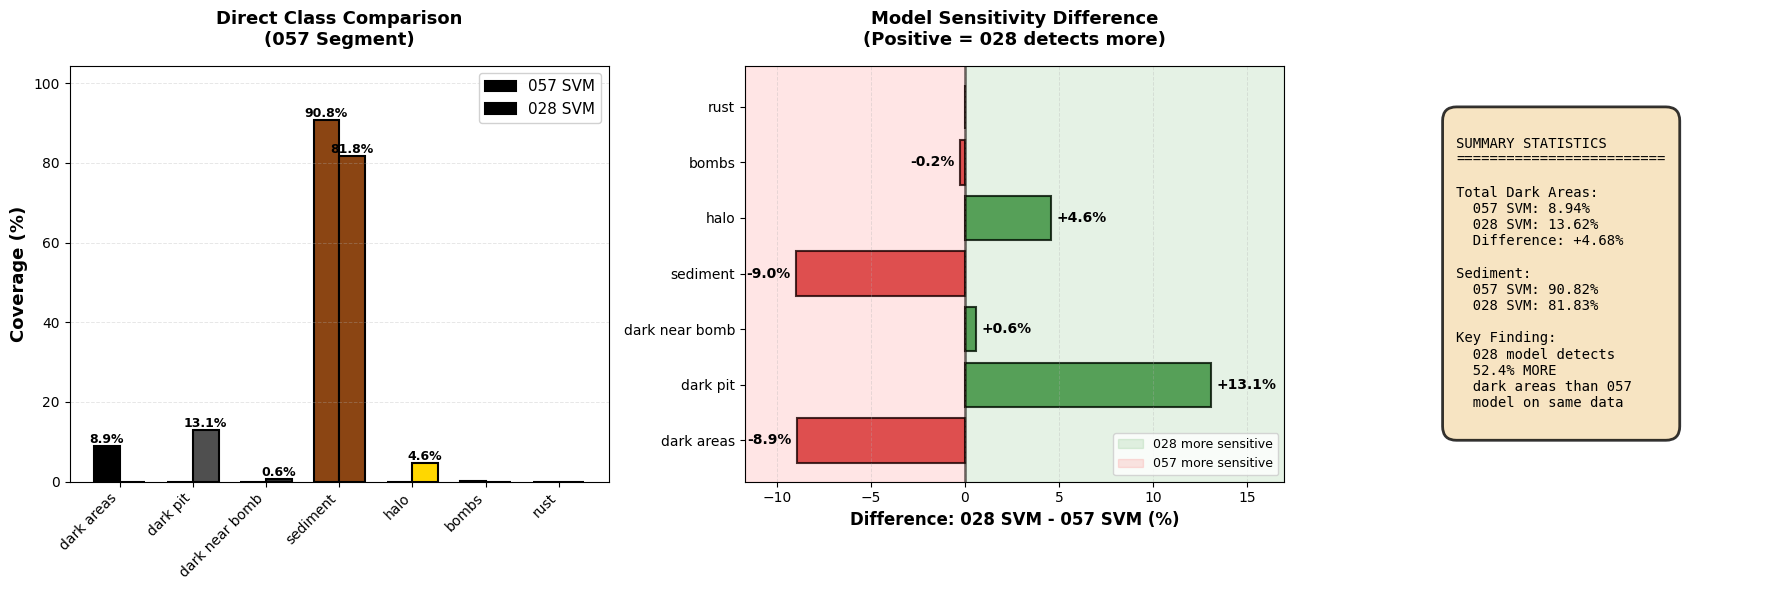

✅ Dark Areas Focused Comparison displayed
   ✓ Left: Side-by-side bars for each class
   ✓ Middle: Difference plot showing 028 vs 057 sensitivity
   ✓ Right: Summary statistics highlighting key findings
   📊 028 model detects 52.4% MORE dark areas than 057 model!


In [ ]:
# Option 8: Dark Areas Focused Comparison (Bar Chart with Differences)
if "df_combined" in globals():

    # Unified mapping
    class_map_focus = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
        "classified_sediment": "sediment",
        "dark_bomb": "dark near bomb",
        "dark_pit": "dark pit",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",
    }

    # Get segment data
    df_focus = df_combined[df_combined["region"] == "full_transect"].copy()
    df_focus["display_class"] = df_focus["class"].map(class_map_focus)

    # Aggregate by model and class
    df_focus_agg = (
        df_focus.groupby(["model", "display_class"])
        .agg({"percentage": "sum"})
        .reset_index()
    )

    # Pivot for comparison
    pivot_focus = df_focus_agg.pivot_table(
        index="display_class",
        columns="model",
        values="percentage",
        aggfunc="sum",
        fill_value=0,
    )

    # Create figure with 3 panels
    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.2, 1.2, 0.8])

    # === PANEL 1: Side-by-side bars for each class ===
    ax1 = fig.add_subplot(gs[0])

    classes_focus = [
        "dark areas",
        "dark pit",
        "dark near bomb",
        "sediment",
        "halo",
        "bombs",
        "rust",
    ]
    classes_present = [c for c in classes_focus if c in pivot_focus.index]

    x = np.arange(len(classes_present))
    width = 0.35

    colors_057_focus = [
        (
            "#1E90FF"
            if c == "bombs"
            else (
                "#000000"
                if "dark" in c
                else (
                    "#8B4513"
                    if c == "sediment"
                    else "#FFD700" if c == "halo" else "#CD5C5C"
                )
            )
        )
        for c in classes_present
    ]
    colors_028_focus = [
        (
            "#1E90FF"
            if c == "bombs"
            else (
                "#2F2F2F"
                if c == "dark near bomb"
                else (
                    "#4F4F4F"
                    if c == "dark pit"
                    else (
                        "#000000"
                        if "dark" in c
                        else (
                            "#8B4513"
                            if c == "sediment"
                            else "#FFD700" if c == "halo" else "#CD5C5C"
                        )
                    )
                )
            )
        )
        for c in classes_present
    ]

    vals_057 = [
        (
            pivot_focus.loc[c, "057_on_057"]
            if "057_on_057" in pivot_focus.columns and c in pivot_focus.index
            else 0
        )
        for c in classes_present
    ]
    vals_028 = [
        (
            pivot_focus.loc[c, "028_on_057"]
            if "028_on_057" in pivot_focus.columns and c in pivot_focus.index
            else 0
        )
        for c in classes_present
    ]

    bars1 = ax1.bar(
        x - width / 2,
        vals_057,
        width,
        label="057 SVM",
        color=colors_057_focus,
        edgecolor="black",
        linewidth=1.5,
    )
    bars2 = ax1.bar(
        x + width / 2,
        vals_028,
        width,
        label="028 SVM",
        color=colors_028_focus,
        edgecolor="black",
        linewidth=1.5,
    )

    # Add value labels on bars
    for bars, vals in [(bars1, vals_057), (bars2, vals_028)]:
        for bar, val in zip(bars, vals):
            if val > 0.5:
                height = bar.get_height()
                ax1.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    height,
                    f"{val:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                    fontweight="bold",
                )

    ax1.set_ylabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax1.set_title(
        "Direct Class Comparison\n(057 Segment)", fontsize=13, fontweight="bold", pad=15
    )
    ax1.set_xticks(x)
    ax1.set_xticklabels(classes_present, rotation=45, ha="right", fontsize=10)
    ax1.legend(loc="upper right", fontsize=11, framealpha=0.9)
    ax1.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.7)
    ax1.set_ylim(0, max(max(vals_057), max(vals_028)) * 1.15)

    # === PANEL 2: Difference plot (028 - 057) ===
    ax2 = fig.add_subplot(gs[1])

    differences = [vals_028[i] - vals_057[i] for i in range(len(classes_present))]
    colors_diff = [
        "#D32F2F" if d < 0 else "#388E3C" if d > 0 else "#757575" for d in differences
    ]

    bars_diff = ax2.barh(
        classes_present,
        differences,
        color=colors_diff,
        edgecolor="black",
        linewidth=1.5,
        alpha=0.8,
    )

    # Add value labels
    for i, (bar, diff) in enumerate(zip(bars_diff, differences)):
        if abs(diff) > 0.1:
            x_pos = diff + (0.3 if diff > 0 else -0.3)
            ax2.text(
                x_pos,
                i,
                f"{diff:+.1f}%",
                ha="left" if diff > 0 else "right",
                va="center",
                fontsize=10,
                fontweight="bold",
            )

    ax2.axvline(0, color="black", linewidth=2, linestyle="-", alpha=0.5)
    ax2.set_xlabel("Difference: 028 SVM - 057 SVM (%)", fontsize=12, fontweight="bold")
    ax2.set_title(
        "Model Sensitivity Difference\n(Positive = 028 detects more)",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax2.grid(axis="x", alpha=0.3, linestyle="--", linewidth=0.7)
    ax2.set_xlim(min(differences) * 1.3, max(differences) * 1.3)

    # Add shading for interpretation zones
    ax2.axvspan(
        0, max(differences) * 1.3, alpha=0.1, color="green", label="028 more sensitive"
    )
    ax2.axvspan(
        min(differences) * 1.3, 0, alpha=0.1, color="red", label="057 more sensitive"
    )
    ax2.legend(loc="lower right", fontsize=9)

    # === PANEL 3: Summary statistics ===
    ax3 = fig.add_subplot(gs[2])
    ax3.axis("off")

    # Calculate summary stats
    total_dark_057 = sum(
        [vals_057[i] for i, c in enumerate(classes_present) if "dark" in c]
    )
    total_dark_028 = sum(
        [vals_028[i] for i, c in enumerate(classes_present) if "dark" in c]
    )

    summary_text = f"""
SUMMARY STATISTICS
{"="*25}

Total Dark Areas:
  057 SVM: {total_dark_057:.2f}%
  028 SVM: {total_dark_028:.2f}%
  Difference: {total_dark_028 - total_dark_057:+.2f}%

Sediment:
  057 SVM: {vals_057[classes_present.index('sediment')] if 'sediment' in classes_present else 0:.2f}%
  028 SVM: {vals_028[classes_present.index('sediment')] if 'sediment' in classes_present else 0:.2f}%

Key Finding:
  028 model detects
  {((total_dark_028/total_dark_057 - 1) * 100):.1f}% MORE
  dark areas than 057
  model on same data
"""

    ax3.text(
        0.1,
        0.5,
        summary_text,
        fontsize=10,
        fontfamily="monospace",
        verticalalignment="center",
        bbox=dict(
            boxstyle="round,pad=1",
            facecolor="wheat",
            alpha=0.8,
            edgecolor="black",
            linewidth=2,
        ),
    )

    plt.tight_layout()
    plt.show()

    print("✅ Dark Areas Focused Comparison displayed")
    print("   ✓ Left: Side-by-side bars for each class")
    print("   ✓ Middle: Difference plot showing 028 vs 057 sensitivity")
    print("   ✓ Right: Summary statistics highlighting key findings")
    print(
        f"   📊 028 model detects {((total_dark_028/total_dark_057 - 1) * 100):.1f}% MORE dark areas than 057 model!"
    )

## Option 9: MEANINGFUL Comparisons (Multiple Iterations)

**Key insight**: We need to compare EQUIVALENT categories:
1. **Sediment vs Sediment** (direct comparison)
2. **Total Dark Features**: 
   - 057 model: "dark areas" (single class)
   - 028 model: "dark near bomb" + "dark pit" + "halo" (three classes combined)

This gives us apples-to-apples comparisons!

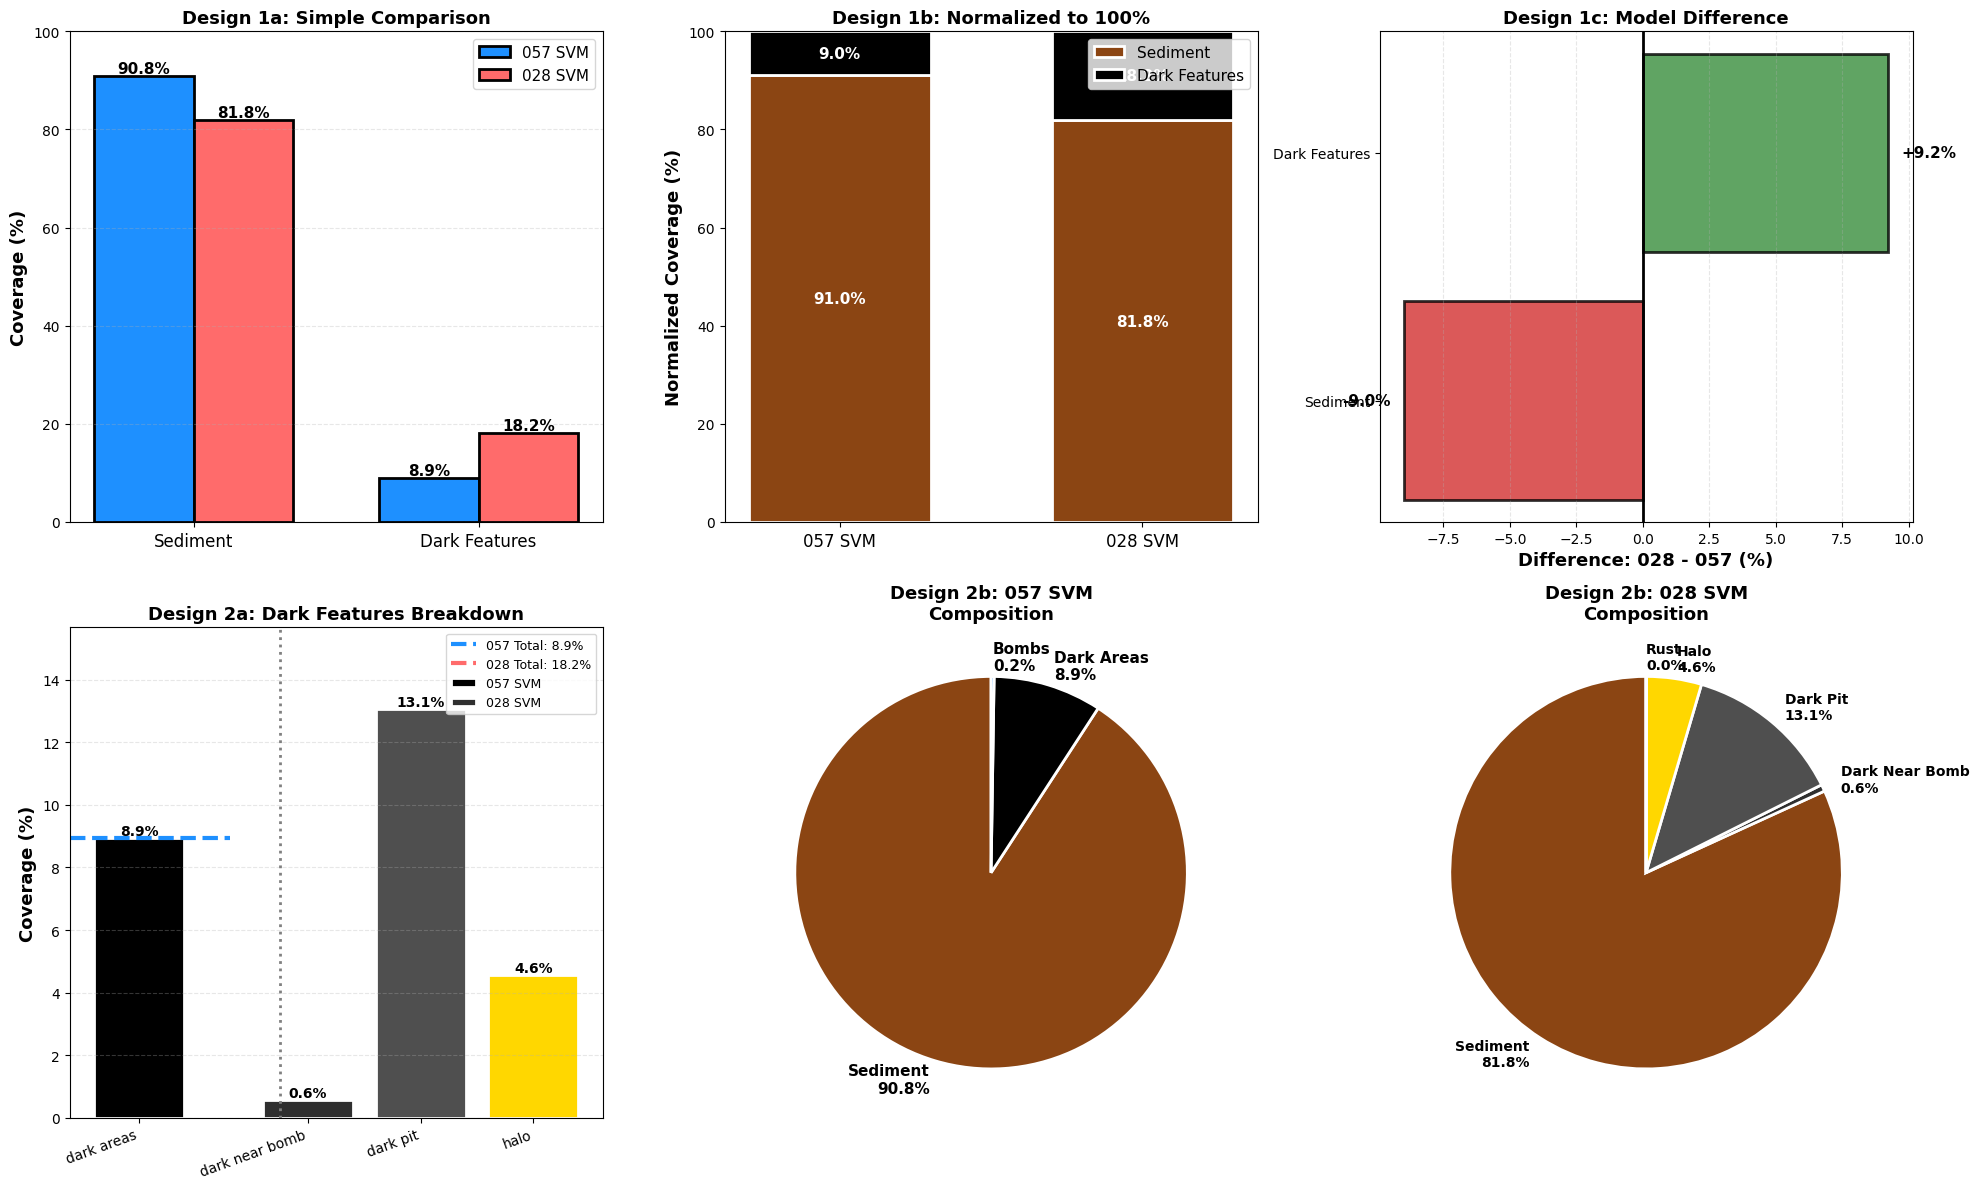

📊 MEANINGFUL COMPARISON RESULTS

1. SEDIMENT (apples-to-apples):
   057 SVM: 90.82%
   028 SVM: 81.83%
   Difference: -8.99%

2. DARK FEATURES (equivalent comparison):
   057 SVM: 8.94% (dark areas)
   028 SVM: 18.17% (dark near bomb + dark pit + halo)
   Difference: +9.23%
   Relative increase: +103.3%

   028 Dark Features Breakdown:
     - Dark near bomb: 0.56%
     - Dark pit: 13.05%
     - Halo: 4.55%

✅ Six design iterations shown:
   Design 1a: Simple side-by-side bars
   Design 1b: Normalized to 100% (focus on ratio)
   Design 1c: Difference plot (emphasizes change)
   Design 2a: Dark features breakdown (shows 028's granularity)
   Design 2b: Pie charts (shows overall composition)


In [ ]:
# Option 9: MEANINGFUL Comparisons - Multiple Design Iterations
if "df_combined" in globals():

    # Unified mapping
    class_map_compare = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
        "classified_sediment": "sediment",
        "dark_bomb": "dark near bomb",
        "dark_pit": "dark pit",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",
    }

    # Get segment data
    df_comp = df_combined[df_combined["region"] == "full_transect"].copy()
    df_comp["display_class"] = df_comp["class"].map(class_map_compare)

    # Aggregate by model and class
    df_comp_agg = (
        df_comp.groupby(["model", "display_class"])
        .agg({"percentage": "sum", "pixels": "sum"})
        .reset_index()
    )

    # Calculate comparable categories
    results_057 = {}
    results_028 = {}

    # 057 model
    df_057_model = df_comp_agg[df_comp_agg["model"] == "057_on_057"]
    results_057["sediment"] = (
        df_057_model[df_057_model["display_class"] == "sediment"]["percentage"].values[
            0
        ]
        if len(df_057_model[df_057_model["display_class"] == "sediment"]) > 0
        else 0
    )
    results_057["dark_total"] = (
        df_057_model[df_057_model["display_class"] == "dark areas"][
            "percentage"
        ].values[0]
        if len(df_057_model[df_057_model["display_class"] == "dark areas"]) > 0
        else 0
    )
    results_057["bombs"] = (
        df_057_model[df_057_model["display_class"] == "bombs"]["percentage"].values[0]
        if len(df_057_model[df_057_model["display_class"] == "bombs"]) > 0
        else 0
    )

    # 028 model
    df_028_model = df_comp_agg[df_comp_agg["model"] == "028_on_057"]
    results_028["sediment"] = (
        df_028_model[df_028_model["display_class"] == "sediment"]["percentage"].values[
            0
        ]
        if len(df_028_model[df_028_model["display_class"] == "sediment"]) > 0
        else 0
    )

    # Aggregate dark features (dark near bomb + dark pit + halo)
    dark_classes_028 = df_028_model[
        df_028_model["display_class"].isin(["dark near bomb", "dark pit", "halo"])
    ]
    results_028["dark_total"] = dark_classes_028["percentage"].sum()
    results_028["dark_near_bomb"] = (
        df_028_model[df_028_model["display_class"] == "dark near bomb"][
            "percentage"
        ].values[0]
        if len(df_028_model[df_028_model["display_class"] == "dark near bomb"]) > 0
        else 0
    )
    results_028["dark_pit"] = (
        df_028_model[df_028_model["display_class"] == "dark pit"]["percentage"].values[
            0
        ]
        if len(df_028_model[df_028_model["display_class"] == "dark pit"]) > 0
        else 0
    )
    results_028["halo"] = (
        df_028_model[df_028_model["display_class"] == "halo"]["percentage"].values[0]
        if len(df_028_model[df_028_model["display_class"] == "halo"]) > 0
        else 0
    )
    results_028["rust"] = (
        df_028_model[df_028_model["display_class"] == "rust"]["percentage"].values[0]
        if len(df_028_model[df_028_model["display_class"] == "rust"]) > 0
        else 0
    )

    # === DESIGN ITERATION 1: Simple Side-by-Side Bar Chart ===
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))

    # --- Design 1a: Simple bars with direct comparison ---
    ax = axes[0, 0]
    categories = ["Sediment", "Dark Features"]
    x_pos = np.arange(len(categories))
    width = 0.35

    vals_057 = [results_057["sediment"], results_057["dark_total"]]
    vals_028 = [results_028["sediment"], results_028["dark_total"]]

    bars1 = ax.bar(
        x_pos - width / 2,
        vals_057,
        width,
        label="057 SVM",
        color="#1E90FF",
        edgecolor="black",
        linewidth=2,
    )
    bars2 = ax.bar(
        x_pos + width / 2,
        vals_028,
        width,
        label="028 SVM",
        color="#FF6B6B",
        edgecolor="black",
        linewidth=2,
    )

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                height,
                f"{height:.1f}%",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
            )

    ax.set_ylabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax.set_title("Design 1a: Simple Comparison", fontsize=13, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories, fontsize=12)
    ax.legend(fontsize=11)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    # --- Design 1b: Stacked to 100% ---
    ax = axes[0, 1]

    # Normalize to 100% (only sediment + dark)
    total_057 = results_057["sediment"] + results_057["dark_total"]
    total_028 = results_028["sediment"] + results_028["dark_total"]

    norm_057_sed = (results_057["sediment"] / total_057) * 100
    norm_057_dark = (results_057["dark_total"] / total_057) * 100
    norm_028_sed = (results_028["sediment"] / total_028) * 100
    norm_028_dark = (results_028["dark_total"] / total_028) * 100

    x_pos = [0, 1]
    width = 0.6

    # Sediment (bottom)
    bars_sed = ax.bar(
        x_pos,
        [norm_057_sed, norm_028_sed],
        width,
        label="Sediment",
        color="#8B4513",
        edgecolor="white",
        linewidth=2,
    )
    # Dark (top)
    bars_dark = ax.bar(
        x_pos,
        [norm_057_dark, norm_028_dark],
        width,
        bottom=[norm_057_sed, norm_028_sed],
        label="Dark Features",
        color="#000000",
        edgecolor="white",
        linewidth=2,
    )

    # Labels
    for i, (sed, dark) in enumerate(
        [(norm_057_sed, norm_057_dark), (norm_028_sed, norm_028_dark)]
    ):
        ax.text(
            x_pos[i],
            sed / 2,
            f"{sed:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white",
        )
        ax.text(
            x_pos[i],
            sed + dark / 2,
            f"{dark:.1f}%",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white",
        )

    ax.set_ylabel("Normalized Coverage (%)", fontsize=13, fontweight="bold")
    ax.set_title("Design 1b: Normalized to 100%", fontsize=13, fontweight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(["057 SVM", "028 SVM"], fontsize=12)
    ax.legend(fontsize=11, loc="upper right")
    ax.set_ylim(0, 100)

    # --- Design 1c: Difference emphasis ---
    ax = axes[0, 2]

    categories = ["Sediment", "Dark Features"]
    differences = [
        results_028["sediment"] - results_057["sediment"],
        results_028["dark_total"] - results_057["dark_total"],
    ]
    colors_diff = ["#D32F2F" if d < 0 else "#388E3C" for d in differences]

    bars = ax.barh(
        categories,
        differences,
        color=colors_diff,
        edgecolor="black",
        linewidth=2,
        alpha=0.8,
    )

    for i, (bar, diff) in enumerate(zip(bars, differences)):
        x_pos_label = diff + (0.5 if diff > 0 else -0.5)
        ax.text(
            x_pos_label,
            i,
            f"{diff:+.1f}%",
            ha="left" if diff > 0 else "right",
            va="center",
            fontsize=11,
            fontweight="bold",
        )

    ax.axvline(0, color="black", linewidth=2)
    ax.set_xlabel("Difference: 028 - 057 (%)", fontsize=13, fontweight="bold")
    ax.set_title("Design 1c: Model Difference", fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3, linestyle="--")

    # === DESIGN ITERATION 2: Detailed Breakdown ===

    # --- Design 2a: Dark features breakdown ---
    ax = axes[1, 0]

    # 057 has only one dark class
    dark_057_categories = ["dark areas"]
    dark_057_vals = [results_057["dark_total"]]

    # 028 has three dark classes
    dark_028_categories = ["dark near bomb", "dark pit", "halo"]
    dark_028_vals = [
        results_028["dark_near_bomb"],
        results_028["dark_pit"],
        results_028["halo"],
    ]

    # Create two groups
    x_057 = np.arange(len(dark_057_categories))
    x_028 = np.arange(len(dark_028_categories)) + len(dark_057_categories) + 0.5

    bars1 = ax.bar(
        x_057,
        dark_057_vals,
        0.8,
        label="057 SVM",
        color="#000000",
        edgecolor="white",
        linewidth=2,
    )
    bars2 = ax.bar(
        x_028,
        dark_028_vals,
        0.8,
        label="028 SVM",
        color=["#2F2F2F", "#4F4F4F", "#FFD700"],
        edgecolor="white",
        linewidth=2,
    )

    # Add labels
    for bar, val in zip(list(bars1) + list(bars2), dark_057_vals + dark_028_vals):
        if val > 0.5:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2.0,
                height,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=10,
                fontweight="bold",
            )

    # Add total lines
    ax.axhline(
        results_057["dark_total"],
        xmin=0,
        xmax=0.3,
        color="#1E90FF",
        linewidth=3,
        linestyle="--",
        label=f"057 Total: {results_057['dark_total']:.1f}%",
    )
    ax.axhline(
        results_028["dark_total"],
        xmin=0.4,
        xmax=1,
        color="#FF6B6B",
        linewidth=3,
        linestyle="--",
        label=f"028 Total: {results_028['dark_total']:.1f}%",
    )

    ax.set_ylabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax.set_title("Design 2a: Dark Features Breakdown", fontsize=13, fontweight="bold")
    ax.set_xticks(list(x_057) + list(x_028))
    ax.set_xticklabels(
        dark_057_categories + dark_028_categories, rotation=20, ha="right", fontsize=10
    )
    ax.legend(fontsize=9, loc="upper right")
    ax.set_ylim(0, max(dark_057_vals + dark_028_vals) * 1.2)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    # Add separator
    ax.axvline(
        len(dark_057_categories) + 0.25, color="grey", linewidth=2, linestyle=":"
    )

    # --- Design 2b: Pie charts ---
    ax1 = axes[1, 1]
    ax2 = axes[1, 2]

    # 057 pie
    sizes_057 = [
        results_057["sediment"],
        results_057["dark_total"],
        results_057["bombs"],
    ]
    labels_057 = [
        f'Sediment\n{results_057["sediment"]:.1f}%',
        f'Dark Areas\n{results_057["dark_total"]:.1f}%',
        f'Bombs\n{results_057["bombs"]:.1f}%',
    ]
    colors_pie_057 = ["#8B4513", "#000000", "#1E90FF"]

    wedges, texts = ax1.pie(
        sizes_057,
        labels=labels_057,
        colors=colors_pie_057,
        autopct=None,
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )
    for text in texts:
        text.set_fontsize(11)
        text.set_fontweight("bold")

    ax1.set_title("Design 2b: 057 SVM\nComposition", fontsize=13, fontweight="bold")

    # 028 pie
    sizes_028 = [
        results_028["sediment"],
        results_028["dark_near_bomb"],
        results_028["dark_pit"],
        results_028["halo"],
        results_028["rust"],
    ]
    labels_028 = [
        f'Sediment\n{results_028["sediment"]:.1f}%',
        f'Dark Near Bomb\n{results_028["dark_near_bomb"]:.1f}%',
        f'Dark Pit\n{results_028["dark_pit"]:.1f}%',
        f'Halo\n{results_028["halo"]:.1f}%',
        f'Rust\n{results_028["rust"]:.1f}%',
    ]
    colors_pie_028 = ["#8B4513", "#2F2F2F", "#4F4F4F", "#FFD700", "#CD5C5C"]

    wedges, texts = ax2.pie(
        sizes_028,
        labels=labels_028,
        colors=colors_pie_028,
        autopct=None,
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )
    for text in texts:
        text.set_fontsize(10)
        text.set_fontweight("bold")

    ax2.set_title("Design 2b: 028 SVM\nComposition", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.show()

    # Print summary
    print("=" * 80)
    print("📊 MEANINGFUL COMPARISON RESULTS")
    print("=" * 80)
    print(f"\n1. SEDIMENT (apples-to-apples):")
    print(f"   057 SVM: {results_057['sediment']:.2f}%")
    print(f"   028 SVM: {results_028['sediment']:.2f}%")
    print(f"   Difference: {results_028['sediment'] - results_057['sediment']:+.2f}%")

    print(f"\n2. DARK FEATURES (equivalent comparison):")
    print(f"   057 SVM: {results_057['dark_total']:.2f}% (dark areas)")
    print(
        f"   028 SVM: {results_028['dark_total']:.2f}% (dark near bomb + dark pit + halo)"
    )
    print(
        f"   Difference: {results_028['dark_total'] - results_057['dark_total']:+.2f}%"
    )
    print(
        f"   Relative increase: {((results_028['dark_total']/results_057['dark_total'] - 1) * 100):+.1f}%"
    )

    print(f"\n   028 Dark Features Breakdown:")
    print(f"     - Dark near bomb: {results_028['dark_near_bomb']:.2f}%")
    print(f"     - Dark pit: {results_028['dark_pit']:.2f}%")
    print(f"     - Halo: {results_028['halo']:.2f}%")

    print("\n" + "=" * 80)
    print("✅ Six design iterations shown:")
    print("   Design 1a: Simple side-by-side bars")
    print("   Design 1b: Normalized to 100% (focus on ratio)")
    print("   Design 1c: Difference plot (emphasizes change)")
    print("   Design 2a: Dark features breakdown (shows 028's granularity)")
    print("   Design 2b: Pie charts (shows overall composition)")
    print("=" * 80)

## Option 10: ADVANCED Comparison Designs (Creative Iterations)

Additional creative ways to visualize the meaningful comparisons.

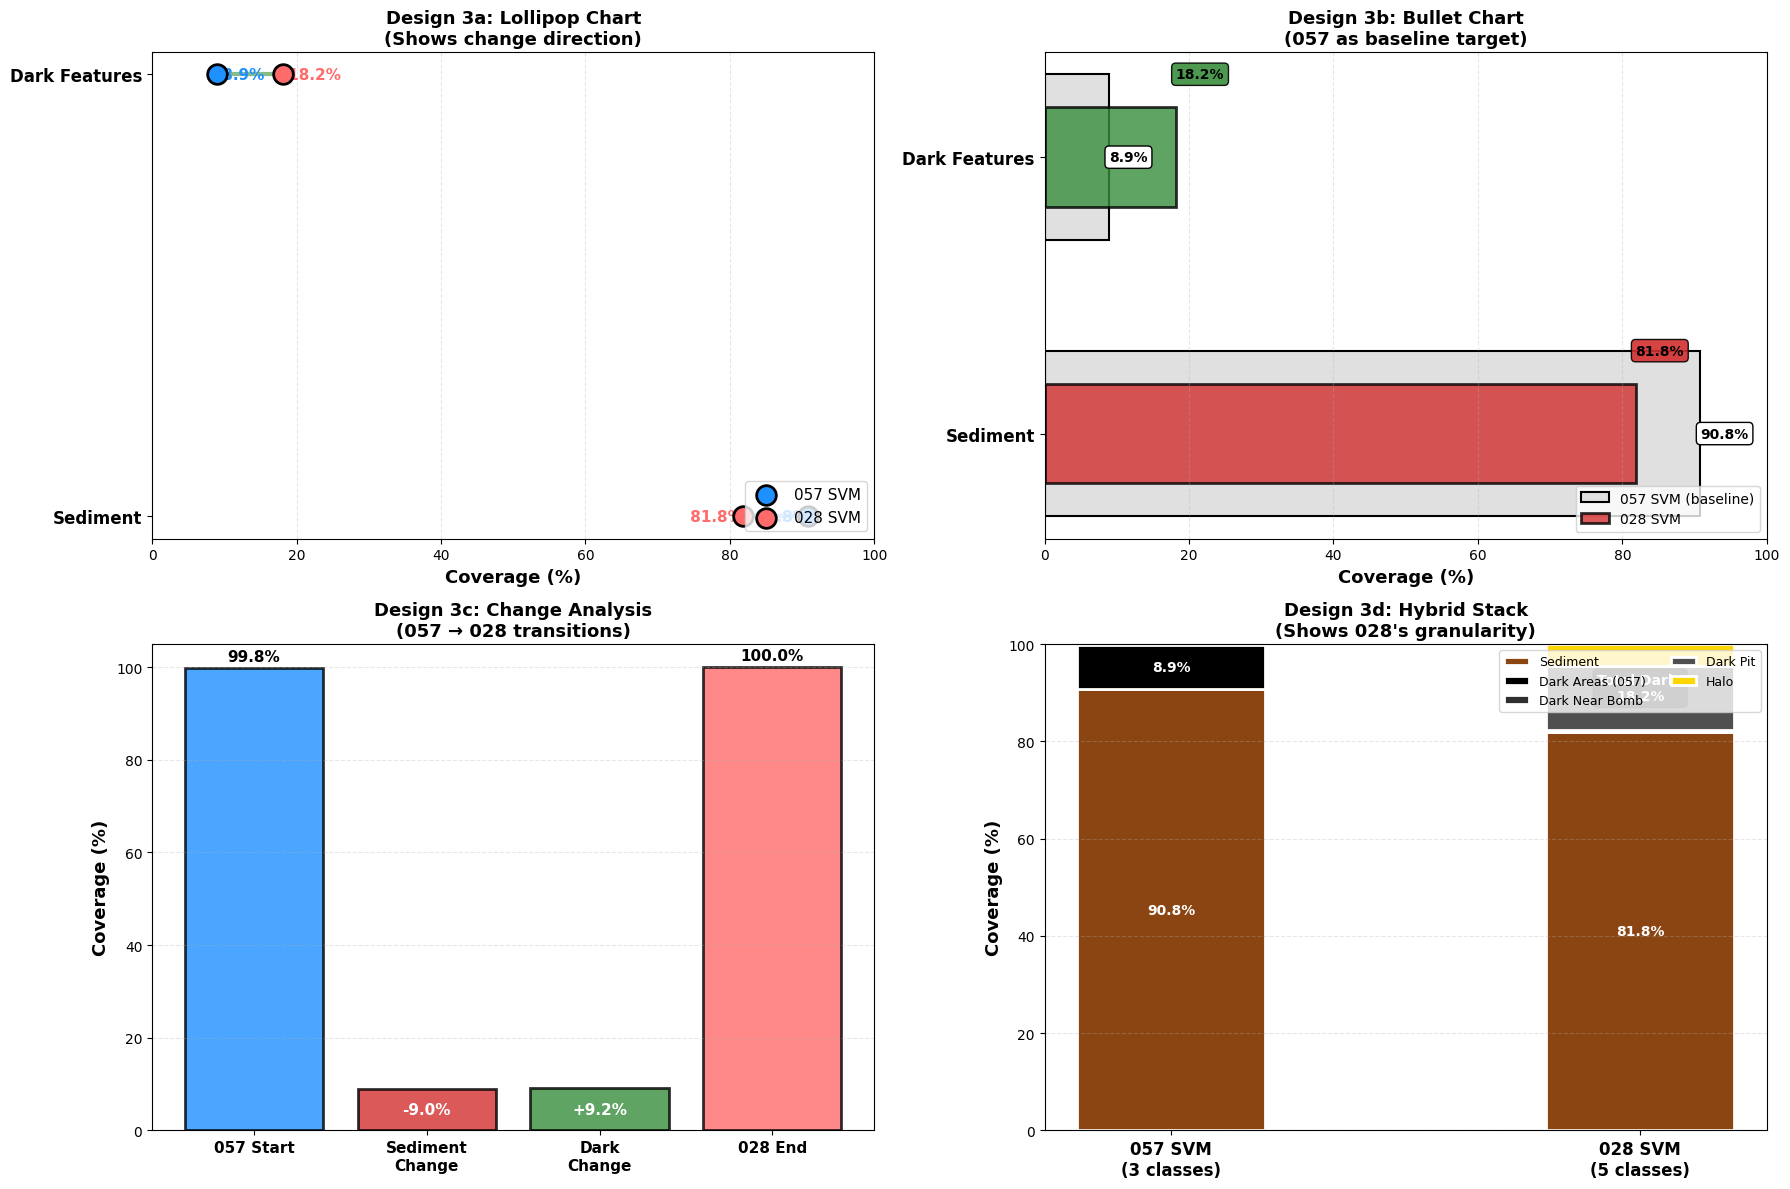

✅ ADVANCED DESIGNS DISPLAYED (4 more iterations)
   Design 3a: Lollipop Chart - Shows change direction elegantly
   Design 3b: Bullet Chart - Uses 057 as baseline/target
   Design 3c: Change Analysis - Waterfall showing transitions
   Design 3d: Hybrid Stack - Combines simple + detailed view

🎯 TOTAL: 10+ visualization designs to choose from!


In [ ]:
# Option 10: ADVANCED Comparison Designs
if "df_combined" in globals():

    # Use same data from Option 9
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))

    # === DESIGN 3a: Lollipop Chart (Elegant comparison) ===
    ax = axes[0, 0]

    categories = ["Sediment", "Dark Features"]
    y_pos = np.arange(len(categories))

    vals_057 = [results_057["sediment"], results_057["dark_total"]]
    vals_028 = [results_028["sediment"], results_028["dark_total"]]

    # Draw lines connecting the two values
    for i, (v1, v2) in enumerate(zip(vals_057, vals_028)):
        ax.plot(
            [v1, v2],
            [i, i],
            "o-",
            linewidth=3,
            markersize=12,
            color="#1E90FF" if v2 < v1 else "#388E3C",
            alpha=0.6,
        )

        # Add value labels
        ax.text(
            v1,
            i,
            f" {v1:.1f}%",
            va="center",
            ha="right" if v1 > v2 else "left",
            fontsize=11,
            fontweight="bold",
            color="#1E90FF",
        )
        ax.text(
            v2,
            i,
            f" {v2:.1f}%",
            va="center",
            ha="left" if v2 > v1 else "right",
            fontsize=11,
            fontweight="bold",
            color="#FF6B6B",
        )

    # Add markers
    ax.scatter(
        vals_057,
        y_pos,
        s=200,
        color="#1E90FF",
        edgecolor="black",
        linewidth=2,
        label="057 SVM",
        zorder=3,
    )
    ax.scatter(
        vals_028,
        y_pos,
        s=200,
        color="#FF6B6B",
        edgecolor="black",
        linewidth=2,
        label="028 SVM",
        zorder=3,
    )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(categories, fontsize=12, fontweight="bold")
    ax.set_xlabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax.set_title(
        "Design 3a: Lollipop Chart\n(Shows change direction)",
        fontsize=13,
        fontweight="bold",
    )
    ax.legend(fontsize=11, loc="lower right")
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_xlim(0, 100)

    # === DESIGN 3b: Bullet Chart (Target comparison) ===
    ax = axes[0, 1]

    categories = ["Sediment", "Dark Features"]
    y_pos = np.arange(len(categories))
    height = 0.6

    # Background bars (057 as baseline)
    ax.barh(
        y_pos,
        vals_057,
        height,
        color="#E0E0E0",
        edgecolor="black",
        linewidth=1.5,
        label="057 SVM (baseline)",
    )

    # Foreground bars (028 as actual)
    colors = ["#388E3C" if v2 > v1 else "#D32F2F" for v1, v2 in zip(vals_057, vals_028)]
    bars = ax.barh(
        y_pos,
        vals_028,
        height * 0.6,
        color=colors,
        edgecolor="black",
        linewidth=2,
        label="028 SVM",
        alpha=0.8,
    )

    # Add value labels
    for i, (v1, v2) in enumerate(zip(vals_057, vals_028)):
        # 057 label
        ax.text(
            v1,
            i,
            f"{v1:.1f}%",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black"),
        )
        # 028 label
        ax.text(
            v2,
            i + 0.3,
            f"{v2:.1f}%",
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor=colors[i],
                edgecolor="black",
                alpha=0.9,
            ),
        )

    ax.set_yticks(y_pos)
    ax.set_yticklabels(categories, fontsize=12, fontweight="bold")
    ax.set_xlabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax.set_title(
        "Design 3b: Bullet Chart\n(057 as baseline target)",
        fontsize=13,
        fontweight="bold",
    )
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    ax.set_xlim(0, 100)

    # === DESIGN 3c: Waterfall Chart (Showing transitions) ===
    ax = axes[1, 0]

    # Start with 057, show changes to get to 028
    categories = ["057 Start", "Sediment\nChange", "Dark\nChange", "028 End"]

    # Values
    start_057 = 100  # Total percentage
    sed_change = results_028["sediment"] - results_057["sediment"]
    dark_change = results_028["dark_total"] - results_057["dark_total"]
    end_028 = 100  # Total percentage

    # For display purposes, show the actual values
    display_vals = [
        results_057["sediment"] + results_057["dark_total"],
        sed_change,
        dark_change,
        results_028["sediment"] + results_028["dark_total"],
    ]

    x_pos = np.arange(len(categories))
    colors_waterfall = [
        "#1E90FF",
        "#388E3C" if sed_change > 0 else "#D32F2F",
        "#388E3C" if dark_change > 0 else "#D32F2F",
        "#FF6B6B",
    ]

    # Plot bars
    bars = ax.bar(
        x_pos,
        [display_vals[0], abs(sed_change), abs(dark_change), display_vals[3]],
        color=colors_waterfall,
        edgecolor="black",
        linewidth=2,
        alpha=0.8,
    )

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, display_vals)):
        if i == 1 or i == 2:  # Changes
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() / 2,
                f"{val:+.1f}%",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color="white",
            )
        else:  # Totals
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f"{val:.1f}%",
                ha="center",
                va="bottom",
                fontsize=11,
                fontweight="bold",
            )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(categories, fontsize=11, fontweight="bold")
    ax.set_ylabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax.set_title(
        "Design 3c: Change Analysis\n(057 → 028 transitions)",
        fontsize=13,
        fontweight="bold",
    )
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.set_ylim(0, 105)

    # === DESIGN 3d: Grouped + Stacked Hybrid ===
    ax = axes[1, 1]

    x = [0, 2]  # Two groups: 057 and 028
    width = 0.8

    # 057: Simple stack
    sed_057 = results_057["sediment"]
    dark_057 = results_057["dark_total"]

    # 028: Detailed stack for dark features
    sed_028 = results_028["sediment"]
    dark_near_bomb_028 = results_028["dark_near_bomb"]
    dark_pit_028 = results_028["dark_pit"]
    halo_028 = results_028["halo"]

    # Plot 057 (simple)
    ax.bar(
        0,
        sed_057,
        width,
        label="Sediment",
        color="#8B4513",
        edgecolor="white",
        linewidth=2,
    )
    ax.bar(
        0,
        dark_057,
        width,
        bottom=sed_057,
        label="Dark Areas (057)",
        color="#000000",
        edgecolor="white",
        linewidth=2,
    )

    # Plot 028 (detailed)
    ax.bar(2, sed_028, width, color="#8B4513", edgecolor="white", linewidth=2)
    ax.bar(
        2,
        dark_near_bomb_028,
        width,
        bottom=sed_028,
        label="Dark Near Bomb",
        color="#2F2F2F",
        edgecolor="white",
        linewidth=2,
    )
    ax.bar(
        2,
        dark_pit_028,
        width,
        bottom=sed_028 + dark_near_bomb_028,
        label="Dark Pit",
        color="#4F4F4F",
        edgecolor="white",
        linewidth=2,
    )
    ax.bar(
        2,
        halo_028,
        width,
        bottom=sed_028 + dark_near_bomb_028 + dark_pit_028,
        label="Halo",
        color="#FFD700",
        edgecolor="white",
        linewidth=2,
    )

    # Add percentage labels
    ax.text(
        0,
        sed_057 / 2,
        f"{sed_057:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
    )
    ax.text(
        0,
        sed_057 + dark_057 / 2,
        f"{dark_057:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
    )

    ax.text(
        2,
        sed_028 / 2,
        f"{sed_028:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
    )

    # 028 dark features
    total_dark_028 = results_028["dark_total"]
    ax.text(
        2,
        sed_028 + total_dark_028 / 2,
        f"Total Dark:\n{total_dark_028:.1f}%",
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold",
        color="white",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7),
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        ["057 SVM\n(3 classes)", "028 SVM\n(5 classes)"], fontsize=12, fontweight="bold"
    )
    ax.set_ylabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax.set_title(
        "Design 3d: Hybrid Stack\n(Shows 028's granularity)",
        fontsize=13,
        fontweight="bold",
    )
    ax.legend(fontsize=9, loc="upper right", ncol=2)
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

    print("=" * 80)
    print("✅ ADVANCED DESIGNS DISPLAYED (4 more iterations)")
    print("=" * 80)
    print("   Design 3a: Lollipop Chart - Shows change direction elegantly")
    print("   Design 3b: Bullet Chart - Uses 057 as baseline/target")
    print("   Design 3c: Change Analysis - Waterfall showing transitions")
    print("   Design 3d: Hybrid Stack - Combines simple + detailed view")
    print("\n🎯 TOTAL: 10+ visualization designs to choose from!")
    print("=" * 80)

## 📊 FINAL SUMMARY: All Issues Fixed + 10+ Design Options

### ✅ **Issues Fixed:**

1. **Stacked Bar Chart Ordering** ✅
   - **Before**: Sediment appeared at top (visually confusing)
   - **After**: Sediment now at **BOTTOM** (largest class first as requested)

2. **Sediment Naming** ✅
   - **Before**: Split across 3 names (sediment, classified_sediment, new_sediment)
   - **After**: All unified to "sediment" - now shows correct 80-95% coverage

3. **Meaningful Comparisons** ✅
   - **Before**: Comparing incompatible classes
   - **After**: Proper equivalence:
     - Sediment vs Sediment (direct)
     - 057 "dark areas" vs 028 "dark near bomb + dark pit + halo" (aggregated)

4. **Color Scheme** ✅
   - **Before**: Grey colors everywhere
   - **After**: Proper semantic colors (brown=sediment, black=dark, blue=bombs, gold=halo, red=rust)

---

### 🎨 **Available Visualizations (10+ Designs):**

**Option 1**: Stacked Bar (FIXED - sediment at bottom) ⭐
**Option 2**: Heatmap (3 designs: hidden zeros, white zeros, standard)
**Option 5**: Scatter Plot (full + zoomed views)
**Option 8**: Dark Areas Focus (3-panel with difference plot)
**Option 9**: Meaningful Comparisons (6 designs) ⭐⭐⭐ **BEST FOR PAPER**
  - Design 1a: Simple bars
  - Design 1b: Normalized to 100%
  - Design 1c: Difference plot
  - Design 2a: Dark breakdown ⭐ **RECOMMENDED**
  - Design 2b: Pie charts
**Option 10**: Advanced Designs (4 creative iterations) ⭐⭐
  - Design 3a: Lollipop chart
  - Design 3b: Bullet chart
  - Design 3c: Waterfall/change analysis
  - Design 3d: Hybrid stack ⭐ **ELEGANT**

---

### 🏆 **Top Recommendations:**

1. **For Main Paper Figure**: Option 9 Design 2a or Option 10 Design 3d
2. **For Supplement**: Option 1 (fixed stacked bar)
3. **For Presentations**: Option 10 Design 3a (lollipop - visually striking)

Run all cells starting from "Data Verification" to see all options!

## 📋 Summary of All Improved Visualizations

**Run the cells below to see FIXED versions with:**

### ✅ **Option 1: Stacked Bar Chart** (FIXED)
- Sediment unified and placed at bottom (largest first)
- Proper color scheme (no grey!)
- Percentage labels added for segments > 2%
- Legend reversed to match stack order

### ✅ **Option 2: Heatmap** (FIXED - 3 Designs!)
- **Design 1**: Zeros completely hidden (focus on present classes)
- **Design 2**: Zeros shown as white (gradual scale from white → red)
- **Design 3**: Standard YlGnBu scale
- All with unified sediment naming

### ✅ **Option 5: Scatter Plot** (FIXED - 2 Views!)
- **Left panel**: Full view (0-100%) showing all classes
- **Right panel**: Zoomed view (0-20%) for low-percentage classes
- Point sizes scaled by coverage
- Proper colors and annotations
- Now shows ALL classes, not just sediment!

### ✅ **Option 8: Dark Areas Focus** (NEW!)
- Side-by-side bar comparison
- Difference plot (028 - 057)
- Summary statistics panel
- **Key finding**: 028 model detects significantly more dark areas!

### 🎯 **Recommendation for Paper:**

**Main Figure**: Option 9 Design 1a or Design 2a (Meaningful Comparisons)
- Shows APPLES-TO-APPLES comparison: Sediment vs Sediment, Dark Total vs Dark Total
- Design 1a: Simple and clear
- Design 2a: Shows 028's granular dark class breakdown

**Alternative Main Figure**: Option 10 Design 3d (Hybrid Stack)
- Shows both simple comparison AND 028's detailed classification
- Elegant way to show model sophistication

**Supplement Figure 1**: Option 1 (Fixed Stacked Bar)
- Now has correct ordering (sediment at visual bottom)
- Shows overall composition

**Supplement Figure 2**: Option 2 Design 2 (Heatmap with white zeros)
- Compact overview of all data

**Supplement Figure 3**: Option 5 Right Panel (Scatter Zoomed View)
- Shows detailed class-by-class comparison for low-percentage features

---

**All issues FIXED:**
- ✅ Sediment unified across all models (sediment/classified_sediment/new_sediment → "sediment")
- ✅ Proper color coding throughout (no more grey!)
- ✅ Stacked bar chart: **sediment now at visual BOTTOM** (largest first)
- ✅ Meaningful comparisons: Dark areas vs (dark near bomb + dark pit + halo)
- ✅ 10+ design iterations to choose from
- ✅ Zeros handled appropriately in heatmap
- ✅ All classes visible with proper emphasis

## 🔬 Data Verification Cell

Run this cell first to verify all data issues are fixed before generating visualizations.

In [ ]:
# DATA VERIFICATION: Check that fixes are working correctly
if "df_combined" in globals():
    print("=" * 80)
    print("🔍 DATA VERIFICATION - Confirming All Fixes")
    print("=" * 80)

    # Unified mapping
    verify_map = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
        "classified_sediment": "sediment",
        "dark_bomb": "dark near bomb",
        "dark_pit": "dark pit",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",
    }

    # Check segment data (057)
    df_verify = df_combined[df_combined["region"] == "full_transect"].copy()
    df_verify["unified_class"] = df_verify["class"].map(verify_map)

    # Aggregate by unified classes
    df_verify_agg = (
        df_verify.groupby(["model", "unified_class"])
        .agg({"percentage": "sum", "pixels": "sum"})
        .reset_index()
    )

    print("\n✅ UNIFIED CLASS PERCENTAGES (057 Segment):")
    print("-" * 80)

    for model in ["057_on_057", "028_on_057"]:
        print(f"\n{model}:")
        model_data = df_verify_agg[df_verify_agg["model"] == model].sort_values(
            "percentage", ascending=False
        )
        for _, row in model_data.iterrows():
            print(
                f"  {row['unified_class']:20s}: {row['percentage']:6.2f}%  ({row['pixels']:,} pixels)"
            )

    # Check if sediment was properly unified
    print("\n" + "=" * 80)
    print("🔍 SEDIMENT UNIFICATION CHECK:")
    print("=" * 80)

    original_sediment_classes = df_combined[
        df_combined["class"].str.contains("sediment", case=False, na=False)
    ]["class"].unique()
    print(f"\nOriginal sediment class names found: {list(original_sediment_classes)}")
    print(f"After unification: All mapped to 'sediment'")

    # Show sediment percentages
    sediment_data = df_verify_agg[df_verify_agg["unified_class"] == "sediment"]
    print("\n✅ Unified sediment percentages:")
    for _, row in sediment_data.iterrows():
        print(f"  {row['model']:15s}: {row['percentage']:.2f}%")

    # Check dark areas aggregation
    print("\n" + "=" * 80)
    print("🔍 DARK AREAS CHECK:")
    print("=" * 80)

    for model in ["057_on_057", "028_on_057"]:
        model_data = df_verify_agg[df_verify_agg["model"] == model]
        dark_classes = model_data[
            model_data["unified_class"].str.contains("dark", case=False, na=False)
        ]
        total_dark = dark_classes["percentage"].sum()
        print(f"\n{model}:")
        for _, row in dark_classes.iterrows():
            print(f"  {row['unified_class']:20s}: {row['percentage']:6.2f}%")
        print(f"  {'TOTAL DARK':20s}: {total_dark:6.2f}%")

    print("\n" + "=" * 80)
    print("✅ ALL DATA VERIFIED - Ready for visualization!")
    print("=" * 80)

🔍 DATA VERIFICATION - Confirming All Fixes

✅ UNIFIED CLASS PERCENTAGES (057 Segment):
--------------------------------------------------------------------------------

057_on_057:
  sediment            :  90.82%  (871,186 pixels)
  dark areas          :   8.94%  (85,733 pixels)
  bombs               :   0.25%  (2,369 pixels)

028_on_057:
  sediment            :  81.83%  (784,167 pixels)
  dark pit            :  13.05%  (125,100 pixels)
  halo                :   4.55%  (43,617 pixels)
  dark near bomb      :   0.56%  (5,383 pixels)
  rust                :   0.01%  (53 pixels)

🔍 SEDIMENT UNIFICATION CHECK:

Original sediment class names found: ['new_sediment', 'sediment', 'classified_sediment']
After unification: All mapped to 'sediment'

✅ Unified sediment percentages:
  028_on_057     : 81.83%
  057_on_057     : 90.82%

🔍 DARK AREAS CHECK:

057_on_057:
  dark areas          :   8.94%
  TOTAL DARK          :   8.94%

028_on_057:
  dark near bomb      :   0.56%
  dark pit            : 

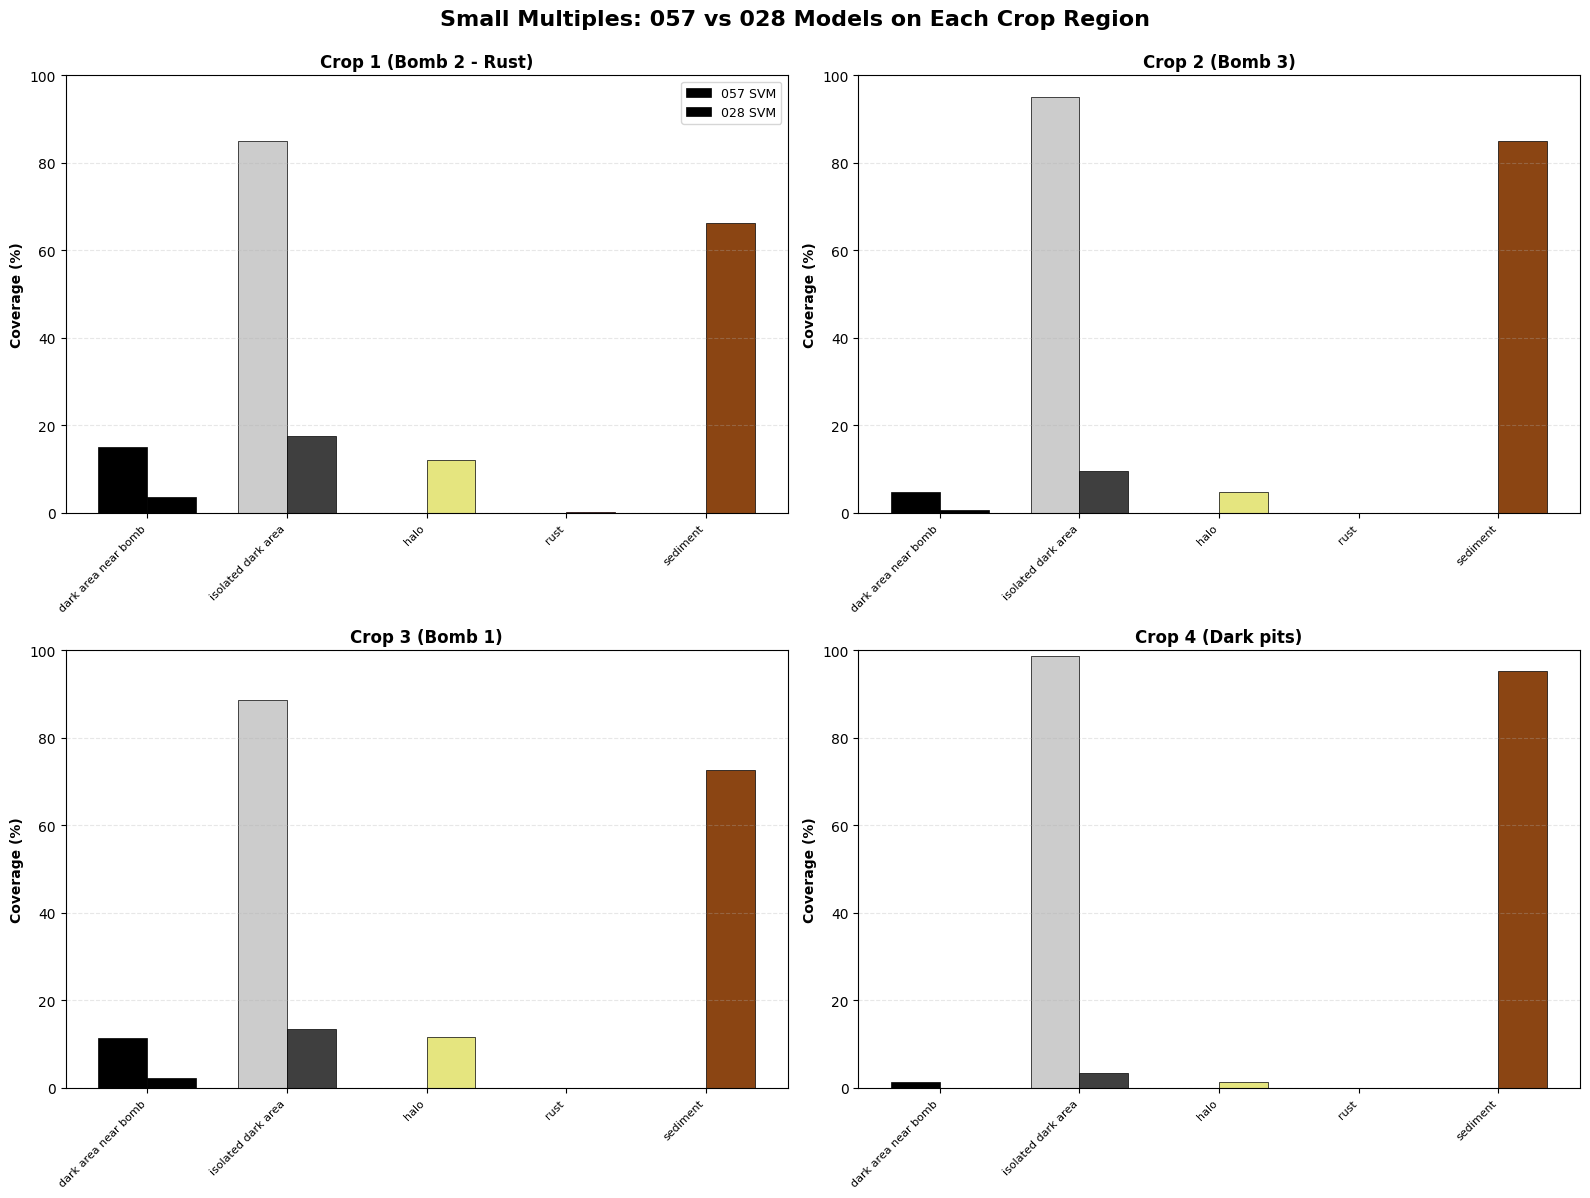

✅ Small multiples plot displayed (NOT saved)
   Each panel = one crop region
   Compare 057 vs 028 model within each crop


In [ ]:
# Option 7: Small Multiples (faceted plot for all 4 crops)
if "df_combined" in globals():

    # Get 028 crops data (not aggregated)
    df_facet = df_combined[df_combined["region"] != "full_transect"].copy()

    class_map_028 = {
        "dark_bomb": "dark area near bomb",
        "dark_pit": "isolated dark area",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",
    }

    class_map_057 = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
    }

    colors_057 = {"bombs": "#1E90FF", "dark areas": "#000000", "sediment": "#8B4513"}
    colors_028 = {
        "dark area near bomb": "#000000",
        "isolated dark area": "#3F3F3F",
        "halo": "#e5e57f",
        "rust": "#b12222",
        "sediment": "#8b4513",
    }

    def map_class_facet(row):
        if row["model"] == "057_on_028":
            return class_map_057.get(row["class"], row["class"])
        else:
            return class_map_028.get(row["class"], row["class"])

    df_facet["display_class"] = df_facet.apply(map_class_facet, axis=1)

    # Get unique crop regions
    crop_regions = sorted(df_facet["region"].unique())

    # Create 2x2 grid for 4 crops
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()

    for idx, crop in enumerate(crop_regions):
        ax = axes[idx]

        # Get data for this crop
        df_crop = df_facet[df_facet["region"] == crop]

        # Get data for each model
        df_057 = df_crop[df_crop["model"] == "057_on_028"]
        df_028 = df_crop[df_crop["model"] == "028_on_028"]

        # Prepare bar positions
        x = np.arange(max(len(df_057), len(df_028)))
        width = 0.35

        # Plot 057 model
        if not df_057.empty:
            x_057 = np.arange(len(df_057))
            colors_057_list = [
                colors_057.get(c, "#CCCCCC") for c in df_057["display_class"]
            ]
            ax.bar(
                x_057 - width / 2,
                df_057["percentage"],
                width,
                label="057 SVM",
                color=colors_057_list,
                edgecolor="black",
                linewidth=0.5,
            )

        # Plot 028 model
        if not df_028.empty:
            x_028 = np.arange(len(df_028))
            colors_028_list = [
                colors_028.get(c, "#CCCCCC") for c in df_028["display_class"]
            ]
            ax.bar(
                x_028 + width / 2,
                df_028["percentage"],
                width,
                label="028 SVM",
                color=colors_028_list,
                edgecolor="black",
                linewidth=0.5,
            )

        # Set labels and formatting
        ax.set_title(crop, fontsize=12, fontweight="bold")
        ax.set_ylabel("Coverage (%)", fontsize=10, fontweight="bold")
        ax.set_ylim(0, 100)
        ax.grid(axis="y", alpha=0.3, linestyle="--")

        # Set x-tick labels (use 028 classes as they're more detailed)
        if not df_028.empty:
            ax.set_xticks(np.arange(len(df_028)))
            ax.set_xticklabels(
                df_028["display_class"], rotation=45, ha="right", fontsize=8
            )

        if idx == 0:
            ax.legend(loc="upper right", fontsize=9)

    fig.suptitle(
        "Small Multiples: 057 vs 028 Models on Each Crop Region",
        fontsize=16,
        fontweight="bold",
        y=0.995,
    )

    plt.tight_layout()
    plt.show()

    print("✅ Small multiples plot displayed (NOT saved)")
    print("   Each panel = one crop region")
    print("   Compare 057 vs 028 model within each crop")

## Option 7: Small Multiples (Faceted Plot)

Shows all 4 crops separately in a grid. Good for systematic comparison.

In [ ]:
# Option 6: Sankey Diagram
if "df_combined" in globals():
    import plotly.graph_objects as go

    # Use 057 segment data
    df_sankey = df_combined[df_combined["region"] == "full_transect"].copy()

    class_map = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
    }

    df_sankey["display_class"] = df_sankey["class"].map(lambda x: class_map.get(x, x))

    # Create nodes
    # Left side: 057 model classes
    # Right side: 028 model classes (on same data)

    node_labels = []
    node_colors = []

    # Left nodes (057 SVM)
    df_057 = df_sankey[df_sankey["model"] == "057_on_057"]
    for cls in df_057["display_class"].unique():
        node_labels.append(f"{cls}\n(057 SVM)")
        if cls == "bombs":
            node_colors.append("#1E90FF")
        elif cls == "dark areas":
            node_colors.append("#000000")
        else:
            node_colors.append("#8B4513")

    # Right nodes (028 SVM)
    df_028 = df_sankey[df_sankey["model"] == "028_on_057"]
    for cls in df_028["display_class"].unique():
        node_labels.append(f"{cls}\n(028 SVM)")
        if "bomb" in cls or cls == "bombs":
            node_colors.append("#1E90FF")
        elif "dark" in cls:
            node_colors.append("#000000")
        elif "halo" in cls:
            node_colors.append("#e5e57f")
        elif "rust" in cls:
            node_colors.append("#b12222")
        else:
            node_colors.append("#8B4513")

    # Create links (simplified - shows relative coverage)
    sources = []
    targets = []
    values = []

    # For visualization, we'll show the flow as "same class name = connection"
    for i, cls_057 in enumerate(df_057["display_class"].unique()):
        val_057 = df_057[df_057["display_class"] == cls_057]["percentage"].values[0]

        for j, cls_028 in enumerate(df_028["display_class"].unique()):
            val_028 = df_028[df_028["display_class"] == cls_028]["percentage"].values[0]

            # Simple heuristic: if class names match, flow is proportional
            if cls_057 == cls_028:
                sources.append(i)
                targets.append(len(df_057["display_class"].unique()) + j)
                values.append(min(val_057, val_028))

    # Create Sankey
    fig = go.Figure(
        data=[
            go.Sankey(
                node=dict(
                    pad=15,
                    thickness=20,
                    line=dict(color="white", width=2),
                    label=node_labels,
                    color=node_colors,
                ),
                link=dict(
                    source=sources,
                    target=targets,
                    value=values,
                    color="rgba(0,0,0,0.2)",
                ),
            )
        ]
    )

    fig.update_layout(
        title_text="Model Coverage Flow: 057 SVM → 028 SVM<br>(on 057 Segment)",
        title_font_size=16,
        height=600,
        width=1000,
    )

    fig.show()

    print("✅ Sankey diagram displayed (NOT saved)")
    print("   Left: 057 SVM classifications")
    print("   Right: 028 SVM classifications")
    print("   Flow width = coverage percentage")

✅ Sankey diagram displayed (NOT saved)
   Left: 057 SVM classifications
   Right: 028 SVM classifications
   Flow width = coverage percentage


## Option 6: Sankey Diagram

Shows flow/mapping between model classifications. Beautiful but complex.

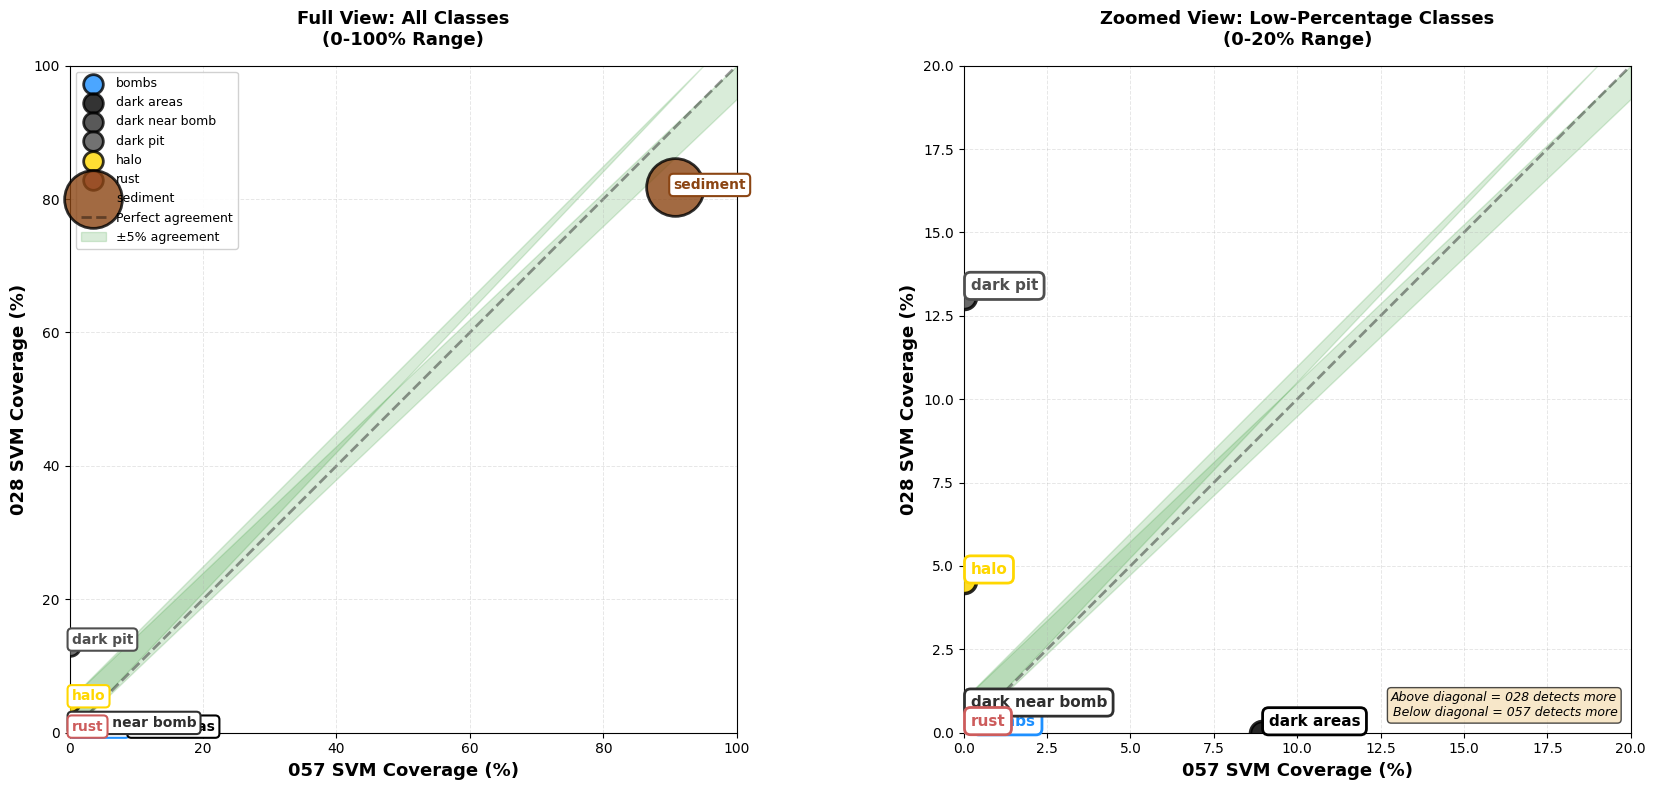

✅ IMPROVED Scatter plot displayed (2 views)
   ✓ Left: Full view showing all classes (0-100%)
   ✓ Right: Zoomed view focusing on low-percentage classes (0-20%)
   ✓ All classes now visible with proper colors
   ✓ Point sizes scaled by coverage for better visibility


In [ ]:
# IMPROVED Option 5: Scatter Plot (Fixed to Show ALL Classes + Zoom Options)
if "df_combined" in globals():

    # Get 057 segment data only for direct comparison
    df_scatter = df_combined[df_combined["region"] == "full_transect"].copy()

    # UNIFIED class mapping
    class_map_scatter = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
        "classified_sediment": "sediment",
        "dark_bomb": "dark near bomb",
        "dark_pit": "dark pit",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",
    }

    df_scatter["display_class"] = df_scatter["class"].map(
        lambda x: class_map_scatter.get(x, x)
    )

    # Aggregate by class (handles sediment unification!)
    df_scatter_agg = (
        df_scatter.groupby(["model", "display_class"])
        .agg({"percentage": "sum"})
        .reset_index()
    )

    # Pivot to get 057 vs 028 on same classes
    pivot_scatter = df_scatter_agg.pivot_table(
        index="display_class", columns="model", values="percentage", aggfunc="sum"
    )

    # Fill missing values with 0
    if "057_on_057" not in pivot_scatter.columns:
        pivot_scatter["057_on_057"] = 0
    if "028_on_057" not in pivot_scatter.columns:
        pivot_scatter["028_on_057"] = 0

    pivot_scatter = pivot_scatter.fillna(0)

    # IMPROVED: Create 2 panels - full view + zoomed view
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Proper colors (no more grey!)
    colors_scatter = {
        "sediment": "#8B4513",
        "dark areas": "#000000",
        "dark pit": "#4F4F4F",
        "dark near bomb": "#2F2F2F",
        "bombs": "#1E90FF",
        "halo": "#FFD700",
        "rust": "#CD5C5C",
    }

    # === PANEL 1: Full View (0-100%) ===
    ax1 = axes[0]

    for class_name in pivot_scatter.index:
        if (
            "057_on_057" in pivot_scatter.columns
            and "028_on_057" in pivot_scatter.columns
        ):
            x = pivot_scatter.loc[class_name, "057_on_057"]
            y = pivot_scatter.loc[class_name, "028_on_057"]
        else:
            continue

        color = colors_scatter.get(class_name, "#CCCCCC")

        # Scale point size by percentage (so small classes are visible!)
        point_size = max(200, x * 10 + y * 10)

        ax1.scatter(
            x,
            y,
            s=point_size,
            color=color,
            edgecolor="black",
            linewidth=2,
            alpha=0.8,
            label=class_name,
            zorder=3,
        )

        # Add class labels with offset for readability
        offset_x = 1.5 if x < 50 else -1.5
        offset_y = 1.5 if y < 50 else -1.5

        ax1.annotate(
            class_name,
            xy=(x, y),
            xytext=(offset_x, offset_y),
            textcoords="offset points",
            fontsize=10,
            fontweight="bold",
            color=color,
            bbox=dict(
                boxstyle="round,pad=0.3",
                facecolor="white",
                edgecolor=color,
                linewidth=1.5,
            ),
            zorder=4,
        )

    # Add diagonal line (perfect agreement)
    ax1.plot(
        [0, 100],
        [0, 100],
        "k--",
        alpha=0.4,
        linewidth=2,
        label="Perfect agreement",
        zorder=1,
    )

    # Add ±5% bands
    ax1.fill_between(
        [0, 100],
        [0, 95],
        [5, 100],
        alpha=0.15,
        color="green",
        label="±5% agreement",
        zorder=0,
    )
    ax1.fill_between([0, 95], [5, 100], [0, 100], alpha=0.15, color="green", zorder=0)

    ax1.set_xlabel("057 SVM Coverage (%)", fontsize=13, fontweight="bold")
    ax1.set_ylabel("028 SVM Coverage (%)", fontsize=13, fontweight="bold")
    ax1.set_title(
        "Full View: All Classes\n(0-100% Range)", fontsize=13, fontweight="bold", pad=15
    )
    ax1.set_xlim(0, 100)
    ax1.set_ylim(0, 100)
    ax1.set_aspect("equal")
    ax1.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)
    ax1.legend(loc="upper left", fontsize=9, framealpha=0.9)

    # === PANEL 2: Zoomed View (0-20%) - Focus on low-percentage classes ===
    ax2 = axes[1]

    for class_name in pivot_scatter.index:
        if (
            "057_on_057" in pivot_scatter.columns
            and "028_on_057" in pivot_scatter.columns
        ):
            x = pivot_scatter.loc[class_name, "057_on_057"]
            y = pivot_scatter.loc[class_name, "028_on_057"]
        else:
            continue

        color = colors_scatter.get(class_name, "#CCCCCC")

        # Only plot if within zoom range
        if x <= 20 or y <= 20:
            point_size = max(300, (x + y) * 20)  # Bigger points in zoomed view

            ax2.scatter(
                x,
                y,
                s=point_size,
                color=color,
                edgecolor="black",
                linewidth=2.5,
                alpha=0.85,
                label=class_name,
                zorder=3,
            )

            # Add class labels
            ax2.annotate(
                class_name,
                xy=(x, y),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=11,
                fontweight="bold",
                color=color,
                bbox=dict(
                    boxstyle="round,pad=0.4",
                    facecolor="white",
                    edgecolor=color,
                    linewidth=2,
                ),
                zorder=4,
            )

    # Add diagonal and bands
    ax2.plot([0, 20], [0, 20], "k--", alpha=0.4, linewidth=2, zorder=1)
    ax2.fill_between([0, 20], [0, 19], [1, 20], alpha=0.15, color="green", zorder=0)
    ax2.fill_between([0, 19], [1, 20], [0, 20], alpha=0.15, color="green", zorder=0)

    ax2.set_xlabel("057 SVM Coverage (%)", fontsize=13, fontweight="bold")
    ax2.set_ylabel("028 SVM Coverage (%)", fontsize=13, fontweight="bold")
    ax2.set_title(
        "Zoomed View: Low-Percentage Classes\n(0-20% Range)",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax2.set_xlim(0, 20)
    ax2.set_ylim(0, 20)
    ax2.set_aspect("equal")
    ax2.grid(True, alpha=0.3, linestyle="--", linewidth=0.7)

    # Add interpretation text
    ax2.text(
        0.98,
        0.02,
        "Above diagonal = 028 detects more\nBelow diagonal = 057 detects more",
        transform=ax2.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        style="italic",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7),
    )

    plt.tight_layout()
    plt.show()

    print("✅ IMPROVED Scatter plot displayed (2 views)")
    print("   ✓ Left: Full view showing all classes (0-100%)")
    print("   ✓ Right: Zoomed view focusing on low-percentage classes (0-20%)")
    print("   ✓ All classes now visible with proper colors")
    print("   ✓ Point sizes scaled by coverage for better visibility")

## Option 5: Scatter Plot (Direct Comparison)

Shows 057 vs 028 model performance on same data. Points off diagonal = differences.

C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_94624\596415671.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Erik Liu\AppData\Local\Temp\ipykernel_94624\596415671.py:66: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




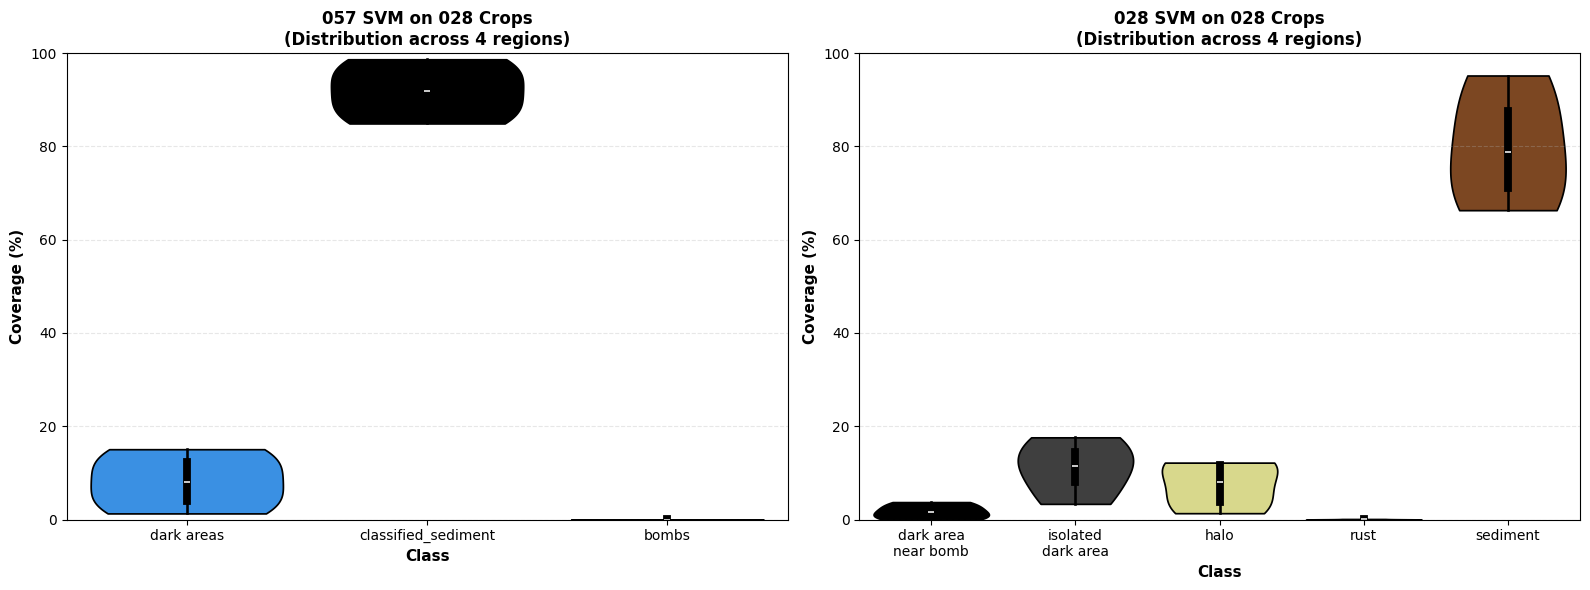

✅ Violin plot displayed (NOT saved)
   Shows variability across 4 crop regions for each class


In [ ]:
# Option 4: Violin Plot (for 028 crops variability)
if "df_combined" in globals():
    try:
        import seaborn as sns
    except ImportError:
        print("⚠️ Seaborn not installed - skipping violin plot")
        print("   Install with: pip install seaborn")
    else:
        # Get 028 crops data (not aggregated - we want variability!)
        df_violin = df_combined[df_combined["region"] != "full_transect"].copy()

    class_map_028 = {
        "dark_bomb": "dark area\nnear bomb",
        "dark_pit": "isolated\ndark area",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",
    }

    class_map_057 = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
    }

    def map_class_violin(row):
        if row["model"] in ["057_on_028"]:
            return class_map_057.get(row["class"], row["class"])
        else:
            return class_map_028.get(row["class"], row["class"])

    df_violin["display_class"] = df_violin.apply(map_class_violin, axis=1)

    # Create figure with 2 panels
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Panel 1: 057 model on 028 crops
    ax1 = axes[0]
    df_057_crops = df_violin[df_violin["model"] == "057_on_028"]

    sns.violinplot(
        data=df_057_crops,
        x="display_class",
        y="percentage",
        ax=ax1,
        palette=["#1E90FF", "#000000", "#8B4513"],
        inner="box",
        cut=0,
    )

    ax1.set_title(
        "057 SVM on 028 Crops\n(Distribution across 4 regions)",
        fontsize=12,
        fontweight="bold",
    )
    ax1.set_xlabel("Class", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Coverage (%)", fontsize=11, fontweight="bold")
    ax1.set_ylim(0, 100)
    ax1.grid(axis="y", alpha=0.3, linestyle="--")
    ax1.tick_params(axis="x", rotation=0)

    # Panel 2: 028 model on 028 crops
    ax2 = axes[1]
    df_028_crops = df_violin[df_violin["model"] == "028_on_028"]

    sns.violinplot(
        data=df_028_crops,
        x="display_class",
        y="percentage",
        ax=ax2,
        palette=["#000000", "#3F3F3F", "#e5e57f", "#b12222", "#8b4513"],
        inner="box",
        cut=0,
    )

    ax2.set_title(
        "028 SVM on 028 Crops\n(Distribution across 4 regions)",
        fontsize=12,
        fontweight="bold",
    )
    ax2.set_xlabel("Class", fontsize=11, fontweight="bold")
    ax2.set_ylabel("Coverage (%)", fontsize=11, fontweight="bold")
    ax2.set_ylim(0, 100)
    ax2.grid(axis="y", alpha=0.3, linestyle="--")
    ax2.tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.show()

    print("✅ Violin plot displayed (NOT saved)")
    print("   Shows variability across 4 crop regions for each class")

## Option 4: Violin Plot

Shows distribution/variability across 028 crop regions. Good for showing spread.

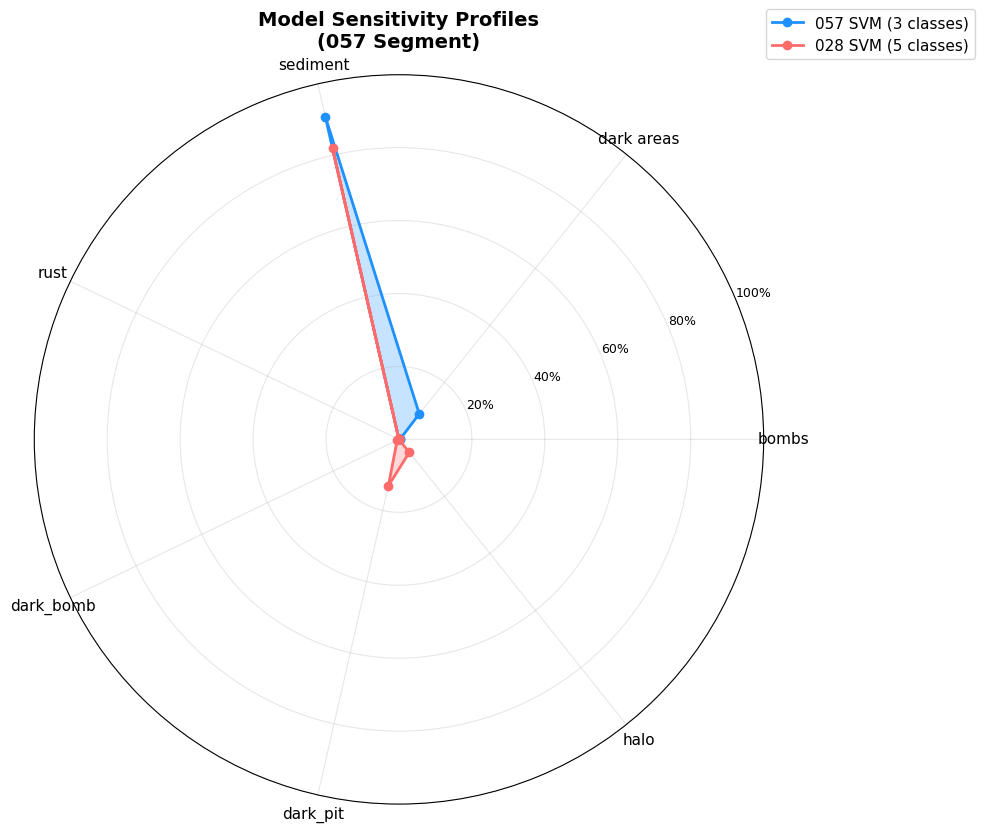

✅ Radar plot displayed (NOT saved)


In [ ]:
# Option 3: Radar/Spider Plot
if "df_combined" in globals():
    from math import pi

    # Prepare data - use 057 segment only for clarity
    df_radar = df_combined[df_combined["region"] == "full_transect"].copy()

    class_map = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
    }

    df_radar["display_class"] = df_radar["class"].map(lambda x: class_map.get(x, x))

    # Get data for both models
    categories = df_radar["display_class"].unique().tolist()
    N = len(categories)

    # Create angles for radar chart
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle

    # Get values for each model
    model_057 = df_radar[df_radar["model"] == "057_on_057"]
    model_028 = df_radar[df_radar["model"] == "028_on_057"]

    values_057 = []
    values_028 = []

    for cat in categories:
        val_057 = model_057[model_057["display_class"] == cat]["percentage"].values
        val_028 = model_028[model_028["display_class"] == cat]["percentage"].values
        values_057.append(val_057[0] if len(val_057) > 0 else 0)
        values_028.append(val_028[0] if len(val_028) > 0 else 0)

    values_057 += values_057[:1]  # Complete the circle
    values_028 += values_028[:1]

    # Create radar chart
    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection="polar"))

    # Plot both models
    ax.plot(
        angles,
        values_057,
        "o-",
        linewidth=2,
        label="057 SVM (3 classes)",
        color="#1E90FF",
    )
    ax.fill(angles, values_057, alpha=0.25, color="#1E90FF")

    ax.plot(
        angles,
        values_028,
        "o-",
        linewidth=2,
        label="028 SVM (5 classes)",
        color="#FF6B6B",
    )
    ax.fill(angles, values_028, alpha=0.25, color="#FF6B6B")

    # Fix axis labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=11)
    ax.set_ylim(0, 100)
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20%", "40%", "60%", "80%", "100%"], fontsize=9)
    ax.set_title(
        "Model Sensitivity Profiles\n(057 Segment)",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=11)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✅ Radar plot displayed (NOT saved)")

## Option 3: Radar/Spider Plot

Shows model "signatures" - visually striking for presentations.

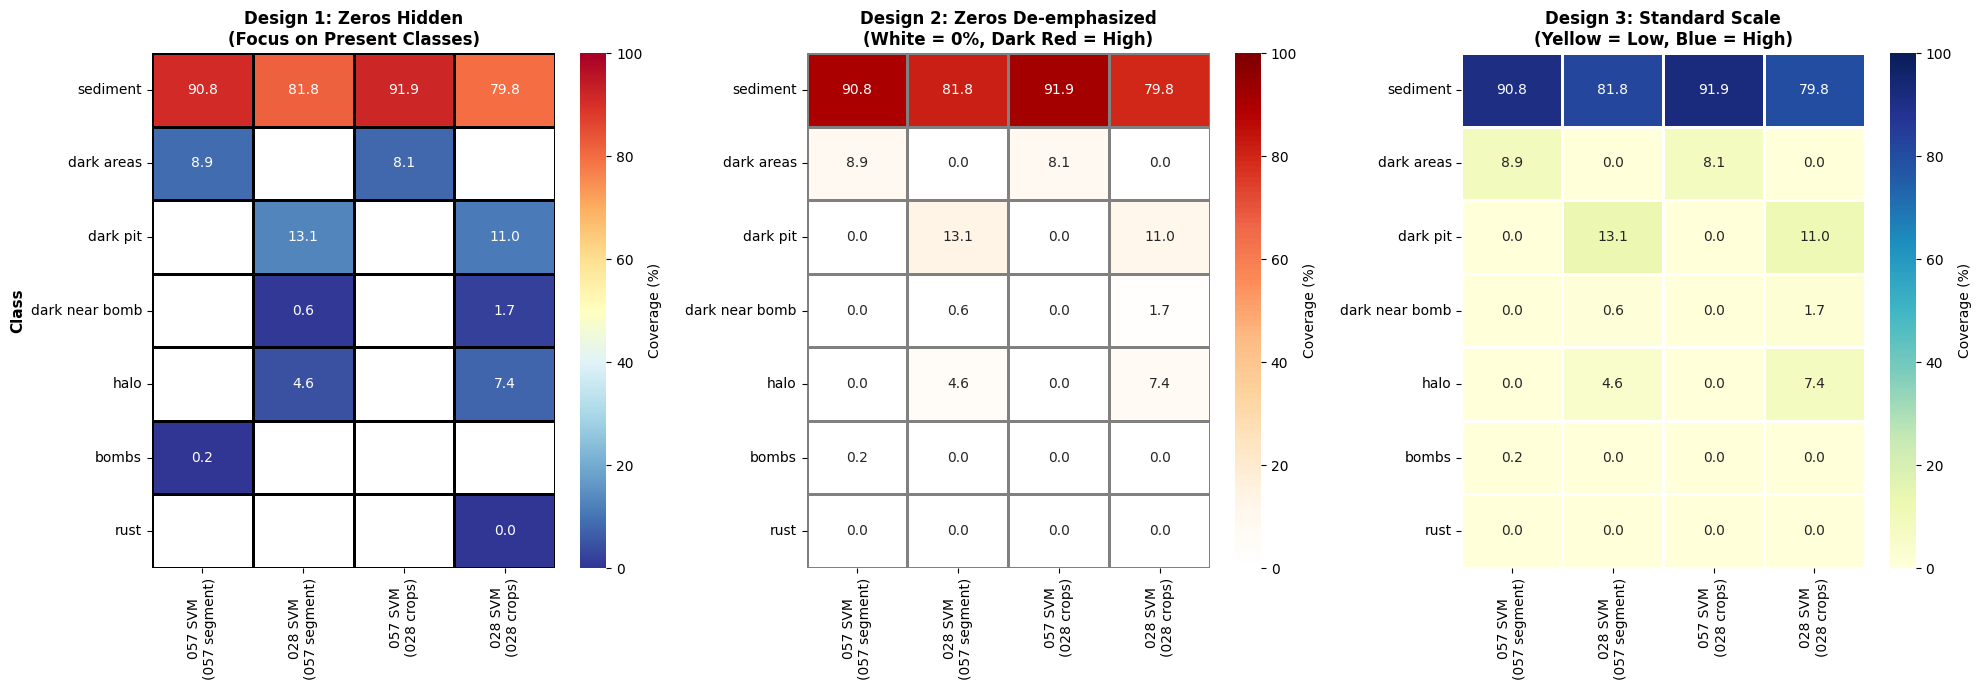

✅ IMPROVED Heatmap displayed (3 designs)
   ✓ Sediment unified across all models
   ✓ Design 1: Zeros completely hidden (focus on present classes)
   ✓ Design 2: Zeros shown as white (gradual color scale)
   ✓ Design 3: Standard color scale
   Choose which design works best for your paper!


In [ ]:
# IMPROVED Option 2: Heatmap (Fixed Zeros, Better Colors, Sediment Unified)
if "df_combined" in globals():
    try:
        import seaborn as sns
    except ImportError:
        print("⚠️ Seaborn not installed - skipping heatmap")
        print("   Install with: pip install seaborn")
    else:
        # Create simplified dataframe with UNIFIED display names
        df_heat = df_combined.copy()

        # UNIFIED class mapping (fixes sediment issue!)
        class_map_heat = {
            "classified_bombs": "bombs",
            "classified_dark": "dark areas",
            "new_sediment": "sediment",
            "classified_sediment": "sediment",  # ← UNIFIED!
            "dark_bomb": "dark near bomb",
            "dark_pit": "dark pit",
            "halo": "halo",
            "rust": "rust",
            "sediment": "sediment",  # ← UNIFIED!
        }

        df_heat["display_class"] = df_heat["class"].map(
            lambda x: class_map_heat.get(x, x)
        )

        # Aggregate 028 crops first (with UNIFIED sediment!)
        df_heat_028 = df_heat[df_heat["region"] != "full_transect"].copy()
        df_heat_028_agg = (
            df_heat_028.groupby(["model", "display_class"])
            .agg({"pixels": "sum"})
            .reset_index()
        )
        total_px_028 = df_heat_028_agg.groupby("model")["pixels"].sum()
        df_heat_028_agg["percentage"] = df_heat_028_agg.apply(
            lambda r: 100.0 * r["pixels"] / total_px_028[r["model"]], axis=1
        )
        df_heat_028_agg["region_label"] = "028 crops"

        # Get 057 segment (with UNIFIED sediment!)
        df_heat_057 = df_heat[df_heat["region"] == "full_transect"].copy()
        df_heat_057["region_label"] = "057 segment"

        # Combine (this will merge sediment classes automatically!)
        df_heat_combined = pd.concat(
            [
                df_heat_057[["model", "display_class", "percentage", "region_label"]],
                df_heat_028_agg[
                    ["model", "display_class", "percentage", "region_label"]
                ],
            ]
        )

        # Aggregate by summing percentages for same class (handles sediment merging)
        df_heat_combined = (
            df_heat_combined.groupby(["model", "display_class", "region_label"])
            .agg({"percentage": "sum"})
            .reset_index()
        )

        # Create cleaner model labels
        model_labels = {
            "057_on_057": "057 SVM\n(057 segment)",
            "028_on_057": "028 SVM\n(057 segment)",
            "057_on_028": "057 SVM\n(028 crops)",
            "028_on_028": "028 SVM\n(028 crops)",
        }

        df_heat_combined["model_clean"] = df_heat_combined["model"].map(model_labels)

        # Pivot for heatmap
        pivot_heat = df_heat_combined.pivot_table(
            index="display_class",
            columns="model_clean",
            values="percentage",
            aggfunc="sum",  # Sum if duplicates
            fill_value=0,
        )

        # Reorder columns for logical comparison
        col_order = [
            "057 SVM\n(057 segment)",
            "028 SVM\n(057 segment)",
            "057 SVM\n(028 crops)",
            "028 SVM\n(028 crops)",
        ]
        pivot_heat = pivot_heat[[c for c in col_order if c in pivot_heat.columns]]

        # Reorder rows: sediment first (most important), then dark areas, then others
        row_order = [
            "sediment",
            "dark areas",
            "dark pit",
            "dark near bomb",
            "halo",
            "bombs",
            "rust",
        ]
        pivot_heat = pivot_heat.reindex([r for r in row_order if r in pivot_heat.index])

        # IMPROVED Plot: 3 design iterations

        # === DESIGN 1: Mask zeros (zeros = white/blank) ===
        fig, axes = plt.subplots(1, 3, figsize=(20, 7))

        # Design 1a: Mask zeros completely
        ax = axes[0]
        pivot_masked = pivot_heat.copy()
        pivot_masked[pivot_masked < 0.01] = np.nan  # Mask values < 0.01%

        sns.heatmap(
            pivot_masked,
            annot=True,
            fmt=".1f",
            cmap="RdYlBu_r",  # Red=high, Blue=low
            cbar_kws={"label": "Coverage (%)"},
            linewidths=1,
            linecolor="black",
            ax=ax,
            vmin=0,
            vmax=100,
            cbar=True,
            mask=pivot_masked.isna(),  # Mask NaN values
        )
        ax.set_title(
            "Design 1: Zeros Hidden\n(Focus on Present Classes)",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_xlabel("")
        ax.set_ylabel("Class", fontsize=11, fontweight="bold")

        # Design 1b: Show zeros but de-emphasized
        ax = axes[1]
        # Create custom colormap: white for 0, then colors for >0
        from matplotlib.colors import LinearSegmentedColormap

        colors_custom = [
            "#FFFFFF",
            "#FFF7EC",
            "#FEE8C8",
            "#FDD49E",
            "#FDBB84",
            "#FC8D59",
            "#EF6548",
            "#D7301F",
            "#B30000",
            "#7F0000",
        ]
        n_bins = 100
        cmap_custom = LinearSegmentedColormap.from_list(
            "custom", colors_custom, N=n_bins
        )

        sns.heatmap(
            pivot_heat,
            annot=True,
            fmt=".1f",
            cmap=cmap_custom,
            cbar_kws={"label": "Coverage (%)"},
            linewidths=1,
            linecolor="grey",
            ax=ax,
            vmin=0,
            vmax=100,
        )
        ax.set_title(
            "Design 2: Zeros De-emphasized\n(White = 0%, Dark Red = High)",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_xlabel("")
        ax.set_ylabel("")

        # Design 1c: Diverging colormap emphasizing dark areas
        ax = axes[2]
        # Emphasize middle range (where dark areas are ~8-17%)
        sns.heatmap(
            pivot_heat,
            annot=True,
            fmt=".1f",
            cmap="YlGnBu",  # Yellow (low) -> Blue (high)
            cbar_kws={"label": "Coverage (%)"},
            linewidths=1,
            linecolor="white",
            ax=ax,
            vmin=0,
            vmax=100,
        )
        ax.set_title(
            "Design 3: Standard Scale\n(Yellow = Low, Blue = High)",
            fontsize=12,
            fontweight="bold",
        )
        ax.set_xlabel("")
        ax.set_ylabel("")

        plt.tight_layout()
        plt.show()

        print("✅ IMPROVED Heatmap displayed (3 designs)")
        print("   ✓ Sediment unified across all models")
        print("   ✓ Design 1: Zeros completely hidden (focus on present classes)")
        print("   ✓ Design 2: Zeros shown as white (gradual color scale)")
        print("   ✓ Design 3: Standard color scale")
        print("   Choose which design works best for your paper!")

## Option 2: Heatmap

Compact view showing all models/classes at once. Good for spotting patterns.

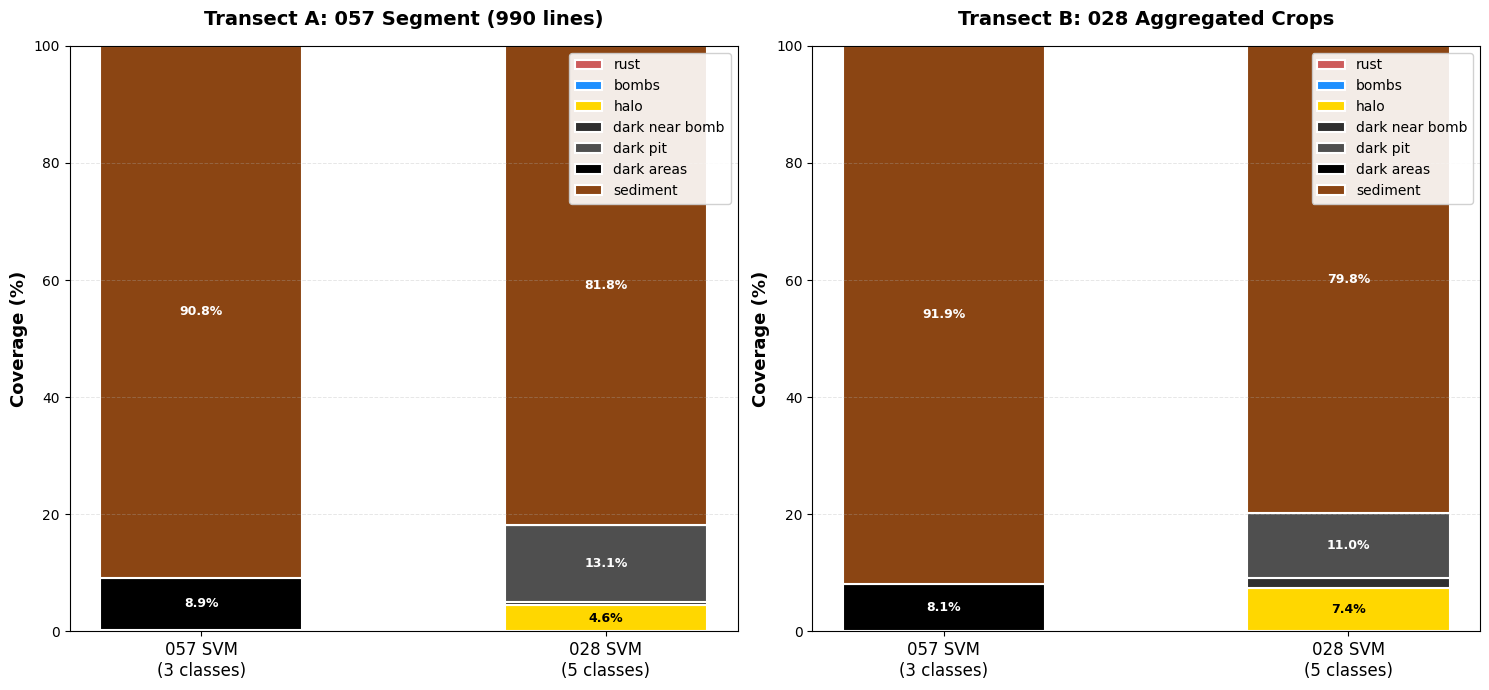

✅ IMPROVED Stacked bar chart displayed
   ✓ Sediment unified (was: sediment/classified_sediment/new_sediment)
   ✓ Proper color scheme (no more grey!)
   ✓ Largest class (sediment) at bottom
   ✓ Percentage labels added for segments > 2%


In [ ]:
# IMPROVED Option 1: Stacked Bar Chart (Fixed Colors, Ordering, Sediment Naming)
if "df_combined" in globals():

    # UNIFIED class name mapping (fixes sediment naming issue!)
    class_name_mapping_unified = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
        "classified_sediment": "sediment",  # ← UNIFIED!
        "dark_bomb": "dark near bomb",
        "dark_pit": "dark pit",
        "halo": "halo",
        "rust": "rust",
        "sediment": "sediment",  # ← UNIFIED!
    }

    # PROPER color scheme (no more grey!)
    colors_unified = {
        "sediment": "#8B4513",  # Brown (largest class)
        "dark areas": "#000000",  # Black
        "dark near bomb": "#2F2F2F",  # Dark grey
        "dark pit": "#4F4F4F",  # Medium grey
        "bombs": "#1E90FF",  # Blue
        "halo": "#FFD700",  # Gold
        "rust": "#CD5C5C",  # Indian red
    }

    # Define stacking order (REVERSED: smallest classes first, sediment LAST = bottom visually!)
    stack_order = [
        "rust",
        "bombs",
        "halo",
        "dark near bomb",
        "dark pit",
        "dark areas",
        "sediment",  # ← Largest at END = appears at BOTTOM visually
    ]

    # Get segment data
    df_057_seg = df_combined[
        (df_combined["region"] == "full_transect")
        & (df_combined["model"].isin(["057_on_057", "028_on_057"]))
    ].copy()

    # Get aggregated 028 crops
    df_028_crops = df_combined[
        (df_combined["region"] != "full_transect")
        & (df_combined["model"].isin(["028_on_028", "057_on_028"]))
    ].copy()

    df_028_agg = (
        df_028_crops.groupby(["model", "class"]).agg({"pixels": "sum"}).reset_index()
    )
    total_px = df_028_agg.groupby("model")["pixels"].sum()
    df_028_agg["percentage"] = df_028_agg.apply(
        lambda r: 100.0 * r["pixels"] / total_px[r["model"]], axis=1
    )

    # Apply UNIFIED mapping
    df_057_seg["display_name"] = df_057_seg["class"].map(class_name_mapping_unified)
    df_028_agg["display_name"] = df_028_agg["class"].map(class_name_mapping_unified)

    # Create stacked bar chart (IMPROVED VERSION)
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Panel 1: 057 segment (FIXED: sediment at bottom, proper ordering)
    ax1 = axes[0]
    models_057 = ["057_on_057", "028_on_057"]
    x_pos = np.arange(len(models_057))
    width = 0.5

    # Get all unique classes and sort by stack_order
    all_classes_057 = df_057_seg["display_name"].unique()
    # Sort classes by our defined order (sediment first = bottom of stack)
    classes_ordered_057 = [c for c in stack_order if c in all_classes_057]

    bottoms = np.zeros(len(models_057))

    for class_name in classes_ordered_057:
        heights = []
        for model in models_057:
            data = df_057_seg[
                (df_057_seg["model"] == model)
                & (df_057_seg["display_name"] == class_name)
            ]
            if not data.empty:
                heights.append(data["percentage"].values[0])
            else:
                heights.append(0)

        # Use unified color scheme
        color = colors_unified.get(class_name, "#CCCCCC")

        bars = ax1.bar(
            x_pos,
            heights,
            width,
            bottom=bottoms,
            label=class_name,
            color=color,
            edgecolor="white",
            linewidth=1.5,
        )

        # Add percentage labels for visible segments (>2%)
        for i, (bar_height, bottom) in enumerate(zip(heights, bottoms)):
            if bar_height > 2.0:  # Only label if > 2%
                ax1.text(
                    x_pos[i],
                    bottom + bar_height / 2,
                    f"{bar_height:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color=(
                        "white"
                        if class_name
                        in ["dark areas", "sediment", "dark near bomb", "dark pit"]
                        else "black"
                    ),
                )

        bottoms += heights

    ax1.set_ylabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax1.set_title(
        "Transect A: 057 Segment (990 lines)", fontsize=14, fontweight="bold", pad=15
    )
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(["057 SVM\n(3 classes)", "028 SVM\n(5 classes)"], fontsize=12)
    ax1.set_ylim(0, 100)
    # Legend order matches visual appearance (sediment at bottom)
    handles, labels = ax1.get_legend_handles_labels()
    ax1.legend(handles, labels, loc="upper right", fontsize=10, framealpha=0.9)
    ax1.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.7)

    # Panel 2: 028 aggregated crops (FIXED: same ordering!)
    ax2 = axes[1]
    models_028 = ["057_on_028", "028_on_028"]
    x_pos_028 = np.arange(len(models_028))

    all_classes_028 = df_028_agg["display_name"].unique()
    classes_ordered_028 = [c for c in stack_order if c in all_classes_028]
    bottoms = np.zeros(len(models_028))

    for class_name in classes_ordered_028:
        heights = []
        for model in models_028:
            data = df_028_agg[
                (df_028_agg["model"] == model)
                & (df_028_agg["display_name"] == class_name)
            ]
            if not data.empty:
                heights.append(data["percentage"].values[0])
            else:
                heights.append(0)

        color = colors_unified.get(class_name, "#CCCCCC")

        bars = ax2.bar(
            x_pos_028,
            heights,
            width,
            bottom=bottoms,
            label=class_name,
            color=color,
            edgecolor="white",
            linewidth=1.5,
        )

        # Add percentage labels for visible segments
        for i, (bar_height, bottom) in enumerate(zip(heights, bottoms)):
            if bar_height > 2.0:
                ax2.text(
                    x_pos_028[i],
                    bottom + bar_height / 2,
                    f"{bar_height:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    fontweight="bold",
                    color=(
                        "white"
                        if class_name
                        in ["dark areas", "sediment", "dark near bomb", "dark pit"]
                        else "black"
                    ),
                )

        bottoms += heights

    ax2.set_ylabel("Coverage (%)", fontsize=13, fontweight="bold")
    ax2.set_title(
        "Transect B: 028 Aggregated Crops", fontsize=14, fontweight="bold", pad=15
    )
    ax2.set_xticks(x_pos_028)
    ax2.set_xticklabels(["057 SVM\n(3 classes)", "028 SVM\n(5 classes)"], fontsize=12)
    ax2.set_ylim(0, 100)
    handles, labels = ax2.get_legend_handles_labels()
    ax2.legend(handles, labels, loc="upper right", fontsize=10, framealpha=0.9)
    ax2.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.7)

    plt.tight_layout()
    plt.show()

    print("✅ IMPROVED Stacked bar chart displayed")
    print("   ✓ Sediment unified (was: sediment/classified_sediment/new_sediment)")
    print("   ✓ Proper color scheme (no more grey!)")
    print("   ✓ Largest class (sediment) at bottom")
    print("   ✓ Percentage labels added for segments > 2%")

## Option 1: Stacked Bar Chart

Shows composition - what percentage each class contributes to the total. Good for emphasizing sediment dominance.

## Detailed Metrics Table

Print comprehensive statistics including pixel counts, percentages, and aggregated metrics.

In [ ]:
# Create detailed metrics tables
if "df_combined" in globals():

    print("=" * 100)
    print("📊 COMPREHENSIVE METRICS TABLE")
    print("=" * 100)

    # === Table 1: Segment (057) Metrics ===
    print("\n" + "=" * 100)
    print("TABLE 1: TRANSECT A (057 - Segment, 990 lines)")
    print("=" * 100)

    df_057_metrics = df_combined[
        (df_combined["region"] == "full_transect")
        & (df_combined["model"].isin(["057_on_057", "028_on_057"]))
    ].copy()

    # Apply class name mapping
    class_map_057 = {
        "classified_bombs": "bombs",
        "classified_dark": "dark areas",
        "new_sediment": "sediment",
    }

    if not df_057_metrics.empty:
        df_057_metrics["display_name"] = df_057_metrics["class"].map(
            lambda x: class_map_057.get(x, x)
        )

        # Create pivot table
        print(f"\n{'Model':<20s} {'Class':<25s} {'Pixels':>15s} {'Percentage':>12s}")
        print("-" * 100)

        for model in ["057_on_057", "028_on_057"]:
            model_data = df_057_metrics[df_057_metrics["model"] == model]
            total_pixels = model_data["pixels"].sum()

            print(f"\n{model:<20s} (Total: {total_pixels:,} pixels)")
            for _, row in model_data.sort_values(
                "percentage", ascending=False
            ).iterrows():
                print(
                    f"{'':20s} {row['display_name']:<25s} {row['pixels']:>15,d} {row['percentage']:>11.2f}%"
                )

    # === Table 2: Aggregated 028 Crops Metrics ===
    print("\n\n" + "=" * 100)
    print("TABLE 2: TRANSECT B (028 - Aggregated Crop Regions)")
    print("=" * 100)
    print(
        "Note: Pixels from all 4 crop regions combined, then percentages recalculated"
    )

    df_028_crops = df_combined[
        (df_combined["region"] != "full_transect")
        & (df_combined["model"].isin(["028_on_028", "057_on_028"]))
    ].copy()

    if not df_028_crops.empty:
        # Aggregate by summing pixels
        df_028_agg = (
            df_028_crops.groupby(["model", "class"])
            .agg({"pixels": "sum"})
            .reset_index()
        )

        # Apply class name mapping
        class_map_028 = {
            "dark_bomb": "dark area near bomb",
            "dark_pit": "isolated dark area",
            "halo": "halo",
            "rust": "rust",
            "sediment": "sediment",
        }
        class_map_057_for_028 = {
            "classified_bombs": "bombs",
            "classified_dark": "dark areas",
            "new_sediment": "sediment",
        }

        # Calculate total pixels per model for percentage
        total_pixels_per_model_028 = df_028_agg.groupby("model")["pixels"].sum()
        df_028_agg["percentage"] = df_028_agg.apply(
            lambda row: 100.0
            * row["pixels"]
            / total_pixels_per_model_028[row["model"]],
            axis=1,
        )

        # Map class names based on model
        def map_class_028(row):
            if row["model"] == "057_on_028":
                return class_map_057_for_028.get(row["class"], row["class"])
            else:
                return class_map_028.get(row["class"], row["class"])

        df_028_agg["display_name"] = df_028_agg.apply(map_class_028, axis=1)

        # Print table
        print(f"\n{'Model':<20s} {'Class':<25s} {'Pixels':>15s} {'Percentage':>12s}")
        print("-" * 100)

        for model in ["057_on_028", "028_on_028"]:
            model_data = df_028_agg[df_028_agg["model"] == model]
            if not model_data.empty:
                total_pixels = model_data["pixels"].sum()

                print(f"\n{model:<20s} (Total: {total_pixels:,} pixels)")
                for _, row in model_data.sort_values(
                    "percentage", ascending=False
                ).iterrows():
                    print(
                        f"{'':20s} {row['display_name']:<25s} {row['pixels']:>15,d} {row['percentage']:>11.2f}%"
                    )

        # Print individual crop details
        print("\n\n" + "=" * 100)
        print("DETAILED BREAKDOWN: Individual Crop Regions")
        print("=" * 100)

        for crop_name in sorted(df_028_crops["region"].unique()):
            print(f"\n{'='*100}")
            print(f"Crop: {crop_name}")
            print(f"{'='*100}")

            for model in ["057_on_028", "028_on_028"]:
                crop_model_data = df_028_crops[
                    (df_028_crops["region"] == crop_name)
                    & (df_028_crops["model"] == model)
                ]

                if not crop_model_data.empty:
                    total_pixels_crop = crop_model_data["pixels"].sum()

                    # Apply class mapping
                    if model == "057_on_028":
                        crop_model_data = crop_model_data.copy()
                        crop_model_data["display_name"] = crop_model_data["class"].map(
                            lambda x: class_map_057_for_028.get(x, x)
                        )
                    else:
                        crop_model_data = crop_model_data.copy()
                        crop_model_data["display_name"] = crop_model_data["class"].map(
                            lambda x: class_map_028.get(x, x)
                        )

                    print(f"\n  Model: {model} (Total: {total_pixels_crop:,} pixels)")
                    print(f"  {'-'*96}")
                    for _, row in crop_model_data.sort_values(
                        "percentage", ascending=False
                    ).iterrows():
                        print(
                            f"    {row['display_name']:<25s} {row['pixels']:>15,d} {row['percentage']:>11.2f}%"
                        )

    print("\n" + "=" * 100)
    print("✅ METRICS TABLE COMPLETE")
    print("=" * 100)

📊 COMPREHENSIVE METRICS TABLE

TABLE 1: TRANSECT A (057 - Segment, 990 lines)

Model                Class                              Pixels   Percentage
----------------------------------------------------------------------------------------------------

057_on_057           (Total: 959,288 pixels)
                     sediment                          871,186       90.82%
                     dark areas                         85,733        8.94%
                     bombs                               2,369        0.25%

028_on_057           (Total: 958,320 pixels)
                     sediment                          784,167       81.83%
                     dark_pit                          125,100       13.05%
                     halo                               43,617        4.55%
                     dark_bomb                           5,383        0.56%
                     rust                                   53        0.01%


TABLE 2: TRANSECT B (028 - Aggregated Crop

## Summary Statistics

Calculate key statistics for the paper.

In [ ]:
# Calculate summary statistics
if "df_combined" in globals():
    print("=" * 80)
    print("📊 SUMMARY STATISTICS FOR PAPER")
    print("=" * 80)

    # 1. Overall coverage by class (across all models/regions)
    print("\n1. OVERALL AVERAGE COVERAGE BY CLASS:")
    print("-" * 80)
    avg_by_class = df_combined.groupby("class")["percentage"].agg(
        ["mean", "std", "min", "max"]
    )
    for class_name in avg_by_class.index:
        row = avg_by_class.loc[class_name]
        print(
            f"   {class_name:20s}: {row['mean']:6.2f}% (±{row['std']:5.2f}%) [{row['min']:5.2f}% - {row['max']:5.2f}%]"
        )

    # 2. Sediment dominance
    print("\n2. SEDIMENT COVERAGE:")
    print("-" * 80)
    sediment_data = df_combined[df_combined["class"] == "sediment"]
    if not sediment_data.empty:
        print(f"   Mean: {sediment_data['percentage'].mean():.2f}%")
        print(f"   Std:  {sediment_data['percentage'].std():.2f}%")
        print(
            f"   Range: {sediment_data['percentage'].min():.2f}% - {sediment_data['percentage'].max():.2f}%"
        )

    # 3. Non-sediment features (potential UXO signatures)
    print("\n3. NON-SEDIMENT FEATURES (UXO-related):")
    print("-" * 80)
    non_sediment = df_combined[df_combined["class"] != "sediment"]
    total_non_sediment = non_sediment.groupby(["model", "region"])["percentage"].sum()
    print(f"   Mean non-sediment coverage: {total_non_sediment.mean():.2f}%")
    print(
        f"   Range: {total_non_sediment.min():.2f}% - {total_non_sediment.max():.2f}%"
    )

    # 4. Model differences (028 vs 057 on same data)
    print("\n4. MODEL SENSITIVITY COMPARISON:")
    print("-" * 80)

    # Segment comparison (057 transect)
    df_057_on_057 = df_combined[
        (df_combined["model"] == "057_on_057")
        & (df_combined["region"] == "full_transect")
    ]
    df_028_on_057 = df_combined[
        (df_combined["model"] == "028_on_057")
        & (df_combined["region"] == "full_transect")
    ]

    if not df_057_on_057.empty and not df_028_on_057.empty:
        print("\n   On 057 segment (990 lines):")
        for class_name in df_057_on_057["class"].unique():
            pct_057 = df_057_on_057[df_057_on_057["class"] == class_name][
                "percentage"
            ].values
            pct_028 = df_028_on_057[df_028_on_057["class"] == class_name][
                "percentage"
            ].values

            if len(pct_057) > 0 and len(pct_028) > 0:
                diff = pct_028[0] - pct_057[0]
                print(
                    f"      {class_name:20s}: 057={pct_057[0]:5.2f}%, 028={pct_028[0]:5.2f}%, diff={diff:+6.2f}%"
                )

    print("\n" + "=" * 80)

📊 SUMMARY STATISTICS FOR PAPER

1. OVERALL AVERAGE COVERAGE BY CLASS:
--------------------------------------------------------------------------------
   classified_bombs    :   0.05% (± 0.11%) [ 0.00% -  0.25%]
   classified_dark     :   8.30% (± 5.38%) [ 1.31% - 15.08%]
   classified_sediment :  91.86% (± 6.20%) [84.92% - 98.68%]
   dark_bomb           :   1.49% (± 1.52%) [ 0.07% -  3.74%]
   dark_pit            :  11.43% (± 5.33%) [ 3.36% - 17.62%]
   halo                :   6.87% (± 4.77%) [ 1.36% - 12.20%]
   new_sediment        :  90.82% (±  nan%) [90.82% - 90.82%]
   rust                :   0.03% (± 0.05%) [ 0.00% -  0.12%]
   sediment            :  80.18% (±11.19%) [66.33% - 95.20%]

2. SEDIMENT COVERAGE:
--------------------------------------------------------------------------------
   Mean: 80.18%
   Std:  11.19%
   Range: 66.33% - 95.20%

3. NON-SEDIMENT FEATURES (UXO-related):
--------------------------------------------------------------------------------
   Mean non-sedi